# Intro and theory 

Аззам, Башаре
колебания: неправильно толщина пленки пп/показатель преломления
не равны для R и T
ЗСЭ
плазмоны под углом?
Френель под вопросом металлы
2 ветви?
КК размывает особенности
клиновидная пленка или больше длины когерентности
Левенберг проверить локальные экстр

вырезать кусок с поглощением пп

фурье фильтрация - чтобы убрать интерференцию (2 порядок)
умножить на экспоненту
синхронное детектирование (см РЭЛ частотная модуляция)


##  В этом блокноте аппроксимируется '$\epsilon(\omega)$ по спектрам отражения и пропускания пленок графена разной толщины на полипропиленовой подложке  
 $\epsilon$ воздуха = 1.00027717
```
показатель преломления полипропилена = 1.498+i*14e-4
```                   
<blockquote>
    толщина полипропилена = 40 мкм
    толщина 1 слоя графена = 35 нм
</blockquote> 


Котликов, 2021
1) задача определения параметров пленки по спектрам отражения и пропускания является типичной `некорректной` обратной задачей синтеза, не имеющей однозначного решения. Ее решение существенно зависит от наличия априорной информации о специфических особенностях исследуемых пленок и выбора метода решения.

$\epsilon$ re im независимые

Основная проблема - выбор числа точек регрессии, чтобы минимизировать случайную погрешность и изменение $\epsilon(\omega)$

Вопросы:
1) поглощение, R+T!=1? (учтено поглощение, но не рассеяние)
2) нельзя поляризовать под углом брюстера?

При больших длинах волн  

Уханов: конспект экспериментальных методов

брать табличное значение полипропилена 

аппроксимировать от перегиба до перегиба 

толщина - параметр при аппроксимации: лучше ли точность аппроксимации при большой толщине?

попробовать прямую задачу:  различные значения параметров (в ручную), возможно с явной формулой через многокр. отр. с приближение однократным (нулевой угол проще)

определить изм. пок. прел. если разделить спектры на полипропилен
![reflection_data(./reflection_data.png)






$T \approx T_{\text{sub}}\,\Bigl|1 + \frac{Z_0\sigma}{2}\Bigr|^{-2}$, if $Z_0\sigma \ll 1.$, $d \ll \lambda$, normal incidence

Even when the layers are absorbing (i.e. they have complex refractive indices), as long as the overall system is linear, passive, and reciprocal, the intensity reflectance and transmittance remain independent of the side from which light is incident. Here’s why:

1. **Reciprocity Holds:**  
   The Lorentz reciprocity theorem applies even in the presence of absorption. This means that, for a system with identical ambient media (air on both sides), the transmission intensity (T) is the same for light incident from either side.

2. **Reflection Amplitudes vs. Intensities:**  
   While the complex reflection amplitude \(r\) (which includes phase information) may differ when measured from opposite sides (especially for an asymmetric layered structure), the measurable reflectance \(R = |r|^2\) is the same for both directions.

3. **Absorption Doesn’t Break Reciprocity:**  
   Absorption introduces losses, so energy conservation is modified (i.e. \(R + T < 1\)), but the reciprocity condition still forces the transmission to be symmetric and the reflectance intensity to be identical when the ambient media are the same.

**Conclusion:**  
For a multilayer system (air \(-\infty\) – layers – air \(+\infty\)) with absorbing layers (complex refractive indices), both \(R\) and \(T\) (as measured intensities) do not depend on whether the light is incident from the left or the right, even though the complex amplitudes might differ by a phase factor.

# 

# Part 1

# Init

In [4]:
# 1. Standard library imports
import sys, os
import glob
import re
import logging
from collections import namedtuple

# 2. Third-party library imports
from numpy import pi, sqrt, exp, sin, cos
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, FloatText
import pandas as pd
from numpy.lib.scimath import arccos # This arccos deals with x>1 for total internal reflection 
from scipy.optimize import curve_fit
from scipy.signal import argrelextrema
import tmm
from tmm import *


# 3. Local application/library specific imports


%matplotlib inline
plt.style.use('default')

sys.path.append(r'C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\lib')
from reflect import *
from coh_tmm_rev_exp import *

In [5]:
%reload_ext autoreload
%autoreload 2

In [6]:
#Show log messages from INFO 

logger = logging.getLogger('dispersion_fit')
if logger.handlers:
    logger.handlers = []
logger.setLevel(logging.DEBUG)

# Add a StreamHandler to the logger to output logs to the console
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.DEBUG)

# Create a formatter and set it for the handler
formatter = logging.Formatter('%(levelname)s - %(message)s')
console_handler.setFormatter(formatter)

# Add the handler to the logger
logger.addHandler(console_handler)

# test logs
logger.info("hsdjkh")
logger.debug("sdjql") 

INFO - hsdjkh
DEBUG - sdjql


# Constants and formula (GPT recursive derivation)

1. **PP only**

$
r = \frac{r_{02} + r_{20}\,e^{2i\delta_2}}{1 + r_{02}\,r_{20}\, e^{2i\delta_2}}
$

$
t = \frac{t_{02}\,t_{20}\, e^{i(\delta_2)}}{1 + r_{02}\,r_{20}\,e^{2i\delta_2}}
$

2. **PP+graphene**

$
r = \frac{r_{01} + r_{01}\,r_{12}r_{23}\, e^{2i\delta_2} + r_{12}\,e^{2i\delta_1} + r_{23}\,e^{2i(\delta_1+\delta_2)}}{1 + r_{12}r_{23}\, e^{2i\delta_2} + r_{01}\,r_{12}\, e^{2i\delta_1} + r_{01}\,r_{23}\,e^{2i(\delta_1+\delta_2)}}
$

$
t = \frac{t_{01}\,t_{12}\,t_{23}\, e^{i(\delta_1+\delta_2)}}{1 + r_{12}\,r_{23}\,e^{2i\delta_2} + r_{01}\,r_{12}\,e^{2i\delta_1} + r_{01}\,r_{23}\,e^{2i(\delta_1+\delta_2)}}$

Small r23, $\delta1$ = $\delta2$ = 0
$
r = \frac{r_{01} + r_{12} }{1  + r_{01}\,r_{12}}
$



$
t = \frac{t_{01}\,t_{12}\,t_{23}}{1 + r_{12}\, + r_{01}\,r_{12}\, + r_{01}}
$

In [18]:
E_GR = 100+1j*100

GR_THK = 35e-9
PP_THK = 41e-6
N_PP = 1.498 # Пренебрегаем мнимой частью (N_PP = 1.498+1j*14e-4)
def fres_norm(n1, n2):
    return (n1-n2)/(n1+n2)
def delta(n, d, wl):
    return 2*pi*n*d/wl
WL_RANGE = np.array([0.01/50, 0.01/700])
N_GR = sqrt(E_GR)
logger.info(f"N_GR:{N_GR}")
N_LIST = [1, N_GR, N_PP, 1]
r_01 = fres_norm(1, N_GR)
r_12 = fres_norm(N_GR, N_PP)
r_23 = fres_norm(N_PP, 1)
t_01, t_12, t_23 = r_01+1, r_12+1, r_23+1
D1 = delta(N_GR, GR_THK, WL_RANGE)
D2 = delta(N_PP, PP_THK, WL_RANGE)
D_LIST = [inf, GR_THK, PP_THK, inf]
EXP1 = np.exp(2j*pi*D1)
EXP2 = np.exp(2j*pi*D2)
logger.info(f"phase1: {D1}, phase2: {D2}")
logger.info(f"exp1: {EXP1}, exp2: {EXP2}")
logger.info(f"r_01: {r_01}, r_12: {r_12}, r_23: {r_23}")
logger.info(f"r_12*r_23={r_12*r_23}")
logger.info(f"r_01*r_23={r_01*r_23}")
logger.info(f"1+r_01*r_12={1+r_01*r_12}")
logger.info(f"r_01+r_12={r_01+r_12}")
logger.info(f"r_01*r_12*r_23+r_23={r_01*r_12*r_23+r_23}")
logger.info(f"r_01+r_12+r_23+r_01*r_12*r_23={r_01+r_12+r_23+r_01*r_12*r_23}")
logger.info(f"2.4-1.6*N_PP={2.4-1.6*N_PP}")
logger.debug(f"")
logger.info(f"t_01: {t_01}, t_12: {t_12}, t_23: {t_23}")
WL_RC_ARR = np.linspace(50, 700, 651)



INFO - N_GR:(10.9868411346781+4.550898605622273j)
INFO - phase1: [0.01208066+0.00500397j 0.16912928+0.07005564j], phase2: [ 1.92950338 27.01304726]
INFO - exp1: [0.96625795+0.07348503j 0.31329581+0.56257045j], exp2: [0.90349406-0.42860062j 0.99664165+0.08188658j]
INFO - r_01: (-0.8541702810064785-0.05536540088997577j), r_12: (0.7881743465488953+0.07721340308031997j), r_23: 0.19935948759007205
INFO - r_12*r_23=(0.15713003385962765+0.01539322447317828j)
INFO - r_01*r_23=(-0.17028694953611942-0.011037617951644488j)
INFO - 1+r_01*r_12=(0.3310398479418538-0.10959098287445768j)
INFO - r_01+r_12=(-0.06599593445758323+0.021848002190344204j)
INFO - r_01*r_12*r_23+r_23=(0.06599593445758334-0.021848002190344242j)
INFO - r_01+r_12+r_23+r_01*r_12*r_23=(1.1102230246251565e-16-3.8163916471489756e-17j)
INFO - 2.4-1.6*N_PP=0.0031999999999996476
DEBUG - 
INFO - t_01: (0.14582971899352148-0.05536540088997577j), t_12: (1.7881743465488953+0.07721340308031997j), t_23: 1.1993594875900722


In [19]:
def mul_ref_RT(pol, n_list:np.ndarray, d_list:np.ndarray, th_0, lam_vac:float)->float:

    """
    """

    assert pol=='s' or pol =='p'
    assert len(n_list) == 4
    assert d_list[0] == d_list[-1] == inf, 'd_list must start and end with inf!'
    assert len(d_list) == 4

    n_list = np.array(n_list)
    d_list = np.array(d_list)

    th_list = list_snell(n_list, th_0)
    th_0, th_1, th_2, th_3 = th_list
    kz_list = 2 * np.pi * n_list * cos(th_list) / lam_vac
    n_0, n_1, n_2, n_3 = n_list


    r_01 = interface_r(pol, n_0, n_1, th_0, th_1)
    r_12 = interface_r(pol, n_1, n_2, th_1, th_2)
    r_23 = interface_r(pol, n_2, n_3, th_2, th_3)

    t_01 = interface_t(pol, n_0, n_1, th_0, th_1)
    t_12 = interface_t(pol, n_1, n_2, th_1, th_2)
    t_23 = interface_t(pol, n_2, n_3, th_2, th_3)


    kz_list = 2 * np.pi * n_list * cos(th_list) / lam_vac
    
    delta_list = kz_list * d_list
    _, delta1, delta2, _ = delta_list
    
    

    r_numerator = (
        r_01
        + r_01 * r_12 * r_23 * exp(2j * delta2)
        + r_12 * exp(2j * delta1)
        + r_23 * exp(2j * (delta1 + delta2))
    )
    r_denominator = (
        1
        + r_12 * r_23 * exp(2j * delta2)
        + r_01 * r_12 * exp(2j * delta1)
        + r_01 * r_23 * exp(2j * (delta1 + delta2))
    )
    r = r_numerator / r_denominator
    R = R_from_r(r)


    t_numerator = t_01 * t_12 * t_23 * exp(1j * (delta1 + delta2))
    t_denominator = (
        1
        + r_12 * r_23 * exp(2j * delta2)
        + r_01 * r_12 * exp(2j * delta1)
        + r_01 * r_23 * exp(2j * (delta1 + delta2))
    )

    t =  t_numerator / t_denominator
    
    T = T_from_t(pol, t, n_0, n_3, th_0, th_3)

    return {'R':R, 'T':T, 'r': r, 't':t, 'th_list': th_list, 'delta_list': delta}


mul_ref_RT('s', np.real(N_LIST), D_LIST, pi/6, 200e-6)['R']+mul_ref_RT('s', np.real(N_LIST), D_LIST, pi/6, 200e-6)['T']


1.0000000000000002

## Pure PP R coef

# Load and plot data

In [7]:
def load_data(path, mode,  pattern,
                draw_plot=True, draw_norm=False,
                extension = '.dpt',
                reverse=True, 
                film_type='printed', 
                refer_norm = False, 
                filename=None):
    
    """
    Returns: 
    
    """

    assert mode == 'R' or mode == 'T'

    # Step 1: Load all 7 files into a list
    file_paths = glob.glob(path + '/*' + extension)


    
    # Extract thickness from filename
    def extract_layer_number(s):
        import re
        match = re.search(r'(\d+(?:\.\d+)?)'+pattern, s)
        return float(match.group(1)) if match else None
    
 

    # Create a new figure with specified size (width=10, height=6 inches)
    plt.figure(figsize=(8, 6))

    


    optical_dict = {}

    # Step 3: Loop through files and plot each
    for i, file in enumerate(file_paths):
        data = pd.read_csv(file, header=None, sep='\t', decimal='.')  # Read file assuming no header
        # if reversed wavelength array 
        if reverse:
            wavelength_rc = data[0][::-1]  # First column: Wavelength [cm⁻¹], [::-1] for ascending sort 
            spectrum = data[1][::-1]  # Second column: spectrum R. [::-1] for ascending sort 
        if not reverse:
            wavelength_rc = data[0] 
            spectrum = data[1]
        assert len(wavelength_rc)==len(spectrum) 
        _n = extract_layer_number(file)
        
        if film_type == 'printed':
            layer_number = _n
            thk = layer_number * 35e-9

        elif film_type == 'filled':
            thk =_n*1e-9
        
        logger.debug(f"thk={thk}")

        name = f"{thk*1e9:.0f} нм"
        optical_dict[name] = (np.array(wavelength_rc), np.array(spectrum), thk)
        if draw_plot:
            plt.plot(wavelength_rc, spectrum, 
            label=name, 
            linewidth=5)  # Plot with label
        

        logger.debug(f"{list(zip(wavelength_rc, spectrum))}")


        # Step 4: Customize the plot
    plt.xlabel("Длина волны [см⁻¹]", fontsize=15)
    plt.ylabel(f"{mode}", fontsize=15)
    plt.title(f"Зависимость {mode} от длины волны", fontsize=15)
    plt.legend()  # Add legend for dataset distinction
    plt.grid()  # Optional: Add grid
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    plt.tight_layout()
        # Step 5: Display the plot
    plt.savefig(f"{filename}", dpi=300)    
    plt.show()

    refer_norm_dict = {}
    if draw_norm:
        for name, data in optical_dict.items():
            if len(optical_dict[name][1]) != len(optical_dict['0 нм'][1]):
                continue
            norm_spectrum = optical_dict[name][1] / optical_dict['0 нм'][1] 
            refer_norm_dict[name] = (np.array(optical_dict[name][0]), np.array(norm_spectrum), thk)

            plt.plot(data[0], norm_spectrum, 
                         label=name, 
                         linewidth=2)  # Plot with label
            plt.grid()  # Optional: Add grid
            plt.tight_layout()
            # Step 5: Display the plot
            plt.legend()
            plt.show()

 
    return optical_dict









DEBUG - thk=0.0
DEBUG - [(39.5437292255, 0.1776625812), (40.5082104261, 0.1667727977), (41.4726916268, 0.1600686312), (42.4371728274, 0.1586847305), (43.401654028, 0.1616025716), (44.3661352286, 0.1664474756), (45.3306164293, 0.1708301902), (46.2950976299, 0.1735430956), (47.2595788305, 0.1749159992), (48.2240600311, 0.1757204682), (49.1885412317, 0.1767290831), (50.1530224324, 0.1780599654), (51.117503633, 0.1791361272), (52.0819848336, 0.1791258007), (53.0464660342, 0.1775205582), (54.0109472349, 0.1744703054), (54.9754284355, 0.1706570834), (55.9399096361, 0.1668704301), (56.9043908367, 0.1636876166), (57.8688720373, 0.1614304632), (58.833353238, 0.1601886451), (59.7978344386, 0.1597133577), (60.7623156392, 0.1593430191), (61.7267968398, 0.1582547277), (62.6912780405, 0.1559460908), (63.6557592411, 0.1527218223), (64.6202404417, 0.1492586285), (65.5847216423, 0.1460684687), (66.5492028429, 0.1431464106), (67.5136840436, 0.1400895119), (68.4781652442, 0.1364421397), (69.4426464448, 0

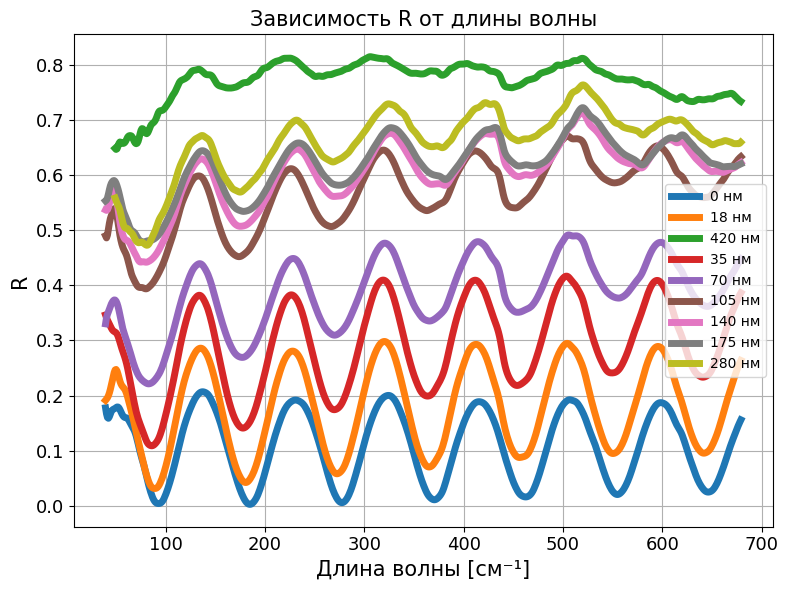

{'0 нм': (array([ 39.54372923,  40.50821043,  41.47269163,  42.43717283,
        43.40165403,  44.36613523,  45.33061643,  46.29509763,
        47.25957883,  48.22406003,  49.18854123,  50.15302243,
        51.11750363,  52.08198483,  53.04646603,  54.01094723,
        54.97542844,  55.93990964,  56.90439084,  57.86887204,
        58.83335324,  59.79783444,  60.76231564,  61.72679684,
        62.69127804,  63.65575924,  64.62024044,  65.58472164,
        66.54920284,  67.51368404,  68.47816524,  69.44264644,
        70.40712765,  71.37160885,  72.33609005,  73.30057125,
        74.26505245,  75.22953365,  76.19401485,  77.15849605,
        78.12297725,  79.08745845,  80.05193965,  81.01642085,
        81.98090205,  82.94538325,  83.90986445,  84.87434565,
        85.83882686,  86.80330806,  87.76778926,  88.73227046,
        89.69675166,  90.66123286,  91.62571406,  92.59019526,
        93.55467646,  94.51915766,  95.48363886,  96.44812006,
        97.41260126,  98.37708246,  99.341563

In [8]:
reflect_dict = load_data(r'C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Ref_dis', 'R',
                           pattern=r'_layer', film_type='printed', filename="Printed_R")
print(reflect_dict)

DEBUG - thk=1.5000000000000002e-08
DEBUG - [(49.1741515183, 0.3686831594), (50.1383505676, 0.3632300198), (51.102549617, 0.3566614091), (52.0667486664, 0.3495823145), (53.0309477158, 0.3426320851), (53.9951467651, 0.3366789818), (54.9593458145, 0.3324083984), (55.9235448639, 0.3296102583), (56.8877439133, 0.3269447982), (57.8519429627, 0.3228829503), (58.816142012, 0.3168479502), (59.7803410614, 0.3095172346), (60.7445401108, 0.3021326661), (61.7087391602, 0.2957559824), (62.6729382095, 0.2910314202), (63.6371372589, 0.2882182896), (64.6013363083, 0.2873125374), (65.5655353577, 0.2880164385), (66.5297344071, 0.2896779776), (67.4939334564, 0.2913718224), (68.4581325058, 0.2922645807), (69.4223315552, 0.2920657098), (70.3865306046, 0.2912018895), (71.3507296539, 0.2905499637), (72.3149287033, 0.2906725407), (73.2791277527, 0.2912560105), (74.2433268021, 0.2912793159), (75.2075258515, 0.2898751199), (76.1717249008, 0.2871445417), (77.1359239502, 0.2841416001), (78.1001229996, 0.2820440829

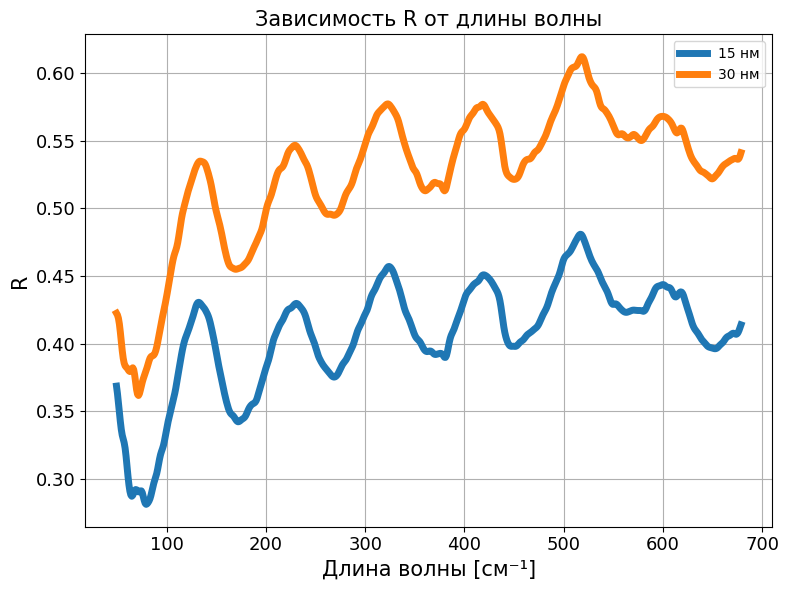

In [ ]:
reflect_filled_dict = load_data(r'C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\filled\R', 'R',
                                  pattern = r'_nm_refl', film_type='filled', filename="Filled_R")

DEBUG - thk=1.75e-08
DEBUG - [(39.5437292255, 0.6996741295), (40.5082104261, 0.6808163524), (41.4726916268, 0.6746255159), (42.4371728274, 0.682634294), (43.401654028, 0.7024421096), (44.3661352286, 0.7290003896), (45.3306164293, 0.7567939758), (46.2950976299, 0.7817078233), (47.2595788305, 0.8006697297), (48.2240600311, 0.8115411997), (49.1885412317, 0.8126235008), (50.1530224324, 0.8048809767), (51.117503633, 0.7923232913), (52.0819848336, 0.7797236443), (53.0464660342, 0.7700728178), (54.0109472349, 0.7640375495), (54.9754284355, 0.7610502243), (55.9399096361, 0.7603603601), (56.9043908367, 0.7612287998), (57.8688720373, 0.7627711892), (58.833353238, 0.7640942931), (59.7978344386, 0.7646337152), (60.7623156392, 0.7642875314), (61.7267968398, 0.7633625865), (62.6912780405, 0.7626202703), (63.6557592411, 0.7629324198), (64.6202404417, 0.7651661634), (65.5847216423, 0.769584775), (66.5492028429, 0.7756377459), (67.5136840436, 0.7822092772), (68.4781652442, 0.7880616784), (69.4426464448

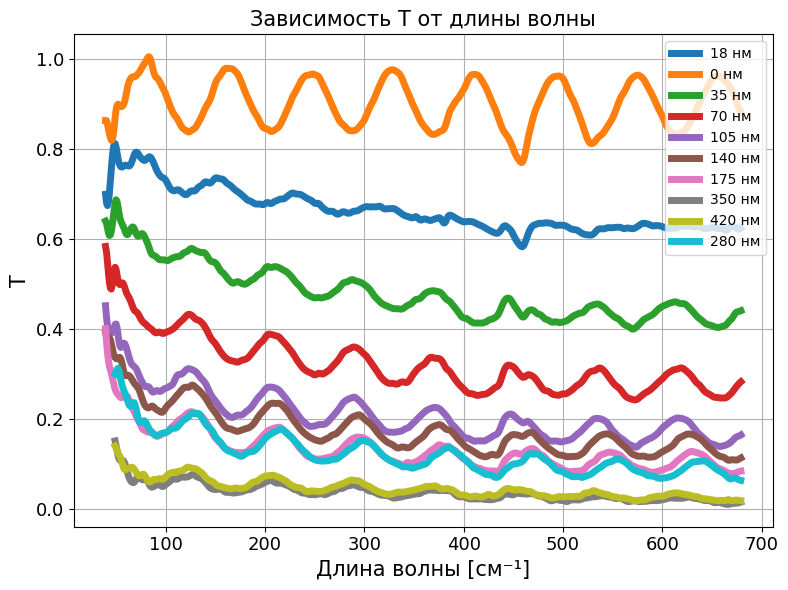

In [10]:
transmit_dict = load_data(r"C:/Users/belco/Documents/Graphene/Data/Dispersion_PP_40/Transm_dis", mode = 'T',
                            pattern = 'L_', filename="T_printed")

DEBUG - thk=1.5000000000000002e-08
DEBUG - [(49.1741515183, 0.3171617091), (50.1383505676, 0.3214731812), (51.102549617, 0.3226568997), (52.0667486664, 0.3203437626), (53.0309477158, 0.3151449561), (53.9951467651, 0.3085701764), (54.9593458145, 0.3024120331), (55.9235448639, 0.2975394428), (56.8877439133, 0.2937511504), (57.8519429627, 0.2903650701), (58.816142012, 0.2871896923), (59.7803410614, 0.2847661376), (60.7445401108, 0.283700943), (61.7087391602, 0.2838900685), (62.6729382095, 0.2843665481), (63.6371372589, 0.2838268876), (64.6013363083, 0.2813300192), (65.5655353577, 0.2767721415), (66.5297344071, 0.2708703876), (67.4939334564, 0.2647319734), (68.4581325058, 0.2592499554), (69.4223315552, 0.2547062933), (70.3865306046, 0.25083673), (71.3507296539, 0.247235477), (72.3149287033, 0.243692562), (73.2791277527, 0.2401224673), (74.2433268021, 0.2363682985), (75.2075258515, 0.2322473526), (76.1717249008, 0.2278066874), (77.1359239502, 0.223414138), (78.1001229996, 0.2194854915), (79

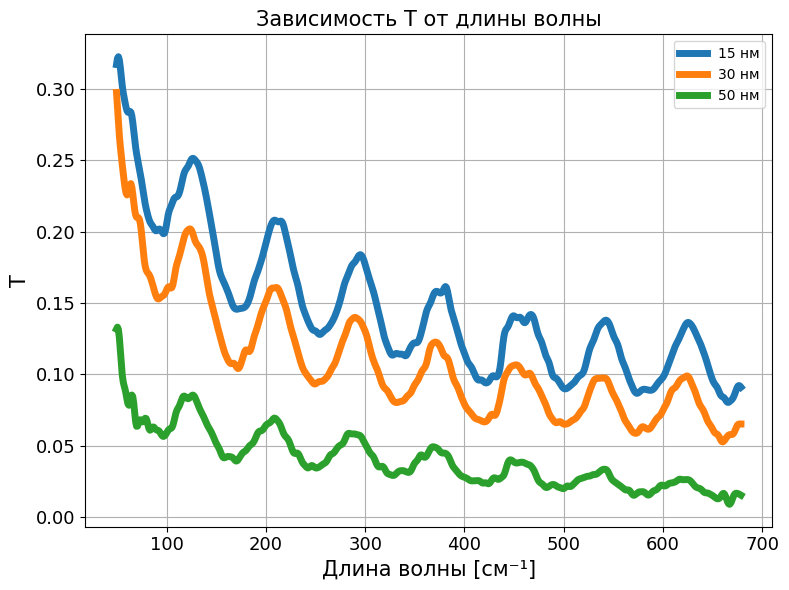

In [11]:
transmit_filled_dict = load_data(r'C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\filled\T', 
                                   mode='T',
                                   pattern = r' nm_tr',
                                   film_type='filled', 
                                   filename = "T_filled")

# Try OOP

In [ ]:
from dataclasses import dataclass
@dataclass
class Spectrum:
    wavelength: np.ndarray 
    wavelength_rc: np.ndarray
    spectrum: np.ndarray
    thk: float
    
    @classmethod
    def load_from_csv(cls, filepath: str, thk: float = None) -> "Spectrum":
        data = np.loadtxt(filepath, delimiter=';', skiprows=1)
        wavelength = data[:, 0]
        spectrum = data[:, 1]
        wavelength_rc = 1e4 / wavelength
        if thk is None:
            thk = 0.1  # fallback value
        return cls(wavelength, wavelength_rc, spectrum, thk)
  

# Testing Gerasimov's and tmm functions 

In [12]:
# Check if VV and tmm are equal

def test_angle_vv_tmm():
    # (air, graphene, PP, air)
    n_list = np.array([1, np.sqrt(-17+700*1j), 1.498+1j*14e-4 , 1])
    eps_1, eps_2, eps_3, eps_4 = n_list**2
    for teta in [0, np.pi/4]:

        kz_1 = np.sqrt(eps_1) * np.cos(teta)
        kz_2 = np.sqrt(eps_2 - eps_1 * np.sin(teta)**2)
        kz_3 = np.sqrt(eps_3 - eps_1 * np.sin(teta)**2)
        kz_4 = np.sqrt(eps_4 - eps_1 * np.sin(teta)**2)
        kz_vv = np.array([kz_1, kz_2, kz_3, kz_4])
        
        
        kz_tmm = np.array(2*np.pi*np.cos(list_snell(n_list, teta))*n_list/2/np.pi)
        print(kz_vv, '\n', kz_tmm, '\n')
        assert np.all(np.abs(kz_tmm-kz_vv))<1e-6

test_angle_vv_tmm()
    

[ 1.        +0.00000000e+00j 18.48251063+1.89368213e+01j
  1.498     +1.40000000e-03j  1.        +0.00000000e+00j] 
 [ 1.        +0.00000000e+00j 18.48251063+1.89368213e+01j
  1.498     +1.40000000e-03j  1.        +0.00000000e+00j] 

[ 0.70710678+0.00000000e+00j 18.47591291+1.89435836e+01j
  1.32060765+1.58805683e-03j  0.70710678+0.00000000e+00j] 
 [ 0.70710678+0.00000000e+00j 18.47591291+1.89435836e+01j
  1.32060765+1.58805683e-03j  0.70710678+0.00000000e+00j] 



# Pure polypropylene

## Approximation of polypropylene $\epsilon$

In [12]:
# find epsilon of PP by reflection assuming extiction=0, (neglect imaginary)
def find_PP_n(d):
    name = '0 нм'
    wl_rc_range = reflect_dict[name][0]
    R_range = reflect_dict[name][1]
    min_indices = argrelextrema(R_range, np.greater)
    wls_max = 0.01/ wl_rc_range[min_indices][::-1]
    n = [wl1*wl2/(2*d*(wl2-wl1)) for wl1, wl2 in zip(wls_max, wls_max[1:])]
    logger.debug(f"{list(zip(wls_max, wls_max[1:]))}\n, {n}")
    n_pp = np.average(n)
    logger.info(f"n_pp={n_pp}")
    return n_pp
find_PP_n(PP_THK)


DEBUG - [(1.6723013623959795e-05, 1.9749082755916564e-05), (1.9749082755916564e-05, 2.405630730128974e-05), (2.405630730128974e-05, 3.0857941806115056e-05), (3.0857941806115056e-05, 4.338187634667334e-05), (4.338187634667334e-05, 7.301597497785606e-05), (7.301597497785606e-05, 0.000195627706544423)]
, [1.3309715592874023, 1.3451308311958559, 1.330971559288856, 1.3035288467254207, 1.3035288467254214, 1.4206999790156536]
INFO - n_pp=1.339138603706435


1.339138603706435

# Fit functions

## Static window fit function

In [13]:

# i - window, j - window step 
def make_2d_windows_vectorized(arr, i, j):
    n = len(arr)
    # Number of rows we can take
    num_rows = (n - i) // j + 1 if n >= i else 0
    
    # Create row and column offsets
    row_offsets = np.arange(num_rows)[:, None] * j  # shape (num_rows, 1)
    col_offsets = np.arange(i)                      # shape (i,)
    
    # Broadcast-add to get the 2D index array
    # shape (num_rows, i)
    indices = row_offsets + col_offsets
    
    return arr[indices]

make_2d_windows_vectorized(np.arange(13), 11, 56)


array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]])

In [14]:
def create_fit_function(gr_thk, mode, f=None):
    """Create a fitting function for reflectance ('R') or transmittance ('T')
    with a polypropylene film.
    
    Parameters:
        gr_thk (float): Thickness of the grating layer.
        mode (str): 'R' for reflectance or 'T' for transmittance.
        func (callable or None): If None, use coh_tmm; if a callable,
            use it instead to compute coefficients.
    
    Returns:
        function: A function that computes the fitted reflectance/transmittance.
                 The returned function expects inputs (wl_rcp_arr, ngr_re, ngr_im).
    """
    
    def compute_fit(wl_rcp_arr, ngr_re, ngr_im, th_0, key):
        # Convert reciprocal wavelength to vacuum wavelength
        wl_arr = 0.01 / wl_rcp_arr
        n_list = [1, ngr_re + 1j * ngr_im, N_PP, 1]
        d_list = [np.inf, gr_thk, PP_THK, np.inf]

        # Choose the calculation function: either coh_tmm or func
        func = f if f is not None else coh_tmm

        # Compute for s- and p-polarizations and average the results
        rf_s = np.array([
            func(pol='s', n_list=n_list, d_list=d_list, th_0=th_0, lam_vac=wl)[key]
            for wl in wl_arr
        ])
        rf_p = np.array([
            func(pol='p', n_list=n_list, d_list=d_list, th_0=th_0, lam_vac=wl)[key]
            for wl in wl_arr
        ])
        return 0.5 * (rf_s + rf_p)

    if mode == 'R':
        # Use a 45° angle (np.pi/4) for reflectance calculations
        return lambda wl_rcp_arr, ngr_re, ngr_im: compute_fit(wl_rcp_arr, ngr_re, ngr_im, th_0=np.pi/4, key='R')
    elif mode == 'T':
        # Use a normal incidence (0°) for transmittance calculations
        return lambda wl_rcp_arr, ngr_re, ngr_im: compute_fit(wl_rcp_arr, ngr_re, ngr_im, th_0=0, key='T')
    elif mode == 'R+T':
        return lambda wl_rcp_arr, ngr_re, ngr_im: compute_fit(wl_rcp_arr, ngr_re, 
                                                              ngr_im, th_0=np.pi/4, 
                                                              key='R') + compute_fit(
                                                              wl_rcp_arr, ngr_re, ngr_im, th_0=0, key='T')
    else:
        raise ValueError("Invalid mode. Choose 'R' for reflectance or 'T' for transmittance.")
    
f = create_fit_function(1e-8, 'T', f=None
                        )
plt.plot(WL_RC_ARR, f(WL_RC_ARR, 10, 10))


NameError: name 'WL_RC_ARR' is not defined

In [ ]:
# Try tmm for PP
def create_PP_function(thk_pp, mode, mul_ref_RT_PP=None):
    assert mode == 'R' or mode == 'T'

    def compute_fit(wl_rcp_arr, n_pp, th_0, key):
        wl_arr = 0.01/wl_rcp_arr
        n_list=[1, n_pp , 1]
        d_list=[np.inf, thk_pp, np.inf]

        func = coh_tmm if mul_ref_RT_PP is None else mul_ref_RT_PP  

        
        rf_s = np.array([
            func(pol='s', n_list=n_list, d_list=d_list, th_0=th_0, lam_vac=wl)[key]
            for wl in wl_arr
        ])
        rf_p = np.array([
            func(pol='p', n_list=n_list, d_list=d_list, th_0=th_0, lam_vac=wl)[key]
            for wl in wl_arr
        ])
        result = 0.5 * (rf_s + rf_p)
        
        return result
    
    
    if mode == 'R':
        return lambda wl_rcp_arr, n_pp_re, n_pp_im: compute_fit(wl_rcp_arr, n_pp_re+1j*n_pp_im,  
                                                                 th_0=np.pi/4, key='R')
    if mode == 'T':
        return lambda wl_rcp_arr, n_pp_re, n_pp_im: compute_fit(wl_rcp_arr, n_pp_re+1j*n_pp_im,  
                                                                 th_0=0, key='T')
    if mode == 'R+T':
        return lambda wl_rcp_arr, n_pp_re, n_pp_im: compute_fit(wl_rcp_arr, n_pp_re+1j*n_pp_im,
                                     th_0=np.pi/4, key='R')+compute_fit(wl_rcp_arr, n_pp_re+1j*n_pp_im,  
                                                                 th_0=0, key='T')
                   

f = create_PP_function(40e-6, 'T')
f(WL_RC_ARR, 1, 1)



array([1.03707114e-01, 9.87760501e-02, 9.40647839e-02, 8.95649731e-02,
       8.52684756e-02, 8.11673511e-02, 7.72538623e-02, 7.35204768e-02,
       6.99598684e-02, 6.65649187e-02, 6.33287180e-02, 6.02445658e-02,
       5.73059715e-02, 5.45066536e-02, 5.18405396e-02, 4.93017643e-02,
       4.68846684e-02, 4.45837961e-02, 4.23938928e-02, 4.03099020e-02,
       3.83269619e-02, 3.64404014e-02, 3.46457365e-02, 3.29386659e-02,
       3.13150662e-02, 2.97709874e-02, 2.83026478e-02, 2.69064294e-02,
       2.55788724e-02, 2.43166702e-02, 2.31166641e-02, 2.19758385e-02,
       2.08913151e-02, 1.98603483e-02, 1.88803198e-02, 1.79487338e-02,
       1.70632120e-02, 1.62214886e-02, 1.54214059e-02, 1.46609096e-02,
       1.39380441e-02, 1.32509485e-02, 1.25978522e-02, 1.19770709e-02,
       1.13870027e-02, 1.08261240e-02, 1.02929865e-02, 9.78621292e-03,
       9.30449430e-03, 8.84658632e-03, 8.41130636e-03, 7.99753054e-03,
       7.60419081e-03, 7.23027231e-03, 6.87481069e-03, 6.53688969e-03,
      

## Multiple reflection

## Inflection points approach

In [ ]:
# inflection points approach

from scipy.signal import savgol_filter

def find_inflection_points_noisy(arr, window_length=50, polyorder=3, threshold=1e-5):
    """
    Given a noisy 1D numpy array 'arr', return indices that correspond to 
    inflection points. The function first smooths the data and computes a 
    smoothed second derivative using a Savitzky–Golay filter.
    
    Parameters:
      arr           : Input array (discrete function)
      window_length : Length of the filter window (must be odd)
      polyorder     : Order of the polynomial used in filtering
      threshold     : Minimum absolute change in the second derivative to consider a true inflection
      
    Returns:
      inflection_indices : numpy array of indices where inflection occurs.
    """
    # Smooth the array; you can also smooth directly the derivatives.
    smoothed = savgol_filter(arr, window_length=window_length, polyorder=polyorder)
    # Compute the second derivative from the smoothed data
    d2 = savgol_filter(smoothed, window_length=window_length, polyorder=polyorder, deriv=2)
    
    inflec = []
    # Loop over indices in d2. d2[i] corresponds to the second derivative at index i.
    for i in range(len(d2)-1):
        # Check for a sign change and that the change is significant
        if d2[i] * d2[i+1] < 0 and np.abs(d2[i] - d2[i+1]) > threshold:
            inflec.append(i+1)
    return np.array(inflec, dtype=int)

def segment_by_inflection_noisy(arr, window_length=11, polyorder=3, threshold=1e-5):
    """
    Segment a 1D noisy array 'arr' using inflection points detected on its smoothed second derivative.
    The endpoints of the array are also used as boundaries.
    
    Returns:
      segments   : List of sub-arrays (segments)
      boundaries : Array of boundary indices.
    """
    inflection_indices = find_inflection_points_noisy(arr, window_length, polyorder, threshold)
    # Include endpoints
    boundaries = np.concatenate(([0], inflection_indices, [len(arr)-1]))
    boundaries = np.unique(boundaries)  # ensure sorted and unique
    segments = []
    for i in range(len(boundaries) - 1):
        start = boundaries[i]
        end = boundaries[i+1] + 1  # include the boundary point in the segment
        segments.append(arr[start:end])
    return segments, boundaries

# Example usage with noisy data:
if __name__ == '__main__':
    # Create a sample function: for example, a sine with a quadratic trend, plus random noise.
    x = np.linspace(0, 10, 200)
    true_f = np.sin(x) + 0.1 * x**2
    noise = np.random.normal(0, 0.1, x.shape)
    noisy_f = true_f + noise

    # Find inflection points and segments using the noisy data
    segments, boundaries = segment_by_inflection_noisy(noisy_f, window_length=11, polyorder=3, threshold=5e-3)
    
    print("Inflection point indices (boundaries):", boundaries)
    print("Number of segments:", len(segments))
    
    # Plot results
    plt.figure(figsize=(8, 4))
    #plt.plot(x, noisy_f, label='Noisy f(x)', color='blue')
    plt.plot(x, true_f, label='True f(x)', linestyle='--', color='black')
    plt.plot(x[boundaries], noisy_f[boundaries], 'ro', label='Inflection Boundaries')
    for i, (start, end) in enumerate(zip(boundaries[:-1], boundaries[1:])):
        plt.axvspan(x[start], x[end], alpha=0.2, label='Segment' if i==0 else None)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.title("Segmentation by Inflection Points (with Noise)")
    plt.show()


## Dynamic segmentation approach

In [ ]:
# ---------------------------
# Generate synthetic spectral data
# ---------------------------
# Define wavelength range (e.g., in nm)
lam = np.linspace(400, 800, 1000)  # 1000 points from 400 to 800 nm

# True refractive index functions (for demonstration)
n_true = 1.5 + 0.2 * np.sin(0.01 * lam)      # e.g. oscillatory behavior in n(λ)
k_true = 0.01 + 0.005 * np.cos(0.01 * lam)     # similar behavior for k(λ)

# Add random noise to simulate experimental error
np.random.seed(0)
noise_level = 0.001  # noise level for both n and k
n_data = n_true + np.random.normal(0, noise_level, lam.shape)
k_data = k_true + np.random.normal(0, noise_level, lam.shape)

# ---------------------------
# Compute derivative of n_data with respect to lam
# ---------------------------
# We use a finite-difference approximation (numpy.gradient)
deriv_n = np.gradient(n_data, lam)

# Experimental error tolerance (epsilon)
epsilon = 0.001  # allowable change in n over a segment

# For cases where the derivative is nearly zero, we set a maximum segment length.
max_segment_length = 50.0  # nm

# ---------------------------
# Dynamic segmentation based on the criterion Δλ ≈ ε/|dn/dλ|
# ---------------------------
segments = []        # will store tuples: (wavelength segment, n_segment, k_segment)
segment_bounds = []  # to record the segment boundaries (start and end indices)

i = 0
while i < len(lam):
    seg_start = i
    # Estimate local derivative (absolute value) at the start of the segment
    local_deriv = np.abs(deriv_n[i])
    # If the derivative is very small, use a default max segment length
    if local_deriv < 1e-8:
        allowed_length = max_segment_length
    else:
        allowed_length = epsilon / local_deriv
        # Do not exceed a preset maximum length
        allowed_length = min(allowed_length, max_segment_length)
    
    # Determine the segment: include points until the wavelength difference exceeds allowed_length
    j = seg_start + 1
    while j < len(lam) and (lam[j] - lam[seg_start]) <= allowed_length:
        j += 1

    # Append this segment (use slicing from seg_start to j)
    segments.append((lam[seg_start:j], n_data[seg_start:j], k_data[seg_start:j]))
    segment_bounds.append((seg_start, j-1))
    i = j  # move to the next segment

print(f"Number of segments: {len(segments)}")

# ---------------------------
# Define a linear fitting function
# ---------------------------
def linear_func(x, a, b):
    return a * x + b

# Prepare arrays to hold fitted values for the entire wavelength range
fitted_n = np.zeros_like(n_data)
fitted_k = np.zeros_like(k_data)

# For each segment, fit a linear model and store the fitted values
for seg in segments:
    lam_seg, n_seg, k_seg = seg
    # Fit the linear model to n and k separately using curve_fit
    popt_n, _ = curve_fit(linear_func, lam_seg, n_seg)
    popt_k, _ = curve_fit(linear_func, lam_seg, k_seg)
    
    # Compute fitted values on the segment
    fitted_n_seg = linear_func(lam_seg, *popt_n)
    fitted_k_seg = linear_func(lam_seg, *popt_k)
    
    # Find indices corresponding to this segment and store the fitted values
    inds = np.searchsorted(lam, lam_seg)
    fitted_n[inds] = fitted_n_seg
    fitted_k[inds] = fitted_k_seg

# ---------------------------
# Plot the results
# ---------------------------
plt.figure(figsize=(12, 6))

# Plot for the real refractive index
plt.subplot(1, 2, 1)
plt.plot(lam, n_data, label="Noisy n_data", alpha=0.5)
plt.plot(lam, n_true, label="True n (model)", linestyle="--")
plt.plot(lam, fitted_n, label="Fitted n (dynamic segments)", linewidth=2)
# Mark segment boundaries
for (start, end) in segment_bounds:
    plt.axvline(lam[start], color='gray', linestyle=':', alpha=0.7)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Refractive Index n")
plt.title("Dynamic Spectral Fitting for n")
plt.legend()

# Plot for the extinction coefficient
plt.subplot(1, 2, 2)
plt.plot(lam, k_data, label="Noisy k_data", alpha=0.5)
plt.plot(lam, k_true, label="True k (model)", linestyle="--")
plt.plot(lam, fitted_k, label="Fitted k (dynamic segments)", linewidth=2)
# Mark segment boundaries
for (start, end) in segment_bounds:
    plt.axvline(lam[start], color='gray', linestyle=':', alpha=0.7)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Extinction Coefficient k")
plt.title("Dynamic Spectral Fitting for k")
plt.legend()

plt.tight_layout()
plt.show()


# Fitting procedure

## Fitting widget


In [15]:
# Updated interactive widget to allow changing of wl_rcp_arr range

def interactive_plot(eps_gr_re=100, eps_gr_im=100, gr_thk=40e-9, mode='R', wl_min=5, wl_max=700, multi_RT_switch=False):
    ngr = sqrt(eps_gr_re+1j*eps_gr_im)
    ngr_re, ngr_im = ngr.real, ngr.imag

    # Generate wl_rcp_arr based on the widget inputs
    wl_rcp_arr = np.arange(wl_min, wl_max + 1)
    
    # Create the fitting function based on the current parameters
    func = coh_tmm if not multi_RT_switch else mul_ref_RT 
  

    fit_func = create_fit_function(gr_thk, mode, func)
    # Compute the reflectance or transmittance
    y = fit_func(wl_rcp_arr, ngr_re, ngr_im)


    # Compute reflection/transmission using create_PP_function (already defined)
    f_pp = create_PP_function( 41e-6, mode)
    y_pp = f_pp(wl_rcp_arr, N_PP.real, N_PP.imag)

   
    # Plot both on the same figure, making it larger and clearer
    plt.figure(figsize=(12, 8))  # Make figure about twice as large

    # Plot
    plt.figure(figsize=(12, 8)) 
    plt.plot(wl_rcp_arr, y, label = 'fit', linewidth=4)
    plt.plot(wl_rcp_arr, y_pp, label='fit PP', linewidth=4)

    # Draw experiments on the same figure
    if(mode == 'R'):
        this_dict = reflect_dict
    if(mode == 'T'):
        this_dict = transmit_dict 
    for wavelength_rc, spectrum, thk in this_dict.values():
        plt.plot(wavelength_rc, spectrum, 
            label=f"{thk*1e9:.0f}nm", 
        linewidth=2)  

    plt.xlabel('wl rcp')
    plt.ylabel('Reflection / Transmission')
    plt.title(f"Mode: {mode}, gr_thk: {gr_thk:.2e}, eps_gr_re: {eps_gr_re}, eps_gr_im: {eps_gr_im}")
    plt.legend(loc='best')
    plt.tight_layout()
    # включаем основную сетку
    plt.grid(which='major')
    # включаем дополнительную сетку
    plt.grid(which='minor', linestyle=':')
    plt.show()

# Create the toggle button widget and attach an observer to update its description
toggle_button = widgets.ToggleButton(
    value=False,
    description='Not using multi_RT'
)

def on_toggle_change(change):
    if change['new']:
        toggle_button.description = "Using multi_RT"
    else:
        toggle_button.description = "Not using multi_RT"

toggle_button.observe(on_toggle_change, names='value')

# Create and display the interactive widget
def show_widget():
    return interact(
        interactive_plot,
        eps_gr_re=FloatSlider(value=100, min=-1000, max=1000, step=50, description='eps_gr_re'),
        eps_gr_im=FloatSlider(value=100, min=-100, max=500, step=10, description='eps_gr_im'),
        gr_thk=FloatText(value=4e-8, description='gr_thk'),
        mode=Dropdown(options=['R', 'T'], value='R', description='mode'),
        wl_min=IntSlider(value=5, min=1, max=1000, step=1, description='wl_min'),
        wl_max=IntSlider(value=700, min=1, max=2000, step=1, description='wl_max'),
        multi_RT_switch=toggle_button
    )

show_widget()

interactive(children=(FloatSlider(value=100.0, description='eps_gr_re', max=1000.0, min=-1000.0, step=50.0), F…

<function __main__.interactive_plot(eps_gr_re=100, eps_gr_im=100, gr_thk=4e-08, mode='R', wl_min=5, wl_max=700, multi_RT_switch=False)>

## Contour chisq

In [ ]:
from matplotlib import colors
def contour_chisq(x_data, y_data, n_meshgrid:np.meshgrid, model):
    N_RE, N_IM = n_meshgrid
    chisq = np.zeros_like(N_RE)

    # Compute chi-squared for each pair (eps_re, n_im)
    for i in range(N_RE.shape[0]):
        for j in range(N_RE.shape[1]):
            y_model = model(x_data, N_RE[i, j], N_IM[i, j])
            chisq[i, j] = np.sum(((y_data - y_model)) ** 2)

    # Use logarithmic scaling for color mapping to enhance local minima visibility.
    # Ensure the minimum is positive (if zero exists, take the smallest nonzero value)
    min_positive = np.nanmin(chisq[np.nonzero(chisq)]) if np.any(chisq != 0) else 1e-6
    print(chisq)
    plt.figure(figsize=(8, 6))
    plt.pcolormesh(N_RE, N_IM, chisq, shading='auto', cmap='viridis',
                   norm=colors.LogNorm(vmin=min_positive, vmax=np.nanmax(chisq)))
    plt.colorbar(label=r'$\chi^2$')
    plt.xlabel('n_re')
    plt.ylabel('n_im')
    plt.title('Chi-squared Map with Log Scale (No Distortion)')
    plt.gca().set_aspect('auto')  # Optional: auto-scale aspect ratio
    plt.show()

n_meshgrid = np.meshgrid(np.linspace(0, 2, 31), np.linspace(0, 0.002, 30))
n_meshgrid_tilde = np.meshgrid(np.linspace(1, 2, 50), np.linspace(0.001, 0.002, 100))

def n_from_eps(eps_re, n_im):
    eps = eps_re+1j*n_im
    n = sqrt(eps)
    return (n.real, n.imag)

model = lambda x_data, n_PP_re, n_PP_im: create_PP_function(41e-6, mode='T')(x_data, 
                    n_PP_re, n_PP_im)




In [ ]:
contour_chisq(transmit_dict['0nm'][0][100:300:4], transmit_dict['0nm'][1][100:300:4], n_meshgrid_tilde, model)

## Fitting

In [1]:
def spectral_fitting(optical_dict,
                    name, 
                    fit_mode, 
                    interval, 
                    step, 
                    bounds,
                    start_wl=41,
                    stop_wl=700,
                    output_path=None,
                    folder_name = "fitting_epsilon",
                    segmentation_method='fixed',  # or 'inflection'
                    draw_plots=True,   
                    output_curve_fit=None, 
                    savefig=False,  
                    f=None):
    """
    Fit optical data for different graphene thicknesses. Can be used to fit
    either reflectance or transmittance data, based on the `fit_mode` parameter.
    
    Parameters:
        optical_dict (dict): Dictionary where each key corresponds to a thickness.
                             Each entry is a tuple/list containing:
                                [0] - wavelength array (Pandas Series)
                                [1] - optical data array (reflectance or transmittance)
                                [2] - graphene thickness (float)
        fit_mode (str): 'R' for reflectance fitting or 'T' for transmittance fitting.
        interval (float): Window size for data segmentation.
        step (float): Step size between windows.
        start_wl (float): Start wavelength of the first window.
        segmentation_method (str): 'fixed' or 'inflection'
        draw_plots (bool): If True, plot each segment’s fit and the final fit.
        output_curve_fit: Optional parameter to output the curve fit results.
    
    Returns:
        dict: A dictionary with keys for each thickness containing:
              - eps_x_axis: x-axis values (transformed wavelengths)
              - fit_eps_gr_re: fitted real part of dielectric permittivity
              - fit_eps_gr_im: fitted imaginary part of dielectric permittivity
    """
    from pathlib import Path
    
    assert start_wl>=41
    assert fit_mode == 'R' or fit_mode == 'T'
    assert name in optical_dict
    fit_n_dict = {}
    fit_eps_dict = {}

    if savefig:
        # Step 1: Create folder
        fitting_path=os.path.join(output_path, folder_name)
        os.makedirs(fitting_path, exist_ok=True)
    
    
                                                                  

    gr_thk = optical_dict[name][2]
    assert 0 <= gr_thk < 1e-5, f"Thickness out of expected range for {name}"
    logger.info(f"gr_thk= {gr_thk:.2e} m")

    # Create the appropriate fitting function based on mode ('R' or 'T')
    
    if gr_thk==0:
        fit_func = create_PP_function(PP_THK, fit_mode)
    
    if gr_thk>0:
        fit_func = create_fit_function(gr_thk, fit_mode) if f is None else f 
    

    
    # Get wavelength and optical data arrays
    wl_arr = optical_dict[name][0]
    opt_arr = optical_dict[name][1]
    logger.debug(f"(wavelength, optical data): {list(zip(wl_arr, opt_arr))}")
    
    pcov_n_arr = []
    wl_begins = []    # middle points of each segment
    fit_ngr_re = []   # fit parameter: real part
    fit_ngr_im = []   # fit parameter: imaginary part

    # Create segments based on chosen method
    if segmentation_method == 'fixed':
        if start_wl <= 40:
            raise ValueError("start_wl must be greater than 40")
        if stop_wl > 700:
            raise ValueError("start_wl must be greater than 40")
        start_point = int(start_wl) - 40
        stop_point=int(stop_wl)-40
        wl_segments = make_2d_windows_vectorized(wl_arr[start_point:stop_point], interval, step)
        optical_segments = make_2d_windows_vectorized(opt_arr[start_point:stop_point], interval, step)
    elif segmentation_method == 'inflection':
        logger.error("Inflection segmentation method is not yet implemented.")
        wl_segments = wl_arr  # fallback: use entire array
        optical_segments = opt_arr
    else:
        raise ValueError("Invalid segmentation method.")

    # Fit each segment
    for x_data, y_data in zip(wl_segments, optical_segments):
        try:
            kwargs = {'maxfev': 100000}
            p0 = None if not fit_ngr_re else (fit_ngr_re[-1], fit_ngr_im[-1])
            popt, pcov = curve_fit(fit_func, x_data, y_data, p0=p0, bounds=bounds,
                                    **kwargs)
        except RuntimeError as e:
            logger.error(f"Fitting failed for segment at wavelength center {0.5*(x_data[0]+x_data[-1])}")
            raise e

        

        """
        # Check asymptotics and erase bad points
        if fit_mode == 'R' and np.all(fit_func(np.array(wl_arr[:10]), popt[0], popt[1])  > 0.5):
            continue

        if fit_mode == 'T' and np.all(fit_func(np.array(wl_arr[:10]), popt[0], popt[1])  < 0.5):
            continue
        """

        perr = np.sqrt(np.diag(pcov))
        wl_bgn = 0.5 * (x_data[0] + x_data[-1])
        logger.debug(f"Segment: wavelength range {x_data[0]:.1f} to {x_data[-1]:.1f}")
        logger.info(f"popt= {popt}, perr= {perr}, wl_begin = {wl_bgn}")
        pcov_n_arr.append(pcov)
        wl_begins.append(wl_bgn)
        fit_ngr_re.append(popt[0])
        fit_ngr_im.append(popt[1])

        # Plot each segment's fit if requested
        if draw_plots:
            if not np.all([x_data, y_data]):
                logger.error("Empty data for plotting")
            else:
                plt.figure(figsize=(10, 6))
                plt.plot(wl_arr, fit_func(wl_arr, popt[0], popt[1]), 'r-', label='Теория')
                plt.plot(wl_arr, opt_arr, 'bo', label='Эксперимент')
                plt.axvline(wl_bgn - interval/2)
                plt.axvline(wl_bgn + interval/2)
                plt.xlabel('Длина волны [см-1]')
                ylabel = "Отражение" if fit_mode == 'R' else 'Пропускание'
                plt.ylabel(ylabel)
                plt.title(f'{name}; start {wl_bgn:.0f} cm-1')
                plt.legend()
                plt.grid(True)

                # Save plots 
                if savefig:
                    segment_name=f"{name}{wl_bgn}.png"
                    segment_path=Path(fitting_path) / segment_name
                    plt.savefig(segment_path, dpi=300)
                plt.show()

    # Transform lists to numpy arrays for further processing
    wl_begins = np.array(wl_begins)
    fit_ngr_re = np.array(fit_ngr_re)
    fit_ngr_im = np.array(fit_ngr_im)
    pcov_n_arr = np.array(pcov_n_arr)

    
    # Calculation of epsilon error
    # Partial derivatives
    dRe_dn =  2*fit_ngr_re
    dRe_dk = -2*fit_ngr_im
    dIm_dn =  2*fit_ngr_im
    dIm_dk =  2*fit_ngr_re
    # Covariance elements
    s_nn   = pcov_n_arr[:, 0, 0]
    s_kk   = pcov_n_arr[:, 1, 1]
    s_nk   = pcov_n_arr[:, 0, 1]               # = pcov[1, 0]
    # Propagate variances (include correlation term)
    var_eps_Re = sqrt((dRe_dn**2)*s_nn + (dRe_dk**2)*s_kk + 2*dRe_dn*dRe_dk*s_nk)
    var_eps_Im = sqrt((dIm_dn**2)*s_nn + (dIm_dk**2)*s_kk + 2*dIm_dn*dIm_dk*s_nk)

    logger.debug(f"wl_begins = {wl_begins}")

    # Convert wavelengths and computed parameters into dielectric permittivity components
    eps_x_axis = 1e4 / wl_begins
    fit_eps_gr_re = fit_ngr_re**2 - fit_ngr_im**2
    fit_eps_gr_im = 2 * fit_ngr_re * fit_ngr_im
    logger.debug(f"eps_x_axis = {eps_x_axis}")

    # Save the n and epsilon results for this thickness
    fit_eps_dict[name] = {"eps_x_axis": eps_x_axis, 
                            "fit_eps_gr_re": fit_eps_gr_re, 
                            "fit_eps_gr_im": fit_eps_gr_im}
    fit_n_dict[name] = {"wl_begins": wl_begins, 
                        "fit_ngr_re": fit_ngr_re, 
                        "fit_ngr_im": fit_ngr_im}



    # Plot dielectric permittivity components vs mkm
    plt.figure(figsize=(8, 6))
    plt.errorbar(eps_x_axis, fit_eps_gr_re, yerr=var_eps_Re, color='red', label='Re $\epsilon$', marker='o')
    plt.errorbar(eps_x_axis, fit_eps_gr_im, yerr=var_eps_Im, color='blue', label='Im $\epsilon$', marker='o')
    plt.xlabel('Длина волны [мкм]')
    plt.ylabel('Диэлектрическая проницаемость')
    plt.title(f'Аппроксимация $\epsilon$ для {name} по {fit_mode}-спектру')
    plt.legend()
    plt.grid(True)

    if savefig:
        filename = f"{fit_mode}{name}.png"
        filepath = Path(fitting_path) / filename  # full path

    plt.savefig(filepath, dpi=300)  
    plt.show() 
    plt.close()

    # Plot dielectric permittivity components vs cm-1
    plt.figure(figsize=(12, 6))
    plt.errorbar(wl_begins, fit_eps_gr_re, yerr=var_eps_Re, color='red', label='Re $\epsilon$', marker='o')
    plt.errorbar(wl_begins, fit_eps_gr_im, yerr=var_eps_Im, color='blue', label='Im $\epsilon$', marker='o')
    plt.xlabel('Длина [см-eps_Im')
    plt.ylabel('Диэлектрическая проницаемость')
    plt.title(f'Аппроксимация $\epsilon$ графена для {name} по {fit_mode}-спектру')
    plt.legend()
    plt.grid(True)

    # Plot n conponents
    plt.figure(figsize=(12, 6))
    plt.errorbar(wl_begins, fit_ngr_re, yerr=s_nn, color='red', label='Real part of n', marker='o')
    plt.errorbar(wl_begins, fit_ngr_im, yerr=s_kk, color='blue', label='Imaginary part of n')
    plt.xlabel('Длина волны [см-1]')
    plt.ylabel('Re n и Im n')
    plt.title(f'Аппроксимация n графена для {name} по {fit_mode}-спектру')
    plt.legend()
    plt.grid(True)

    # Save epsilon plot

    return fit_n_dict, fit_eps_dict
    



INFO - gr_thk= 7.00e-08 m
DEBUG - (wavelength, optical data): [(39.5437292255, 0.5835810304), (40.5082104261, 0.5712164044), (41.4726916268, 0.5494642854), (42.4371728274, 0.5250365138), (43.401654028, 0.5042712688), (44.3661352286, 0.4912459254), (45.3306164293, 0.4887857139), (46.2950976299, 0.4976535141), (47.2595788305, 0.513856113), (48.2240600311, 0.5299220085), (49.1885412317, 0.5373187065), (50.1530224324, 0.5328013301), (51.117503633, 0.5205343962), (52.0819848336, 0.5080031157), (53.0464660342, 0.5004368424), (54.0109472349, 0.4986672401), (54.9754284355, 0.5004427433), (55.9399096361, 0.5025686026), (56.9043908367, 0.5023775697), (57.8688720373, 0.4987037778), (58.833353238, 0.4923436344), (59.7978344386, 0.4853755236), (60.7623156392, 0.4795876443), (61.7267968398, 0.475343436), (62.6912780405, 0.4717464149), (63.6557592411, 0.4677138031), (64.6202404417, 0.4627456665), (65.5847216423, 0.4569800794), (66.5492028429, 0.451002568), (67.5136840436, 0.4456831217), (68.478165244

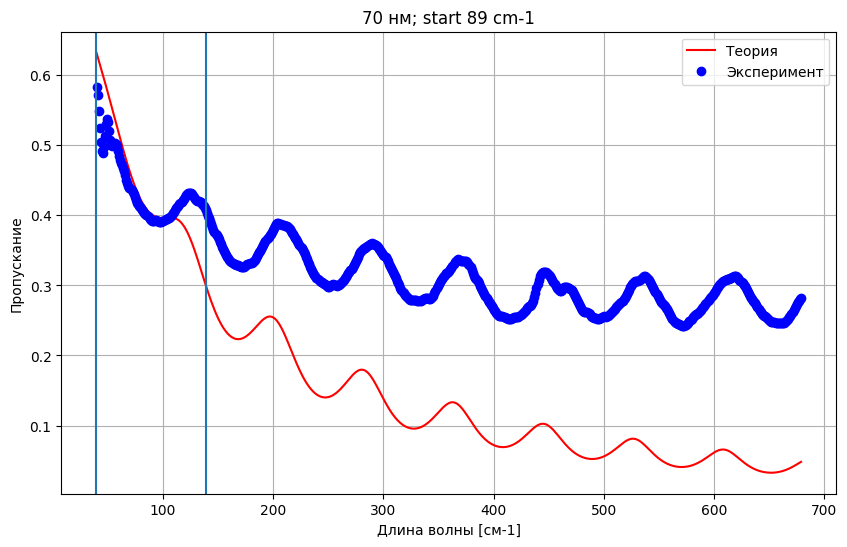

DEBUG - Segment: wavelength range 89.7 to 185.2
INFO - popt= [13.46796361  8.27500443], perr= [0.7069883  0.63597692], wl_begin = 137.4385710887


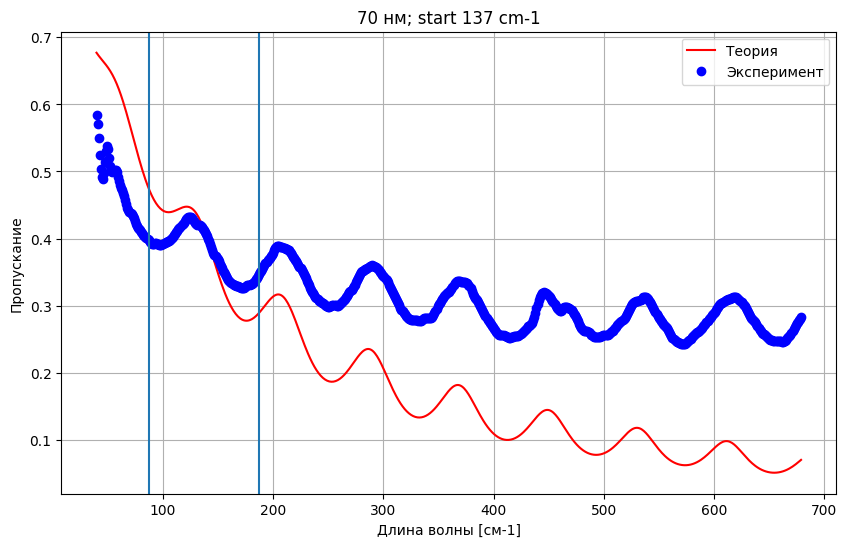

DEBUG - Segment: wavelength range 137.9 to 233.4
INFO - popt= [11.43597412  8.11631947], perr= [0.53998892 0.46903272], wl_begin = 185.66263111985


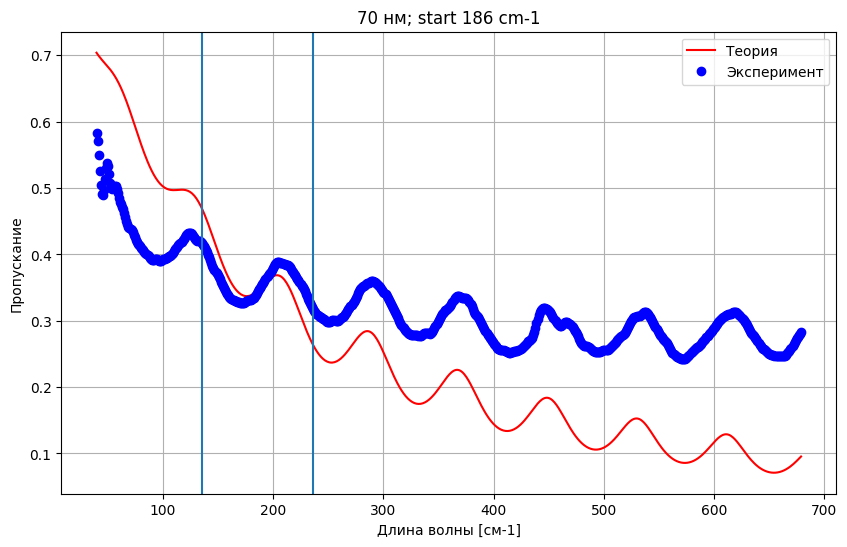

DEBUG - Segment: wavelength range 186.1 to 281.6
INFO - popt= [9.97336103 7.96617135], perr= [0.36470293 0.3483623 ], wl_begin = 233.88669115095


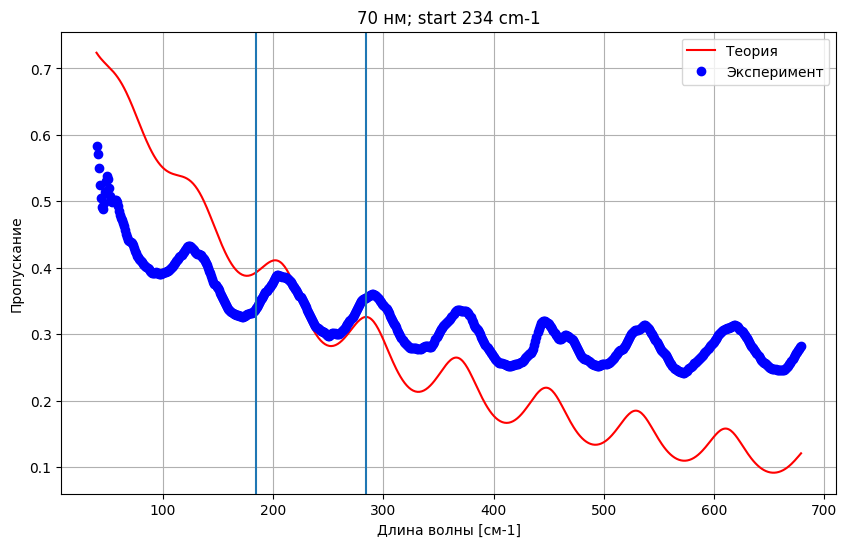

DEBUG - Segment: wavelength range 234.4 to 329.9
INFO - popt= [11.14202944  5.79833226], perr= [0.32271496 0.28901392], wl_begin = 282.1107511821


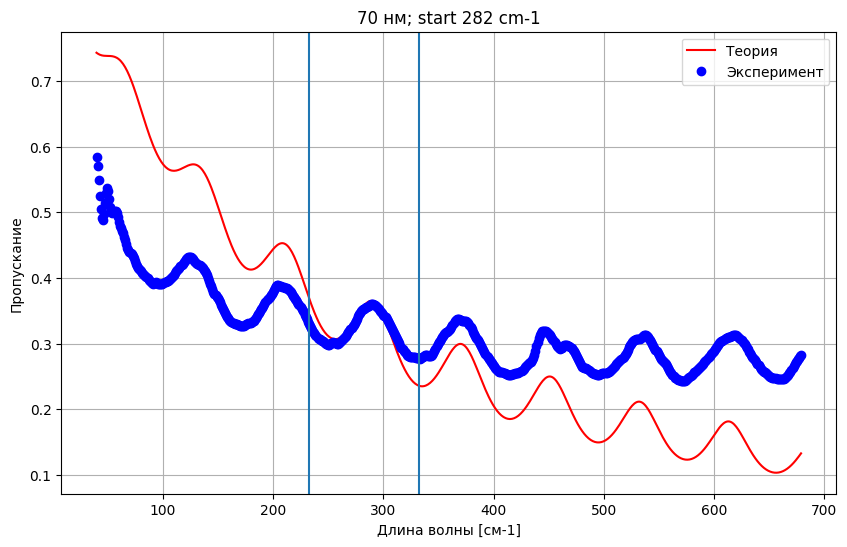

DEBUG - Segment: wavelength range 282.6 to 378.1
INFO - popt= [8.34408779 7.53440786], perr= [0.20631835 0.19234719], wl_begin = 330.3348112132


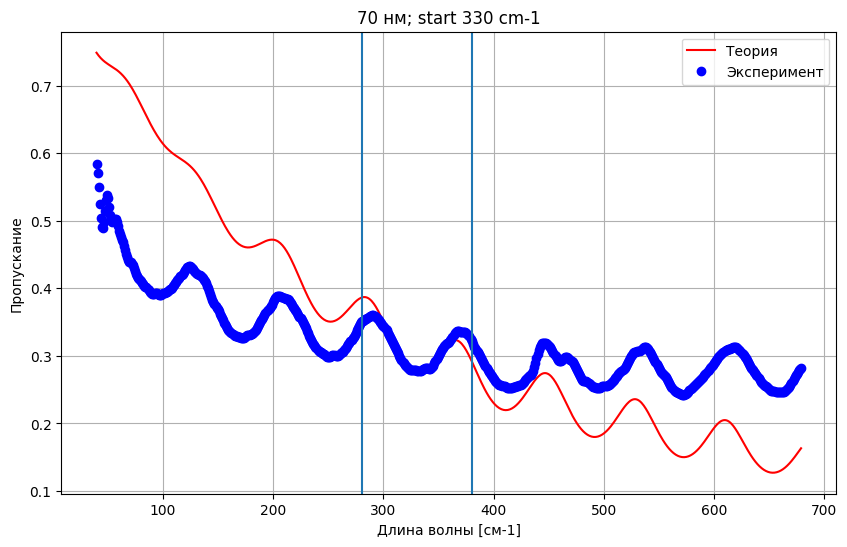

DEBUG - Segment: wavelength range 330.8 to 426.3
INFO - popt= [9.32725019 5.99159426], perr= [0.18964814 0.17938649], wl_begin = 378.55887124435


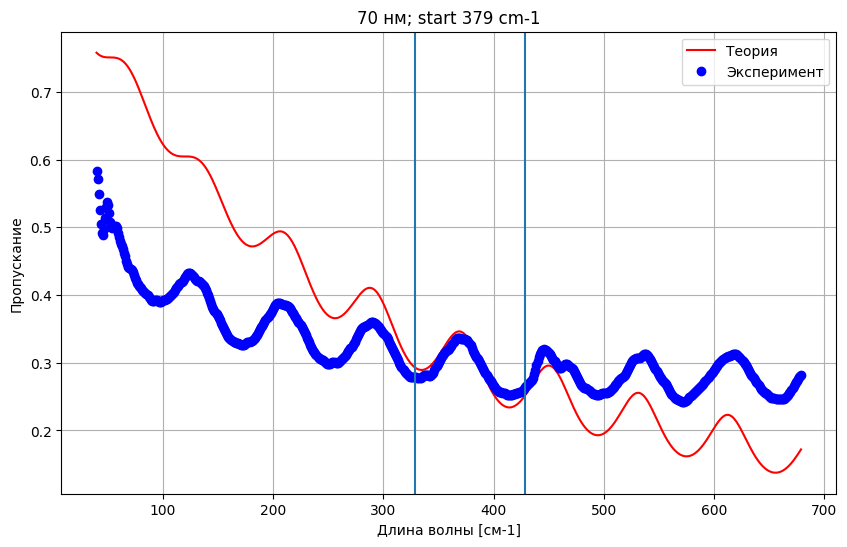

DEBUG - Segment: wavelength range 379.0 to 474.5
INFO - popt= [8.90575339 5.89741028], perr= [0.21642731 0.19160658], wl_begin = 426.7829312755


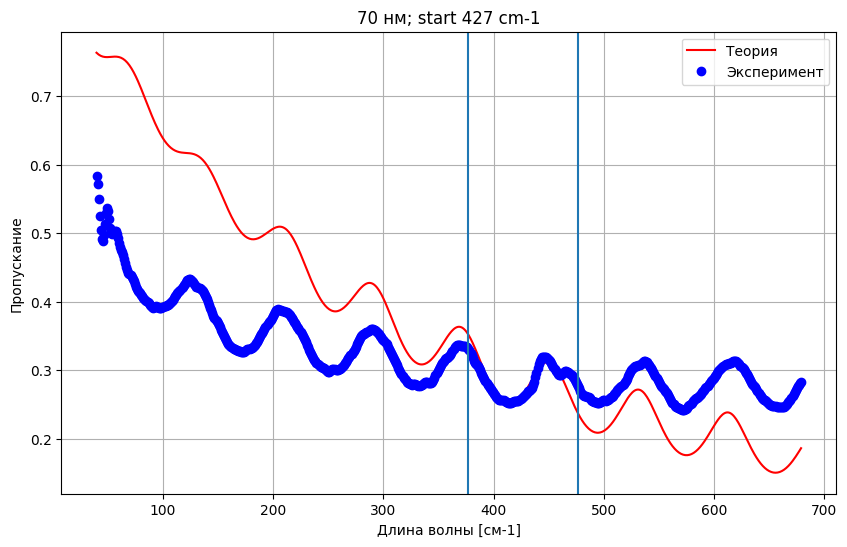

DEBUG - Segment: wavelength range 427.3 to 522.7
INFO - popt= [8.01578203 6.09743849], perr= [0.30082867 0.28892747], wl_begin = 475.0069913066


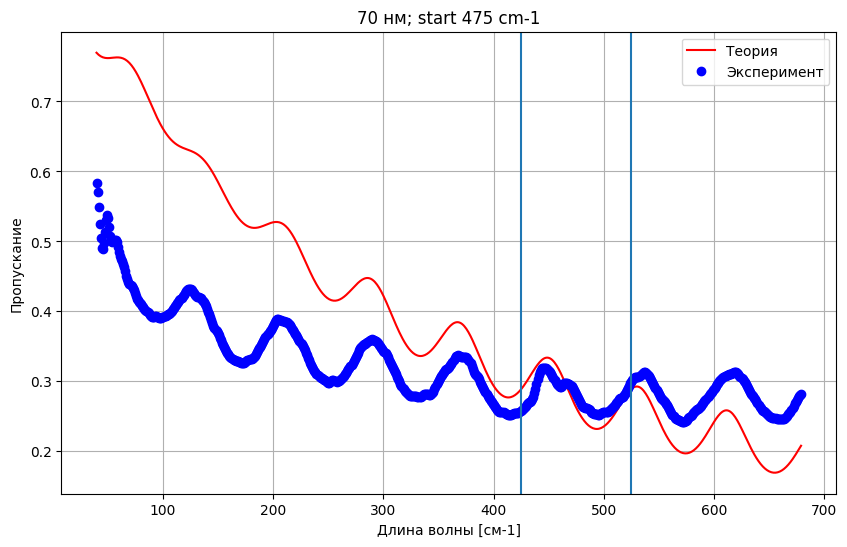

DEBUG - Segment: wavelength range 475.5 to 571.0
INFO - popt= [8.62377451 4.88412916], perr= [0.17323492 0.15854308], wl_begin = 523.23105133775


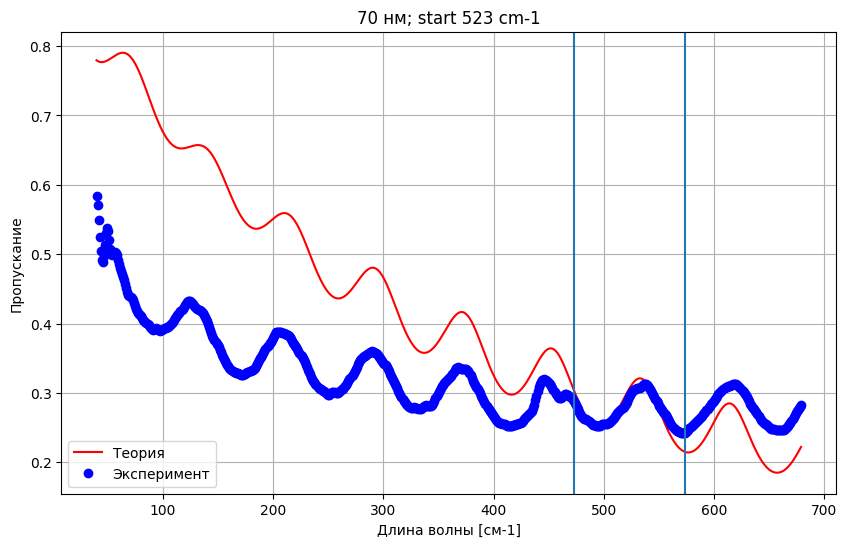

DEBUG - Segment: wavelength range 523.7 to 619.2
INFO - popt= [6.56461291 6.31898206], perr= [0.18903399 0.17774708], wl_begin = 571.45511136885


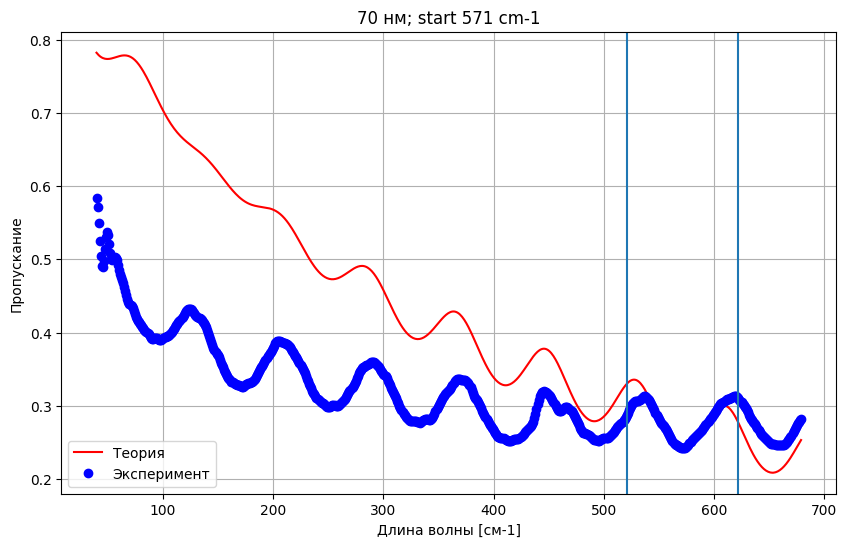

DEBUG - Segment: wavelength range 571.9 to 667.4
INFO - popt= [7.59865637 4.7652387 ], perr= [0.18700855 0.17484911], wl_begin = 619.6791714


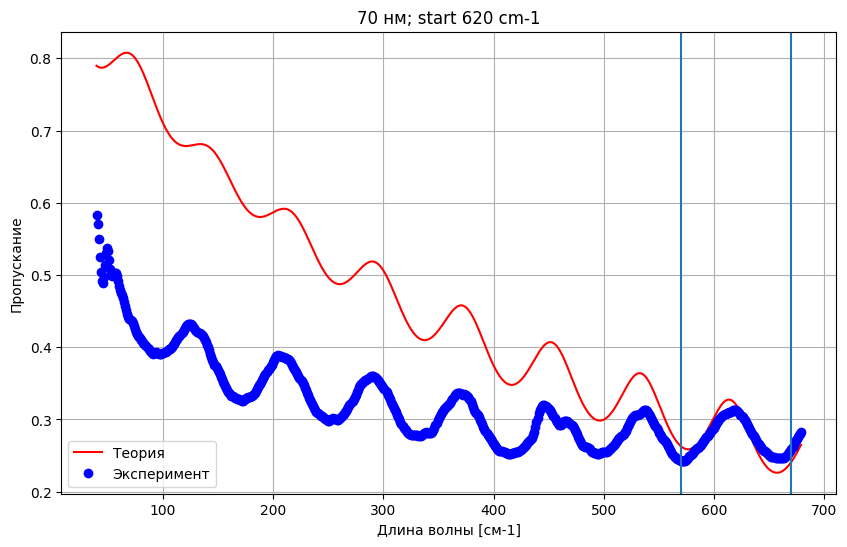

DEBUG - wl_begins = [ 89.21451106 137.43857109 185.66263112 233.88669115 282.11075118
 330.33481121 378.55887124 426.78293128 475.00699131 523.23105134
 571.45511137 619.6791714 ]
DEBUG - eps_x_axis = [112.08938861  72.75977857  53.86113479  42.75574617  35.44707161
  30.27231663  26.41597057  23.43111513  21.05232172  19.11201557
  17.49918725  16.1373828 ]


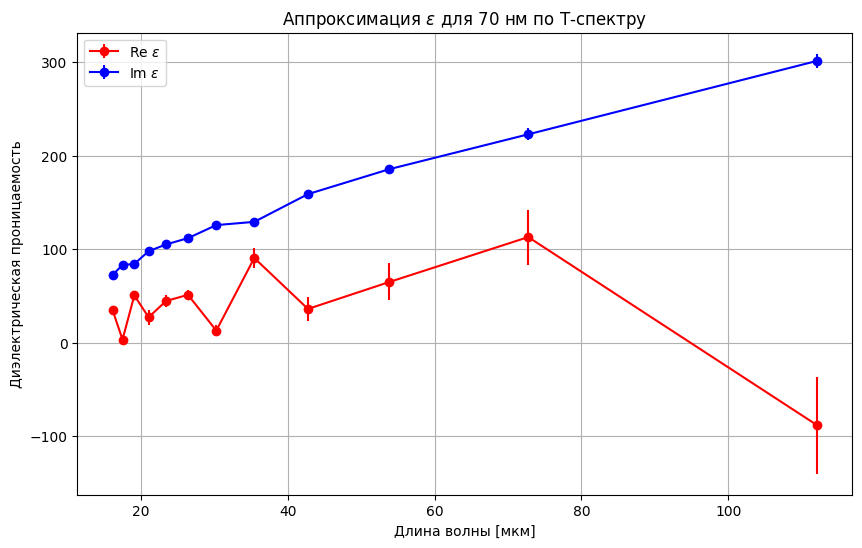

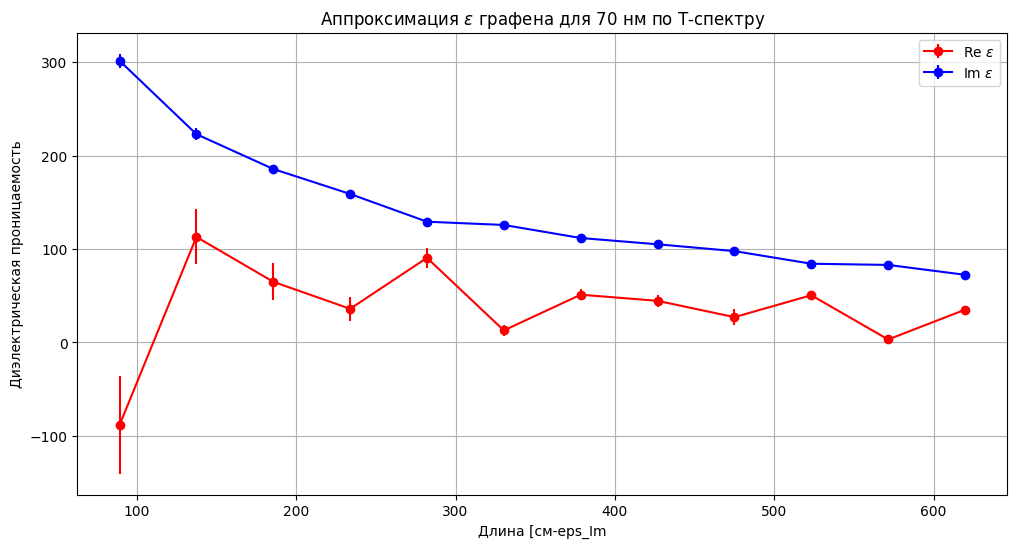

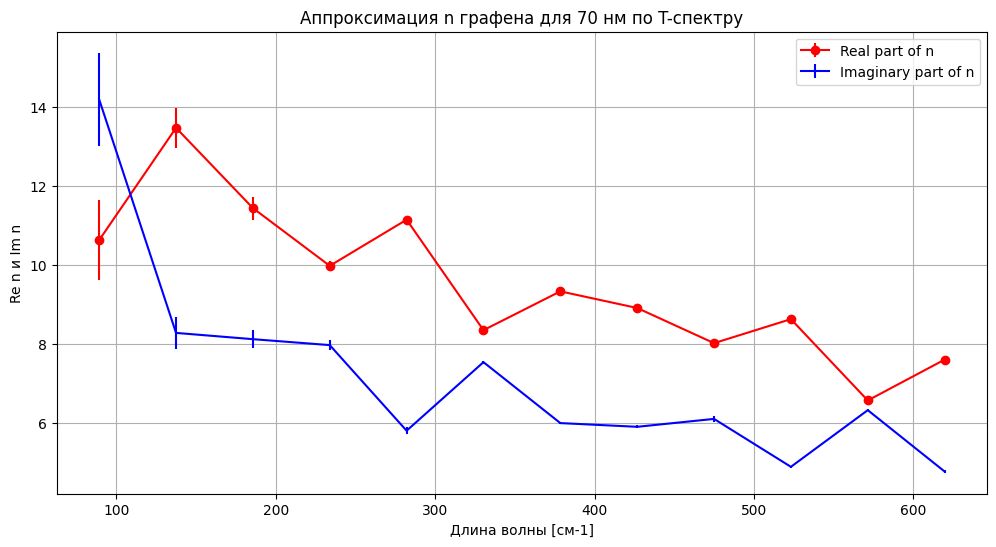

In [34]:
T_70 = spectral_fitting(transmit_dict, '70 нм', 'T', 100, 50, [(-inf, -inf),(inf, inf)], 42, savefig=True,
                       output_path=r"C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Fitting results",
                       folder_name="Printed graphene transmission 70 нм", draw_plots=True,  
)

INFO - gr_thk= 7.00e-08 m
DEBUG - (wavelength, optical data): [(39.5437292255, 0.3301858008), (40.5082104261, 0.3412149847), (41.4726916268, 0.3475590646), (42.4371728274, 0.3521916866), (43.401654028, 0.3570200205), (44.3661352286, 0.3619206548), (45.3306164293, 0.3661621511), (46.2950976299, 0.3694792688), (47.2595788305, 0.3720399439), (48.2240600311, 0.3734939098), (49.1885412317, 0.3733375967), (50.1530224324, 0.3712766171), (51.117503633, 0.3673890531), (52.0819848336, 0.361833185), (53.0464660342, 0.3546926975), (54.0109472349, 0.3462622166), (54.9754284355, 0.3373100758), (55.9399096361, 0.3288434148), (56.9043908367, 0.3215465248), (57.8688720373, 0.3154453933), (58.833353238, 0.3100698292), (59.7978344386, 0.3048884571), (60.7623156392, 0.2996200323), (61.7267968398, 0.2942329943), (62.6912780405, 0.2887046635), (63.6557592411, 0.2830720842), (64.6202404417, 0.2772414684), (65.5847216423, 0.2711964548), (66.5492028429, 0.2651169598), (67.5136840436, 0.2593162358), (68.4781652

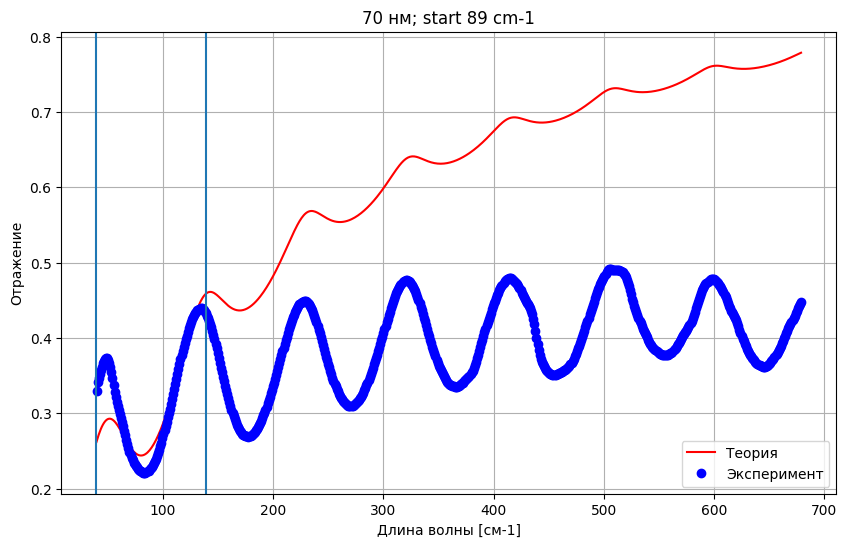

DEBUG - Segment: wavelength range 89.7 to 185.2
INFO - popt= [16.56323435  8.30970099], perr= [0.26147237 0.75396985], wl_begin = 137.4385710887


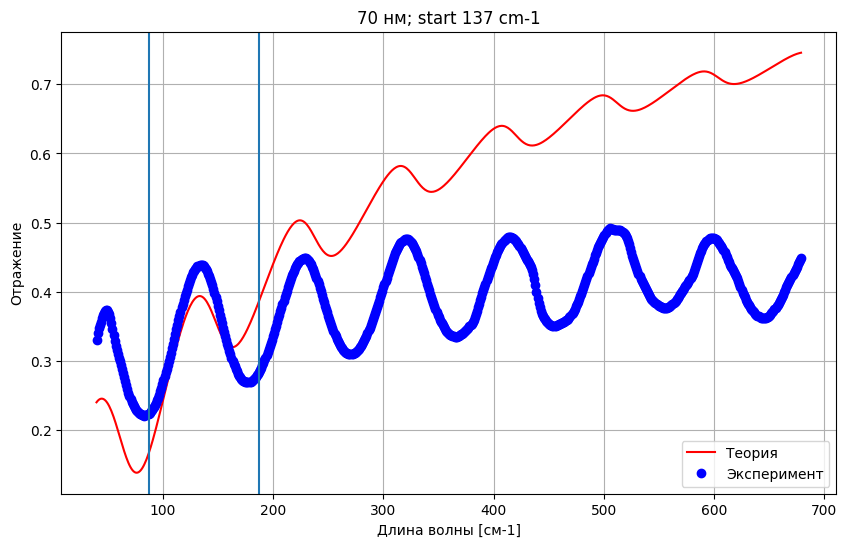

DEBUG - Segment: wavelength range 137.9 to 233.4
INFO - popt= [12.20156776 11.93073517], perr= [0.30023771 0.30519858], wl_begin = 185.66263111985


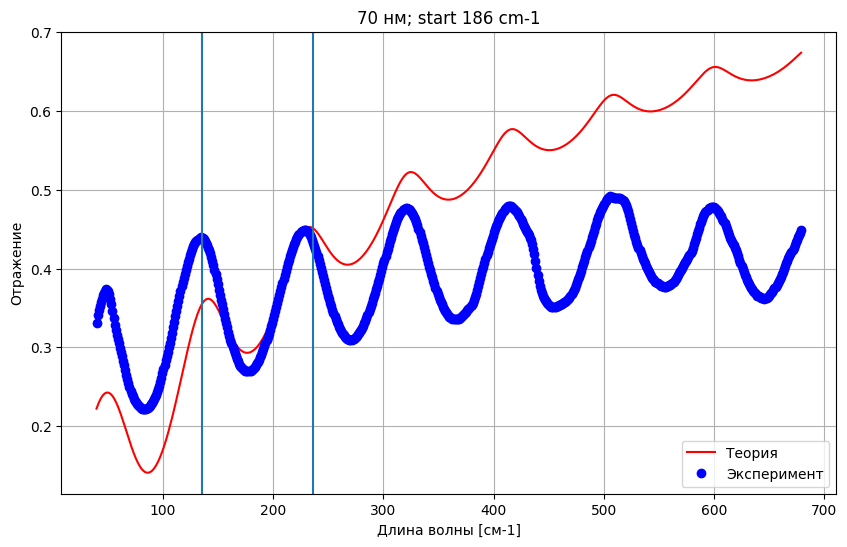

DEBUG - Segment: wavelength range 186.1 to 281.6
INFO - popt= [12.9922016   8.37416084], perr= [0.19211844 0.39489682], wl_begin = 233.88669115095


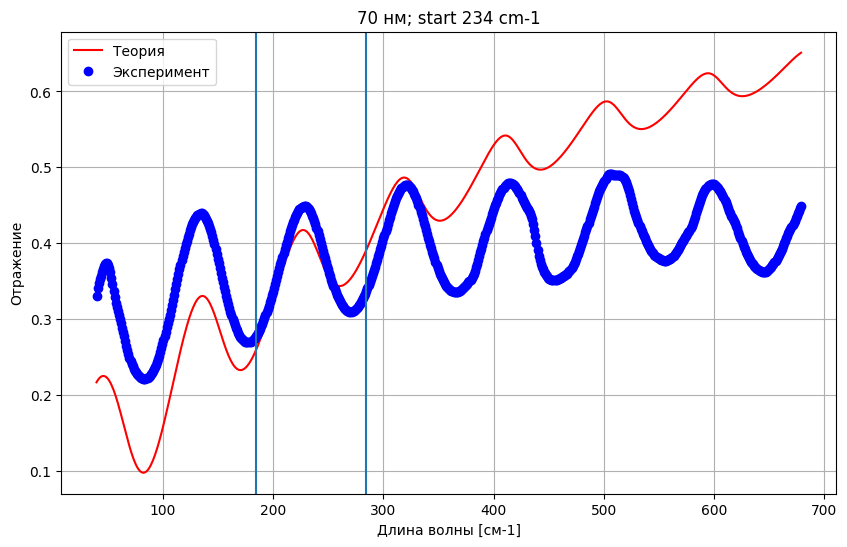

DEBUG - Segment: wavelength range 234.4 to 329.9
INFO - popt= [11.02893287 10.06061183], perr= [0.17080405 0.19115544], wl_begin = 282.1107511821


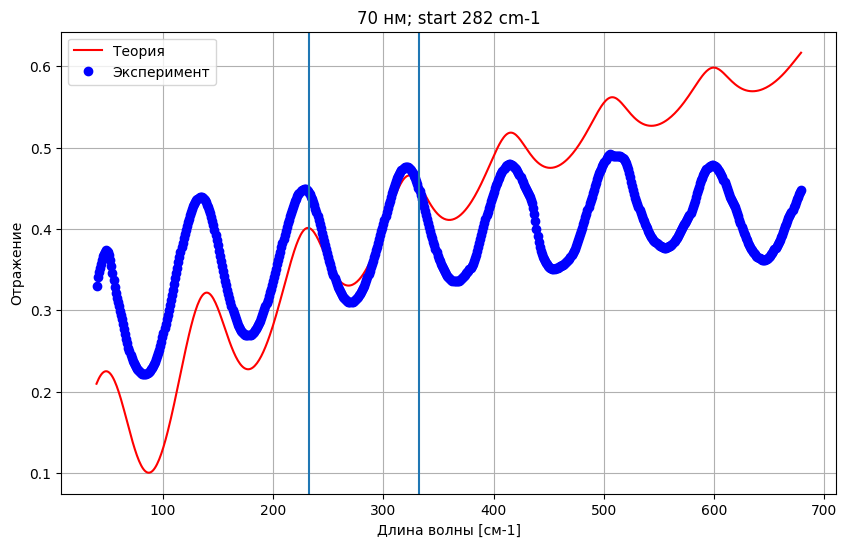

DEBUG - Segment: wavelength range 282.6 to 378.1
INFO - popt= [11.28064502  8.23264935], perr= [0.23023424 0.39384402], wl_begin = 330.3348112132


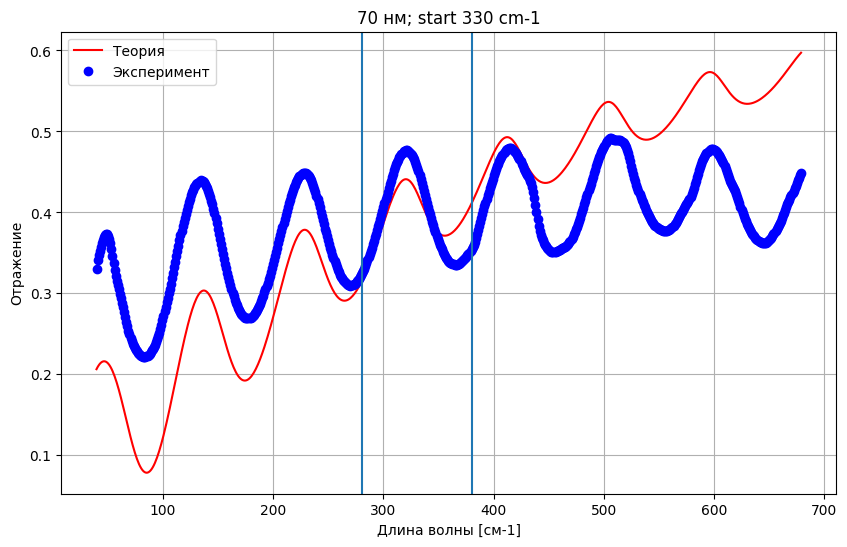

DEBUG - Segment: wavelength range 330.8 to 426.3
INFO - popt= [9.2377561  9.63586764], perr= [0.15705636 0.1381332 ], wl_begin = 378.55887124435


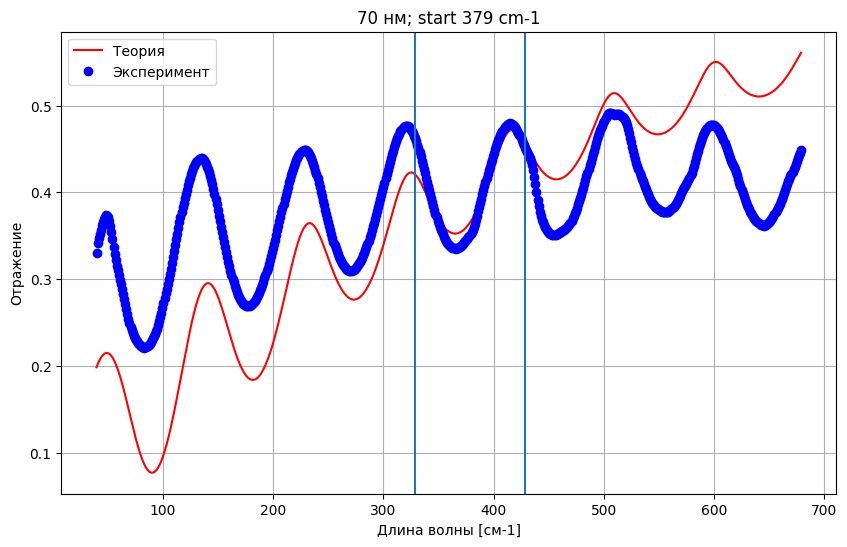

DEBUG - Segment: wavelength range 379.0 to 474.5
INFO - popt= [9.64712088 8.2413987 ], perr= [0.23214476 0.29946113], wl_begin = 426.7829312755


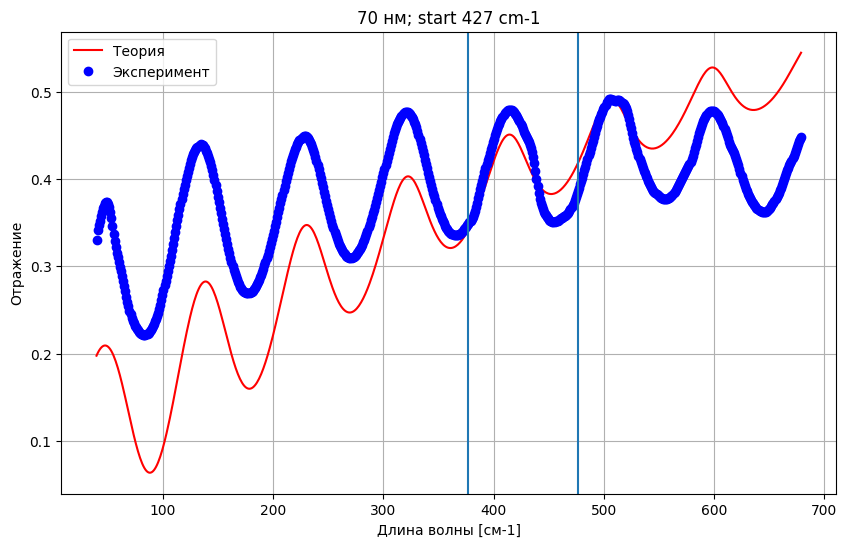

DEBUG - Segment: wavelength range 427.3 to 522.7
INFO - popt= [8.43068763 8.99190487], perr= [0.1730838  0.14417251], wl_begin = 475.0069913066


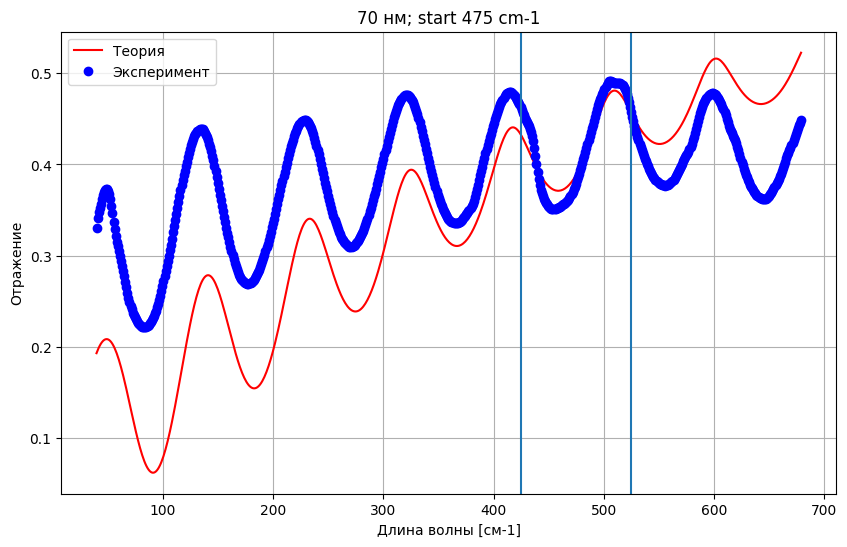

DEBUG - Segment: wavelength range 475.5 to 571.0
INFO - popt= [8.469883   8.47500786], perr= [0.23284323 0.22522258], wl_begin = 523.23105133775


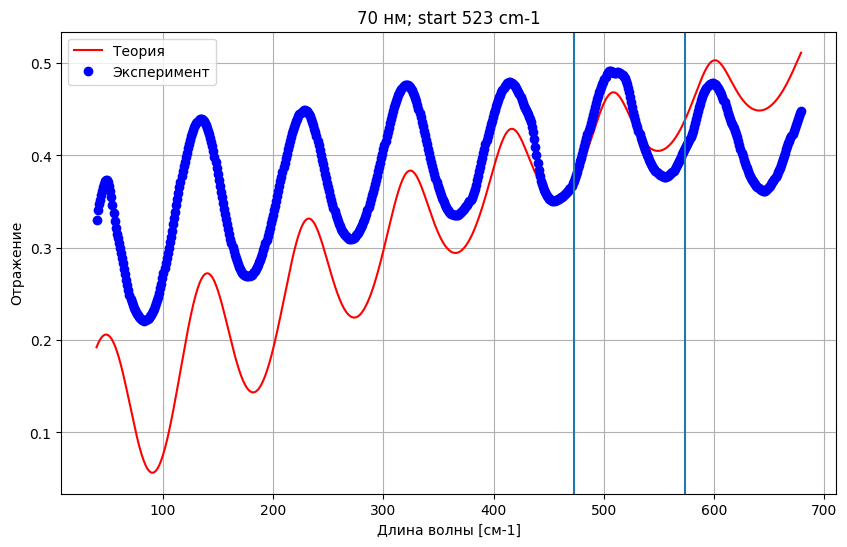

DEBUG - Segment: wavelength range 523.7 to 619.2
INFO - popt= [7.43990899 8.58844743], perr= [0.14463967 0.10289004], wl_begin = 571.45511136885


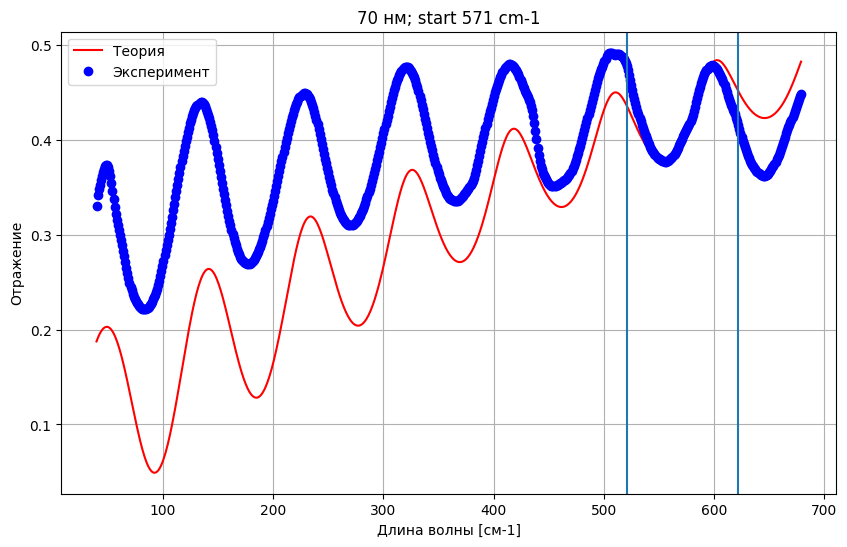

DEBUG - Segment: wavelength range 571.9 to 667.4
INFO - popt= [7.87247118 7.27588999], perr= [0.1522471  0.16797907], wl_begin = 619.6791714


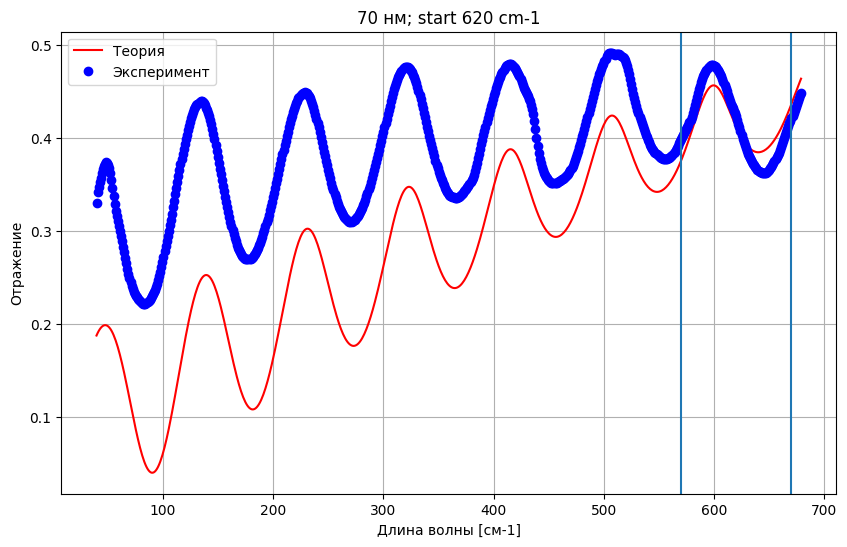

DEBUG - wl_begins = [ 89.21451106 137.43857109 185.66263112 233.88669115 282.11075118
 330.33481121 378.55887124 426.78293128 475.00699131 523.23105134
 571.45511137 619.6791714 ]
DEBUG - eps_x_axis = [112.08938861  72.75977857  53.86113479  42.75574617  35.44707161
  30.27231663  26.41597057  23.43111513  21.05232172  19.11201557
  17.49918725  16.1373828 ]


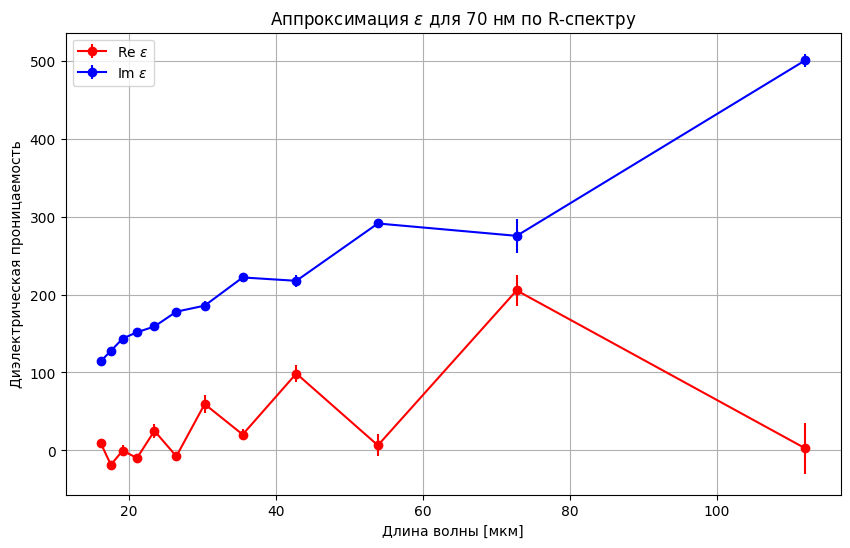

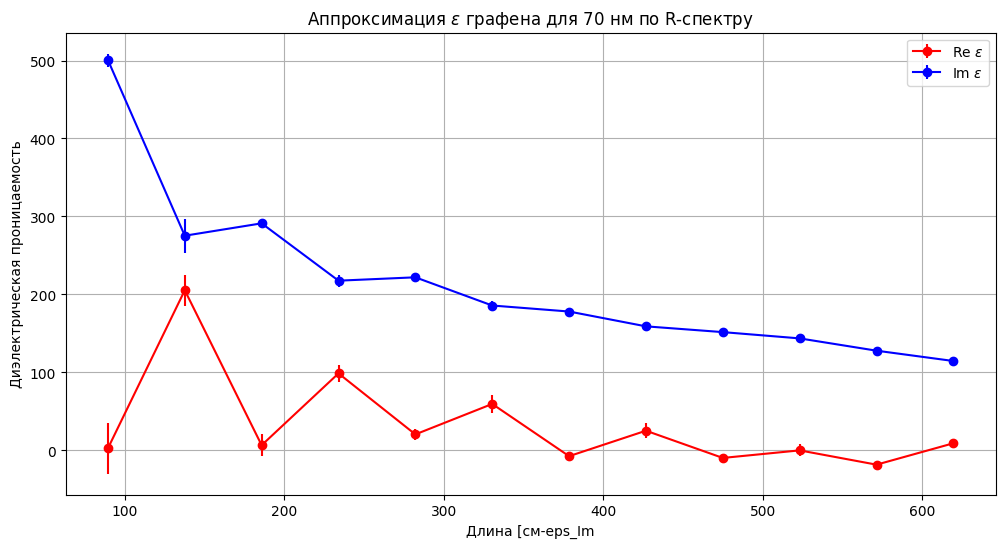

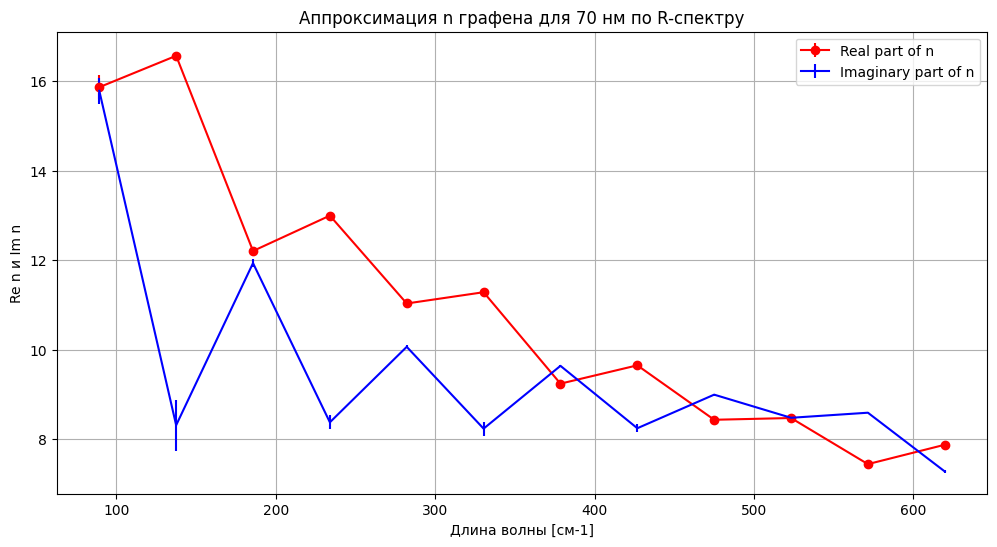

In [35]:
R_70 = spectral_fitting(reflect_dict, '70 нм', 'R', 100, 50, [(-inf, -inf),(inf, inf)], 42, savefig=True,
                       output_path=r"C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Fitting results",
                       folder_name="Printed graphene reflection 70 нм", draw_plots=True)

<table> <thead><tr><th>\($\tildeν$) (cm⁻¹)</th><th>ω (rad s⁻¹)</th><th>ε₂ = σ/(ε₀ ω)</th><th>n′ = √[(|ε|+ε₁)/2]</th><th>k = √[(|ε|–ε₁)/2]</th></tr></thead> <tbody> <tr><td>100</td><td>1.9 × 10¹³</td><td>≈ 8.3 × 10²</td><td>≈ 20</td><td>≈ 20</td></tr> <tr><td>300</td><td>5.7 × 10¹³</td><td>≈ 2.8 × 10²</td><td>≈ 12</td><td>≈ 12</td></tr> <tr><td>600</td><td>1.1 × 10¹⁴</td><td>≈ 1.4 × 10²</td><td>≈ 8.5</td><td>≈ 8.4</td></tr> </tbody> </table>

INFO - gr_thk= 3.50e-08 m
DEBUG - (wavelength, optical data): [(39.5437292255, 0.6399410367), (40.5082104261, 0.635772109), (41.4726916268, 0.6252501011), (42.4371728274, 0.6142079234), (43.401654028, 0.608099401), (44.3661352286, 0.6092792749), (45.3306164293, 0.6173888445), (46.2950976299, 0.6309320927), (47.2595788305, 0.6482182145), (48.2240600311, 0.6663740873), (49.1885412317, 0.6810383797), (50.1530224324, 0.6875290275), (51.117503633, 0.683858633), (52.0819848336, 0.6724073291), (53.0464660342, 0.658438921), (54.0109472349, 0.6468008161), (54.9754284355, 0.6394061446), (55.9399096361, 0.6350531578), (56.9043908367, 0.6311799884), (57.8688720373, 0.6260237098), (58.833353238, 0.6197322607), (59.7978344386, 0.6139296293), (60.7623156392, 0.6104118824), (61.7267968398, 0.6100602746), (62.6912780405, 0.612605989), (63.6557592411, 0.6167877316), (64.6202404417, 0.6213287115), (65.5847216423, 0.625123322), (66.5492028429, 0.6271603703), (67.5136840436, 0.6265969872), (68.4781652442, 

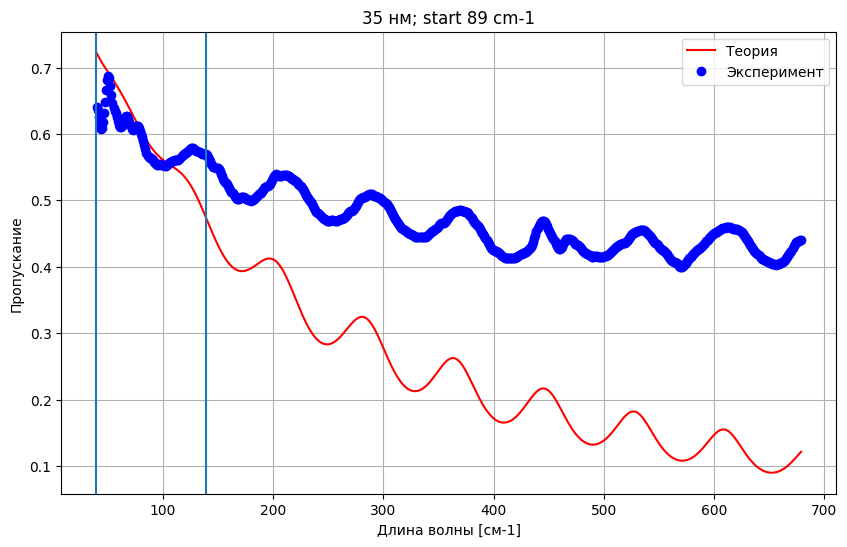

DEBUG - Segment: wavelength range 89.7 to 185.2
INFO - popt= [13.70280917  8.70375685], perr= [0.65797928 0.54177476], wl_begin = 137.4385710887


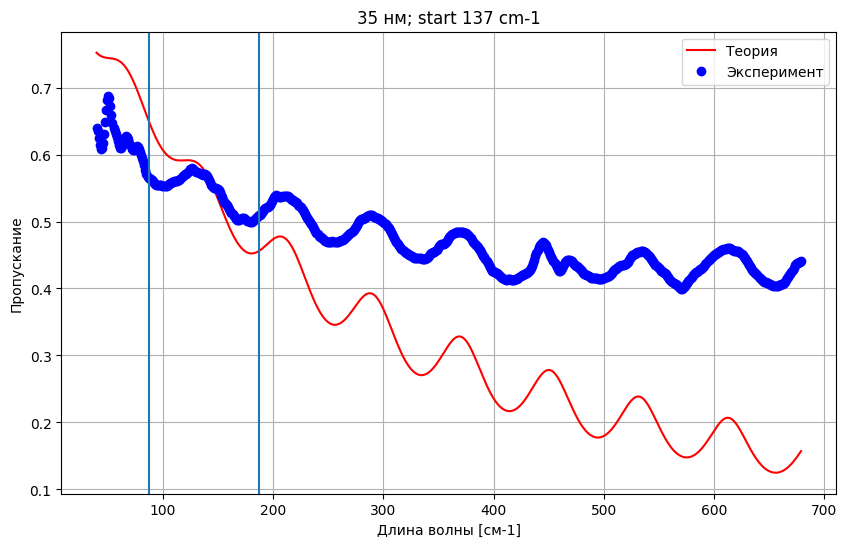

DEBUG - Segment: wavelength range 137.9 to 233.4
INFO - popt= [12.1802125  8.2270883], perr= [0.45229316 0.35181039], wl_begin = 185.66263111985


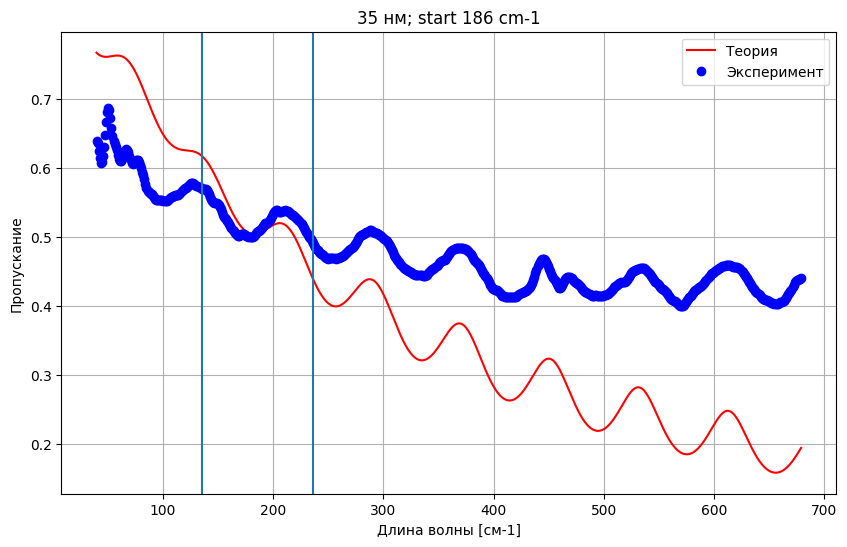

DEBUG - Segment: wavelength range 186.1 to 281.6
INFO - popt= [10.0585995   8.55133703], perr= [0.27996903 0.26603367], wl_begin = 233.88669115095


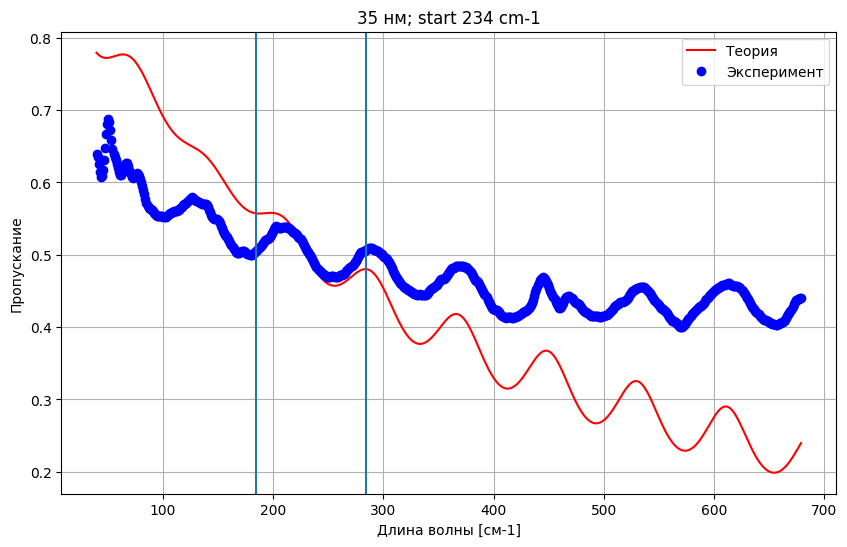

DEBUG - Segment: wavelength range 234.4 to 329.9
INFO - popt= [11.06879887  6.73722365], perr= [0.28091181 0.22464725], wl_begin = 282.1107511821


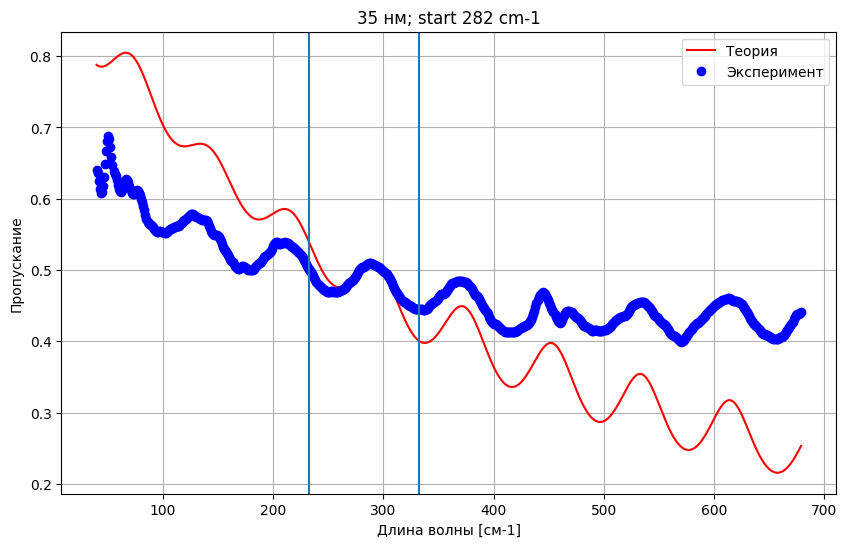

DEBUG - Segment: wavelength range 282.6 to 378.1
INFO - popt= [8.40009126 8.24558201], perr= [0.14733372 0.14202996], wl_begin = 330.3348112132


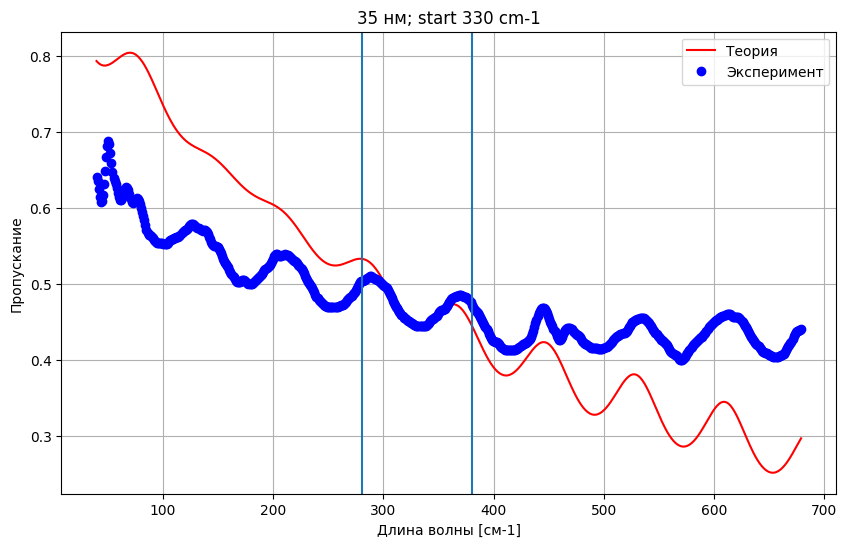

DEBUG - Segment: wavelength range 330.8 to 426.3
INFO - popt= [9.24474124 6.85037031], perr= [0.14094057 0.1282418 ], wl_begin = 378.55887124435


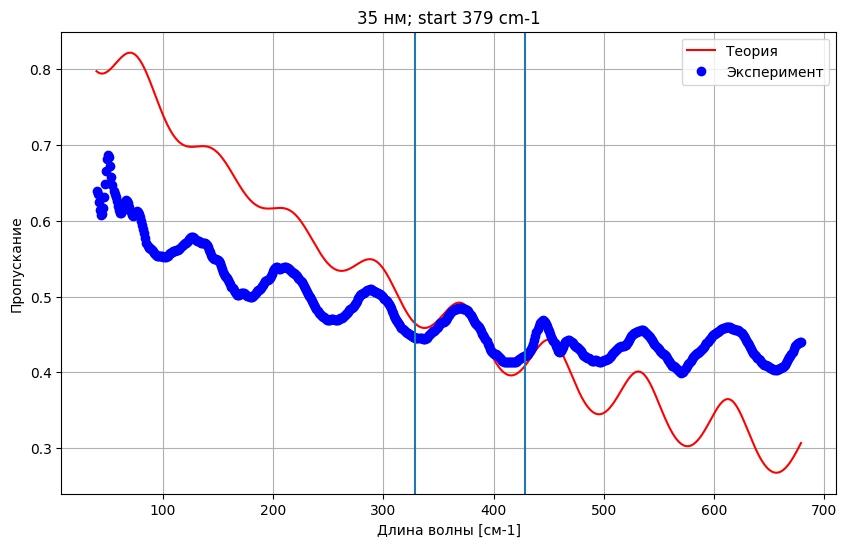

DEBUG - Segment: wavelength range 379.0 to 474.5
INFO - popt= [8.63056902 7.01679512], perr= [0.16146091 0.13974938], wl_begin = 426.7829312755


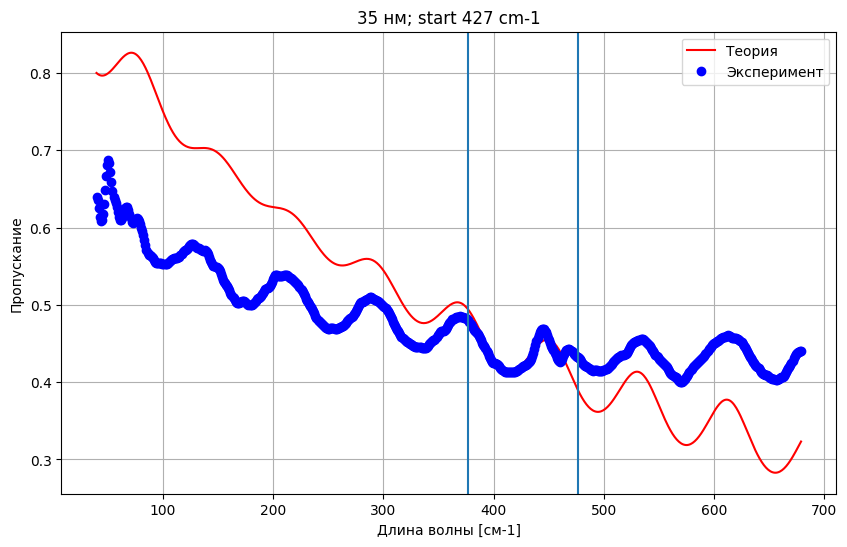

DEBUG - Segment: wavelength range 427.3 to 522.7
INFO - popt= [7.62606869 7.23556257], perr= [0.2552703 0.2565093], wl_begin = 475.0069913066


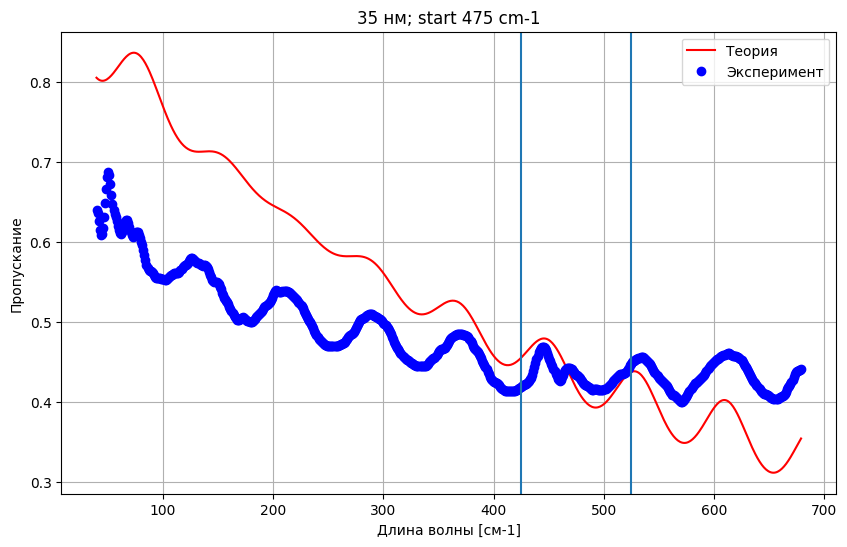

DEBUG - Segment: wavelength range 475.5 to 571.0
INFO - popt= [8.27485321 5.99077056], perr= [0.13632751 0.11713103], wl_begin = 523.23105133775


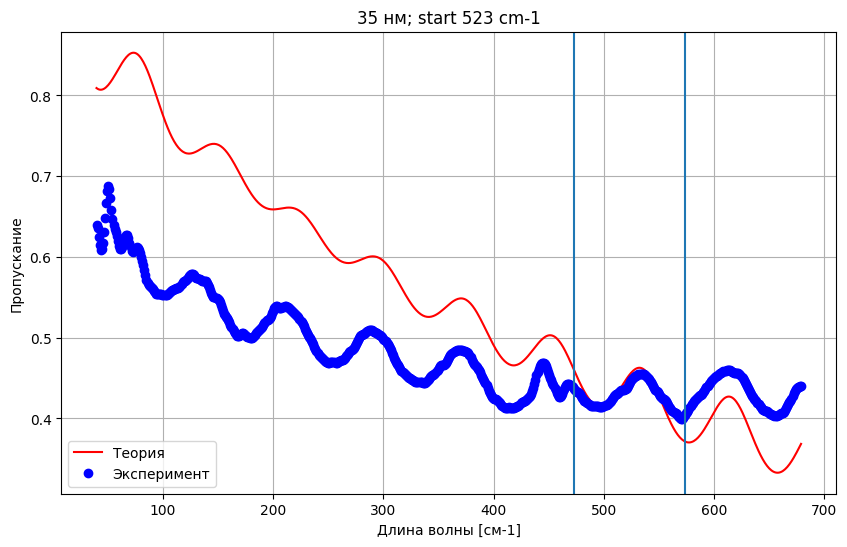

DEBUG - Segment: wavelength range 523.7 to 619.2
INFO - popt= [6.15174474 7.43198788], perr= [0.14893711 0.15656134], wl_begin = 571.45511136885


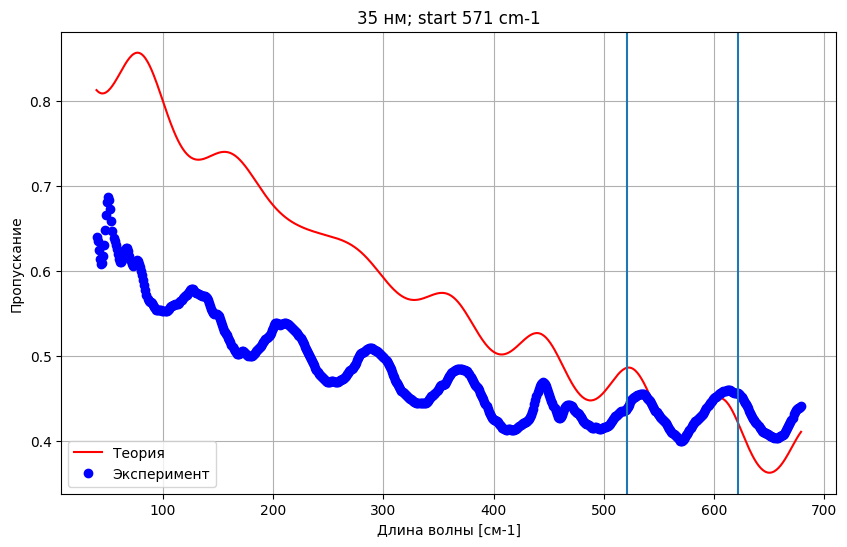

DEBUG - Segment: wavelength range 571.9 to 667.4
INFO - popt= [7.21600801 5.77531318], perr= [0.12633902 0.11733988], wl_begin = 619.6791714


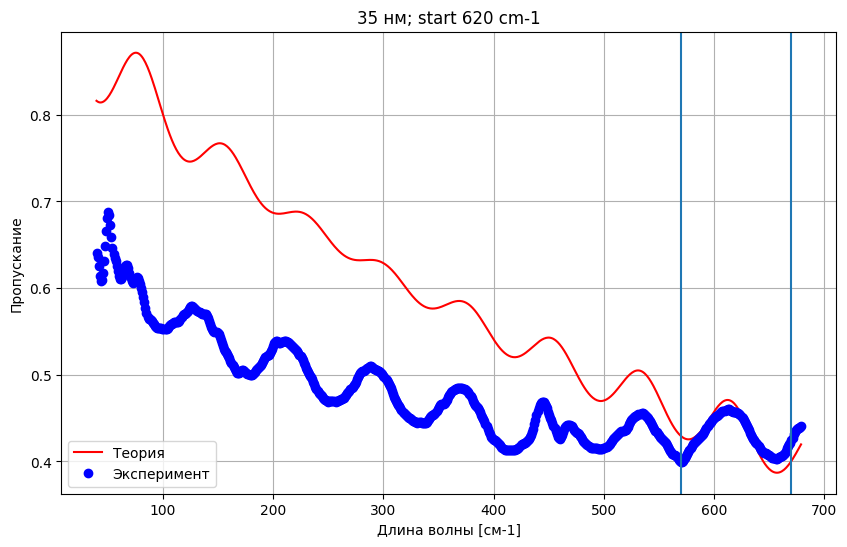

DEBUG - wl_begins = [ 89.21451106 137.43857109 185.66263112 233.88669115 282.11075118
 330.33481121 378.55887124 426.78293128 475.00699131 523.23105134
 571.45511137 619.6791714 ]
DEBUG - eps_x_axis = [112.08938861  72.75977857  53.86113479  42.75574617  35.44707161
  30.27231663  26.41597057  23.43111513  21.05232172  19.11201557
  17.49918725  16.1373828 ]


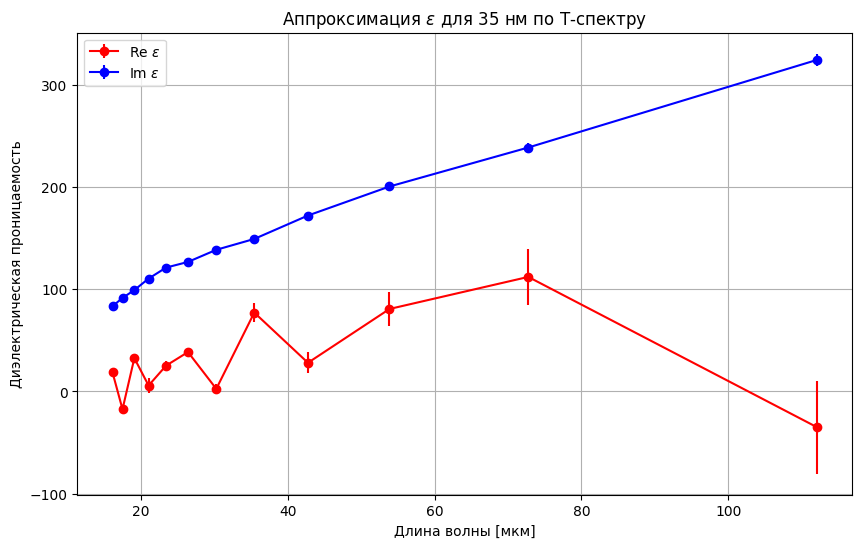

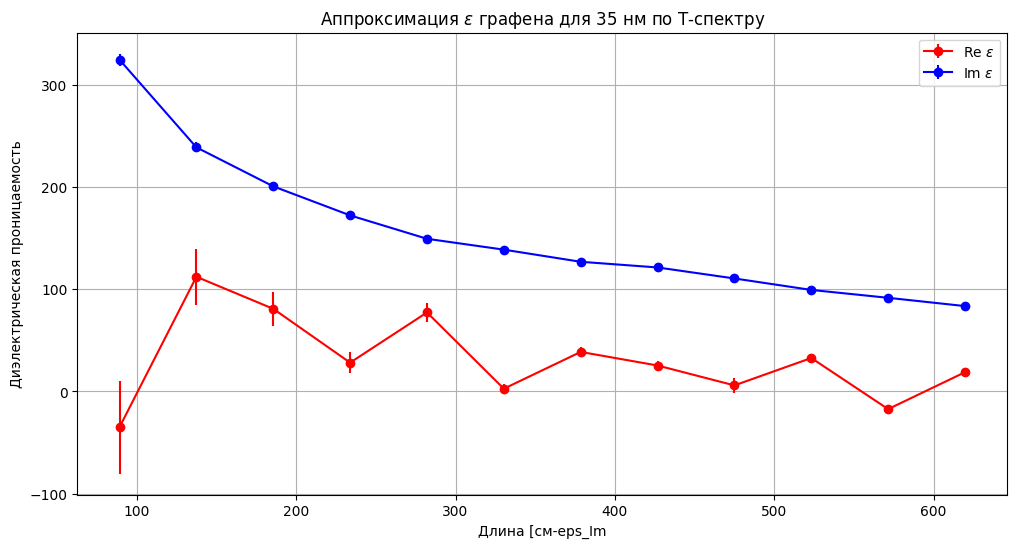

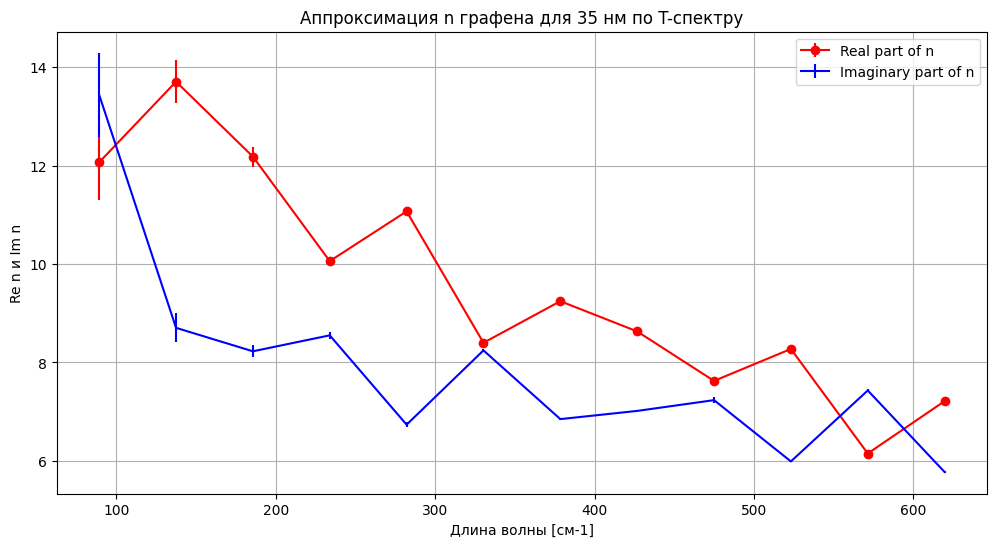

In [38]:
T_35 = spectral_fitting(transmit_dict, '35 нм', 'T', 100, 50, [(-inf, -inf),(inf, inf)], 42, savefig=True,
                       output_path=r"C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Fitting results",
                       folder_name="Printed graphene transmission 35 nm", draw_plots=True)

INFO - gr_thk= 3.00e-08 m
DEBUG - (wavelength, optical data): [(49.1741515183, 0.2975769639), (50.1383505676, 0.2872564793), (51.102549617, 0.2765807211), (52.0667486664, 0.2672883272), (53.0309477158, 0.2596937716), (53.9951467651, 0.253179431), (54.9593458145, 0.2470364869), (55.9235448639, 0.2410993576), (56.8877439133, 0.2354633957), (57.8519429627, 0.2305226624), (58.816142012, 0.2270163447), (59.7803410614, 0.2257727683), (60.7445401108, 0.2270808518), (61.7087391602, 0.2301223278), (62.6729382095, 0.2329838276), (63.6371372589, 0.2337357551), (64.6013363083, 0.2314028144), (65.5655353577, 0.2264995873), (66.5297344071, 0.2205813974), (67.4939334564, 0.2153180242), (68.4581325058, 0.2117694318), (69.4223315552, 0.2101430893), (70.3865306046, 0.2098641098), (71.3507296539, 0.2097931653), (72.3149287033, 0.208608672), (73.2791277527, 0.2053804398), (74.2433268021, 0.2000019699), (75.2075258515, 0.1932155341), (76.1717249008, 0.1862400174), (77.1359239502, 0.1802334338), (78.1001229

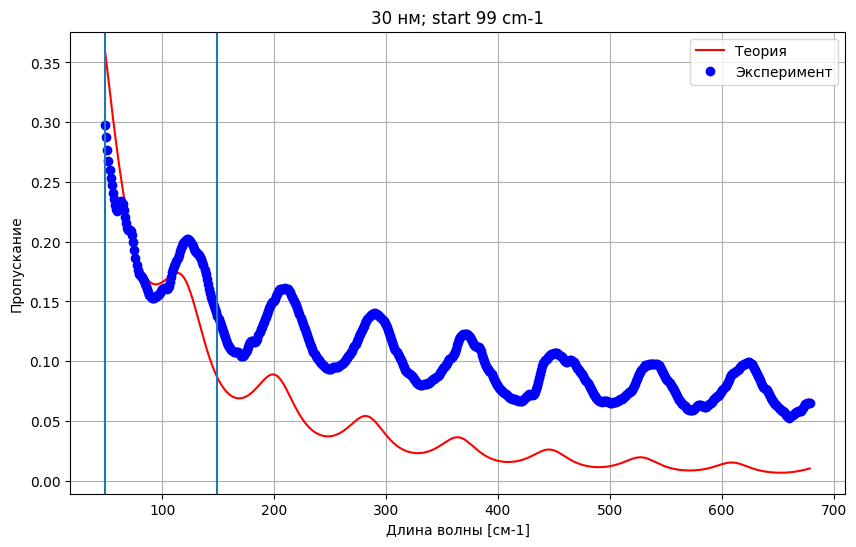

DEBUG - Segment: wavelength range 99.3 to 194.8
INFO - popt= [33.30957007 19.99717474], perr= [1.94176212 2.13838155], wl_begin = 147.0403550301


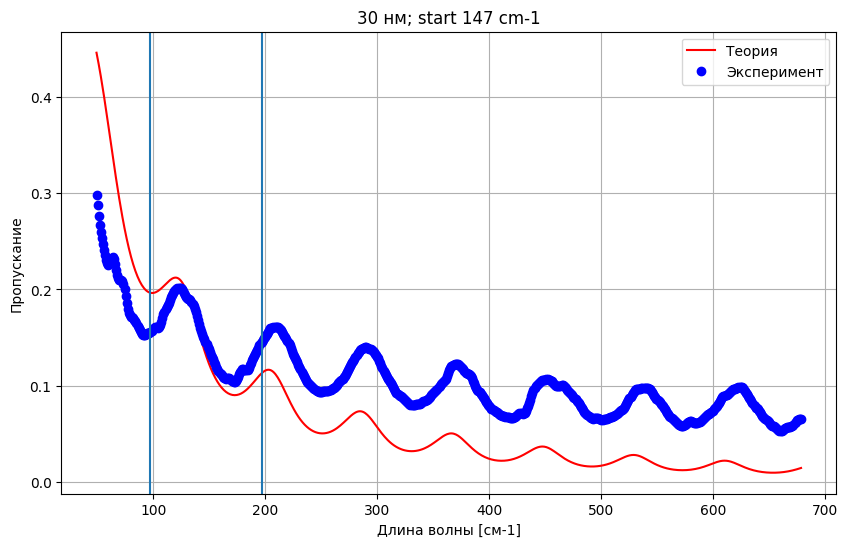

DEBUG - Segment: wavelength range 147.5 to 243.0
INFO - popt= [33.30527706 13.88944601], perr= [2.16896791 2.71269291], wl_begin = 195.25030749895


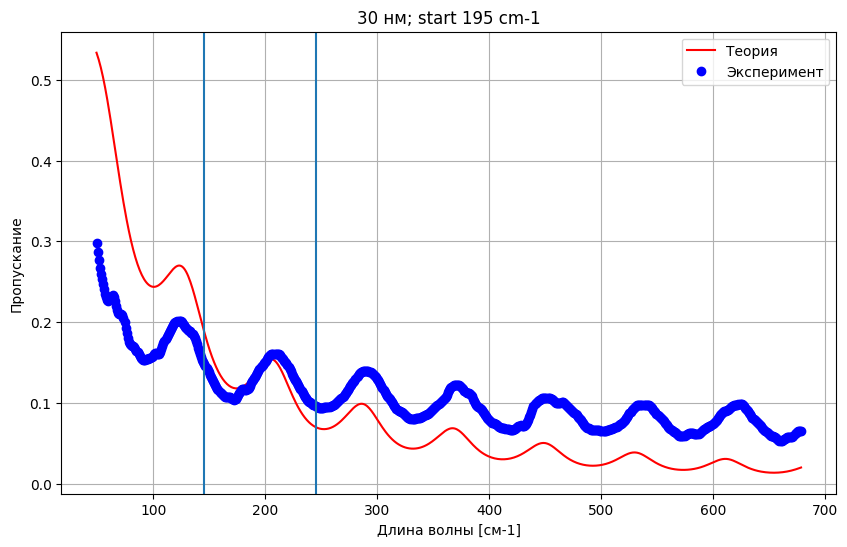

DEBUG - Segment: wavelength range 195.7 to 291.2
INFO - popt= [25.14553893 19.4594586 ], perr= [1.40694668 1.45239947], wl_begin = 243.4602599678


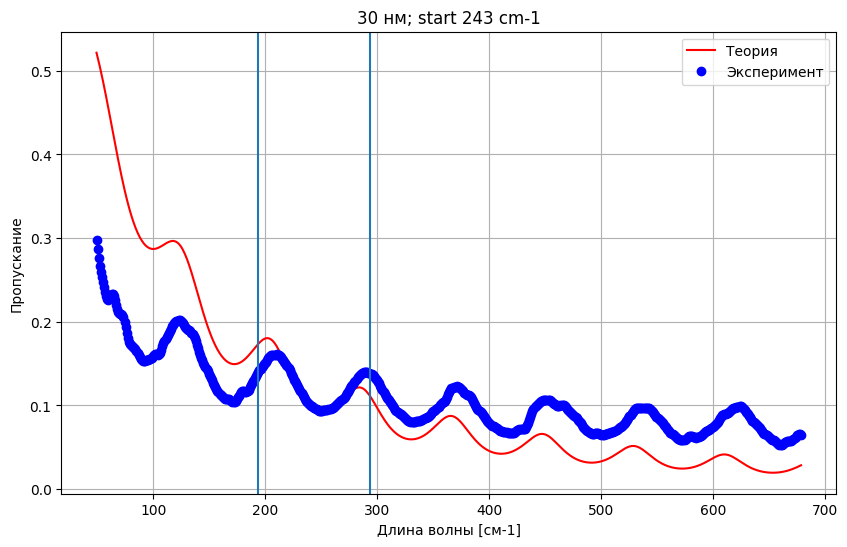

DEBUG - Segment: wavelength range 243.9 to 339.4
INFO - popt= [29.43896417 11.33674377], perr= [1.10466546 1.49314877], wl_begin = 291.6702124367


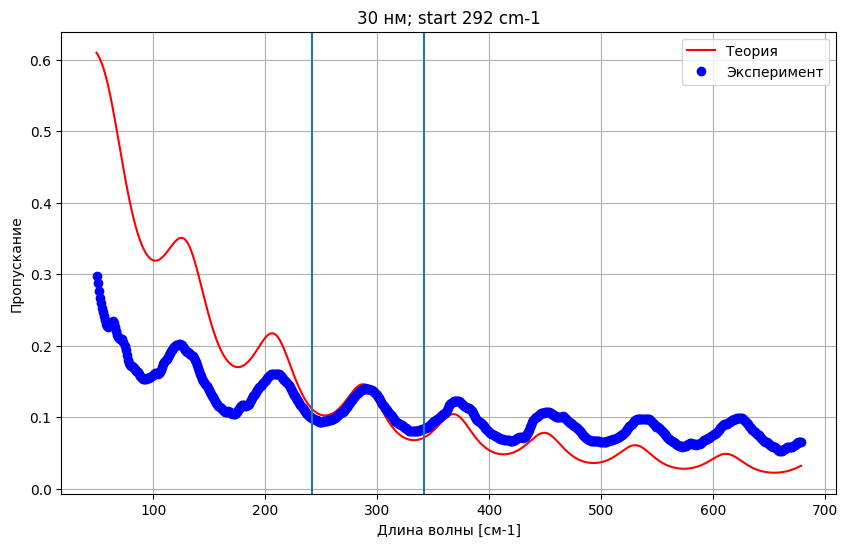

DEBUG - Segment: wavelength range 292.2 to 387.6
INFO - popt= [25.62499346 13.85982828], perr= [0.75012913 0.86553438], wl_begin = 339.88016490555003


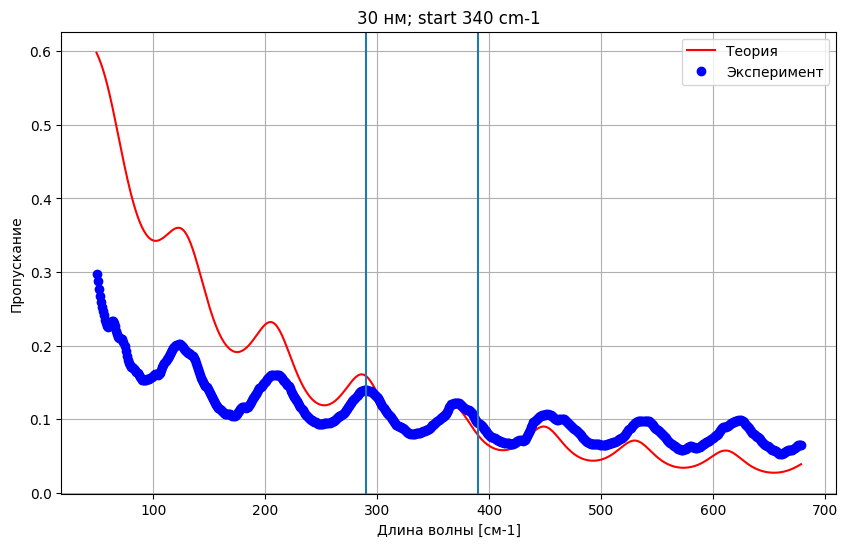

DEBUG - Segment: wavelength range 340.4 to 435.8
INFO - popt= [26.84049784 11.15140294], perr= [0.86651566 1.17808009], wl_begin = 388.0901173744


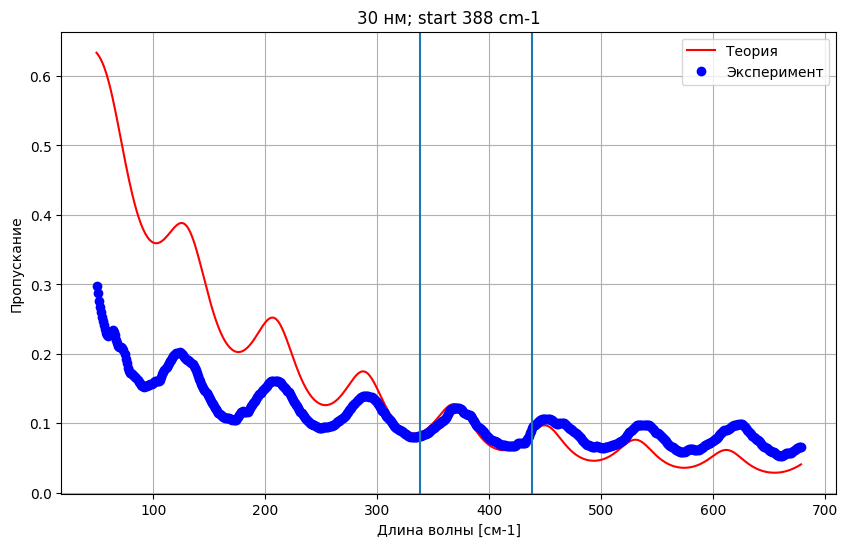

DEBUG - Segment: wavelength range 388.6 to 484.0
INFO - popt= [27.06312159  8.39368173], perr= [1.26821968 1.95426739], wl_begin = 436.3000698433


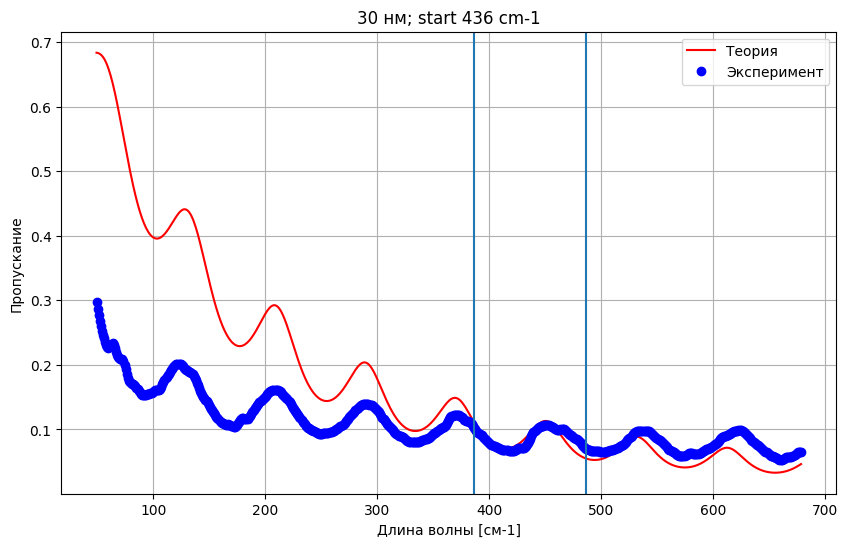

DEBUG - Segment: wavelength range 436.8 to 532.2
INFO - popt= [23.31052202 12.55967249], perr= [1.26058078 1.54392276], wl_begin = 484.5100223122


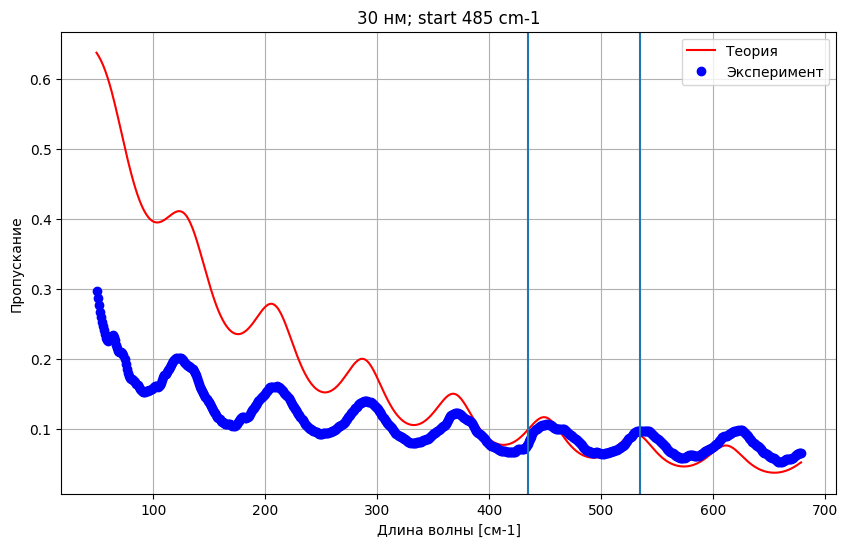

DEBUG - Segment: wavelength range 485.0 to 580.4
INFO - popt= [24.27668198  9.76081417], perr= [1.21143771 1.73114016], wl_begin = 532.71997478105


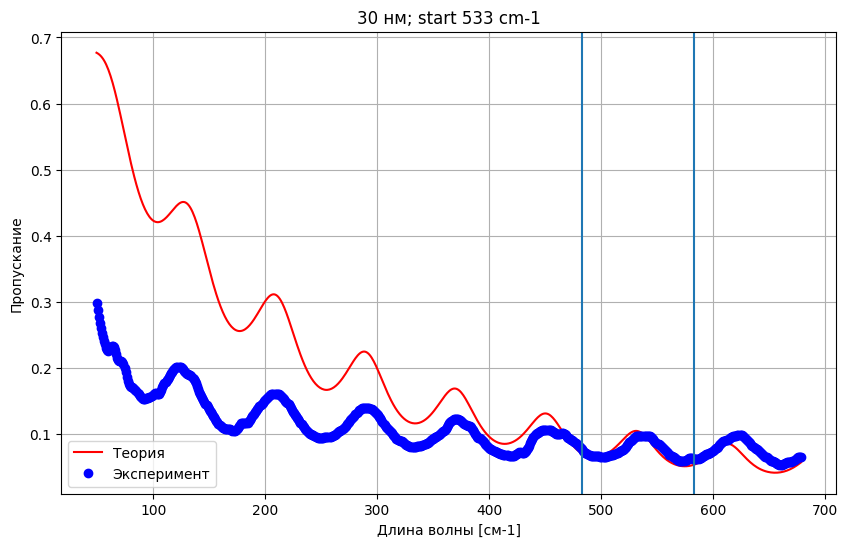

DEBUG - Segment: wavelength range 533.2 to 628.7
INFO - popt= [22.66928864 10.41812956], perr= [0.94340074 1.21713826], wl_begin = 580.9299272499


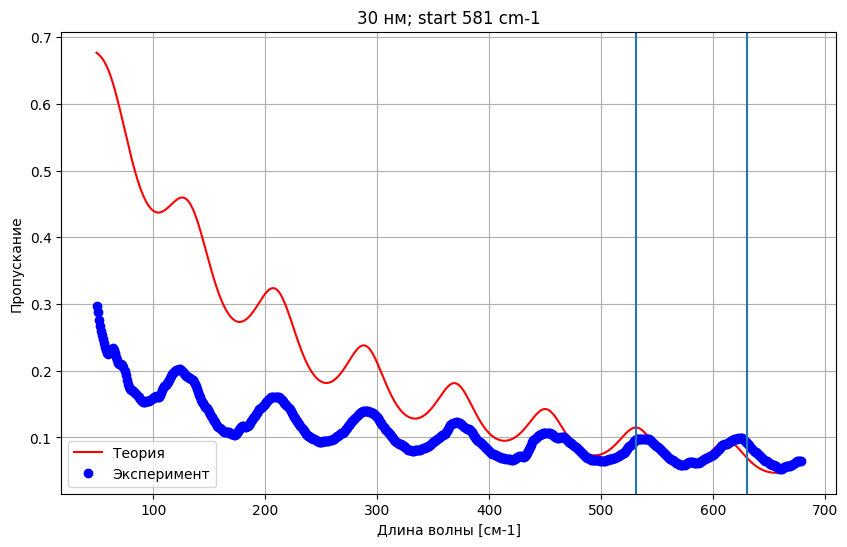

DEBUG - Segment: wavelength range 581.4 to 676.9
INFO - popt= [23.18024854  8.48886721], perr= [1.14021193 1.69980348], wl_begin = 629.1398797188


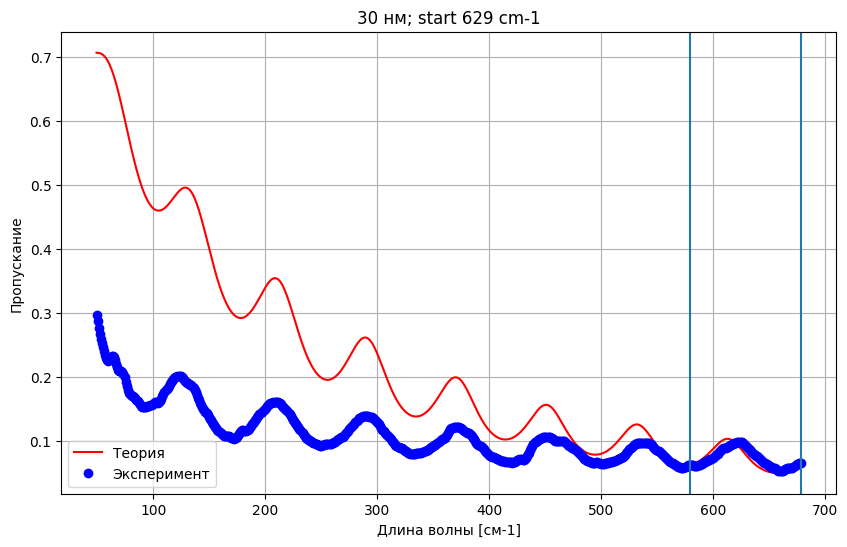

DEBUG - wl_begins = [ 98.83040256 147.04035503 195.2503075  243.46025997 291.67021244
 339.88016491 388.09011737 436.30006984 484.51002231 532.71997478
 580.92992725 629.13987972]
DEBUG - eps_x_axis = [101.18343891  68.00854091  51.21630858  41.0744653   34.28529748
  29.42213472  25.76721115  22.9200055   20.63940794  18.77158821
  17.21378006  15.89471646]


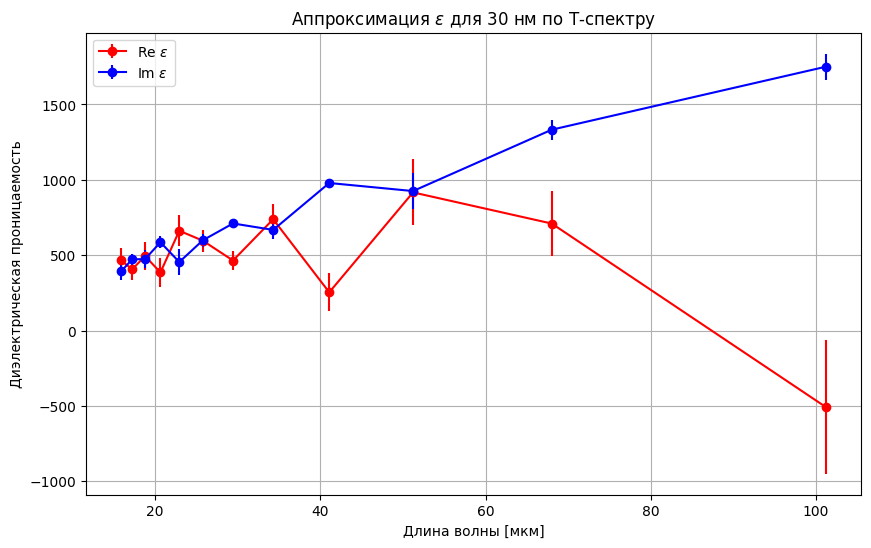

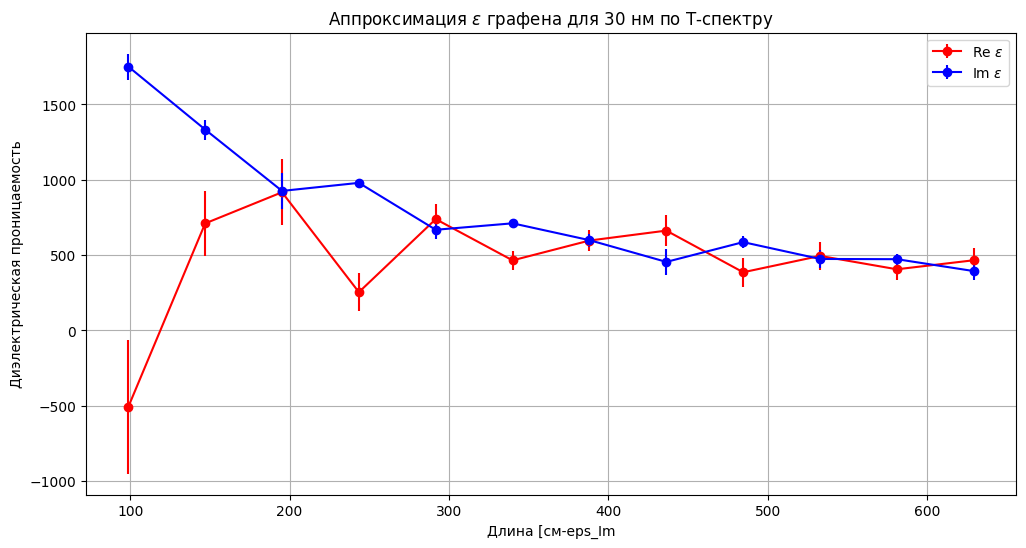

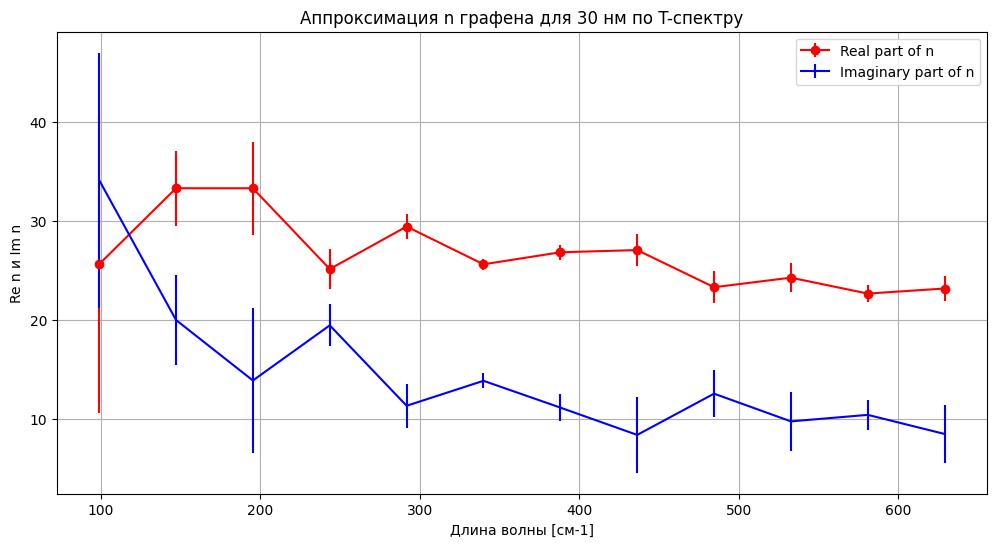

In [ ]:
filled_T_30 = spectral_fitting(transmit_filled_dict, '30 нм', 'T', 100, 50, [(-inf, 0),(inf, inf)], 42, savefig=True,
                       output_path=r"C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Fitting results",
                       folder_name="Filled graphene transmission 30 nm", draw_plots=True)

## Plot epsilon vs thickness

In [ ]:
from pathlib import Path

# --------- configuration ----------
root = Path(r"C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Transm_dis")




load_opts = dict(
    mode="T",
    pattern="L_",
    filename="T_printed",
    draw_plot=True,
)

fit_opts = dict(
    fit_mode="transmittance",
    interval=(41, 700),
    step=1,
    bounds=[(0, 10), (0, 10)],  # example
    start_wl=41,
    stop_wl=700,
    output_path=None,
    folder_name="fitting_epsilon",
    segmentation_method="fixed",
    draw_plots=True,
    savefig=False,
)
# -----------------------------------

optical_dicts = {}
fit_results   = {}

for file in sorted(root.glob(f"*{pattern}*{extension}")):
    name = file.stem

    optical_dict = load_data(
        path=str(root),
        filename=file.name,
        **load_opts
    )
    optical_dicts[name] = optical_dict          # keep raw data if you need it later

    fit_results[name] = spectral_fitting(
        optical_dict=optical_dict,
        name=name,
        **fit_opts
    )

# fit_results now holds whatever spectral_fitting() returns


NameError: name 'load_data' is not defined

## Interpolate epsilon and add noise

### Reflect/transmit 70 nm

INFO - gr_thk= 7.00e-08 m
DEBUG - (wavelength, optical data): [(39.5437292255, 0.3301858008), (40.5082104261, 0.3412149847), (41.4726916268, 0.3475590646), (42.4371728274, 0.3521916866), (43.401654028, 0.3570200205), (44.3661352286, 0.3619206548), (45.3306164293, 0.3661621511), (46.2950976299, 0.3694792688), (47.2595788305, 0.3720399439), (48.2240600311, 0.3734939098), (49.1885412317, 0.3733375967), (50.1530224324, 0.3712766171), (51.117503633, 0.3673890531), (52.0819848336, 0.361833185), (53.0464660342, 0.3546926975), (54.0109472349, 0.3462622166), (54.9754284355, 0.3373100758), (55.9399096361, 0.3288434148), (56.9043908367, 0.3215465248), (57.8688720373, 0.3154453933), (58.833353238, 0.3100698292), (59.7978344386, 0.3048884571), (60.7623156392, 0.2996200323), (61.7267968398, 0.2942329943), (62.6912780405, 0.2887046635), (63.6557592411, 0.2830720842), (64.6202404417, 0.2772414684), (65.5847216423, 0.2711964548), (66.5492028429, 0.2651169598), (67.5136840436, 0.2593162358), (68.4781652

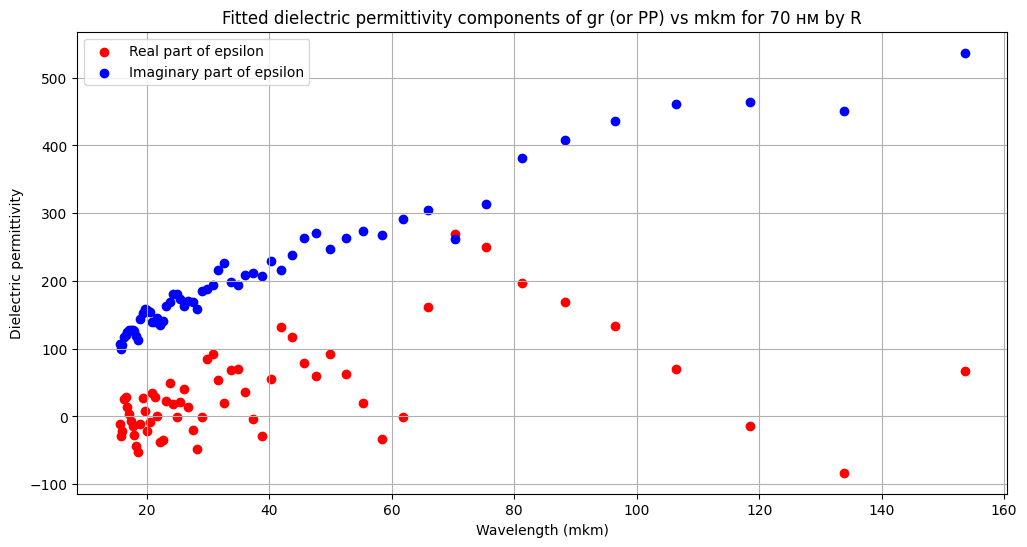

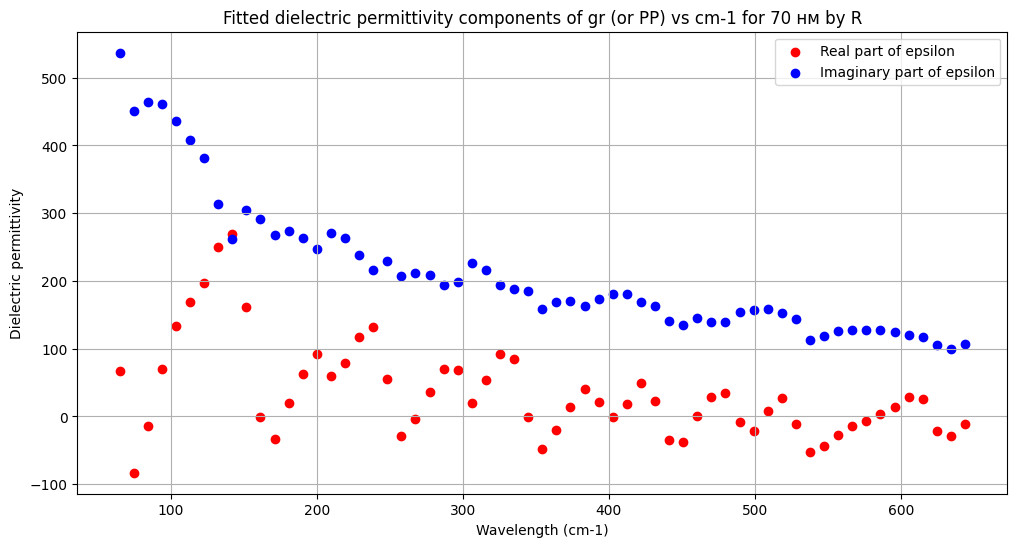

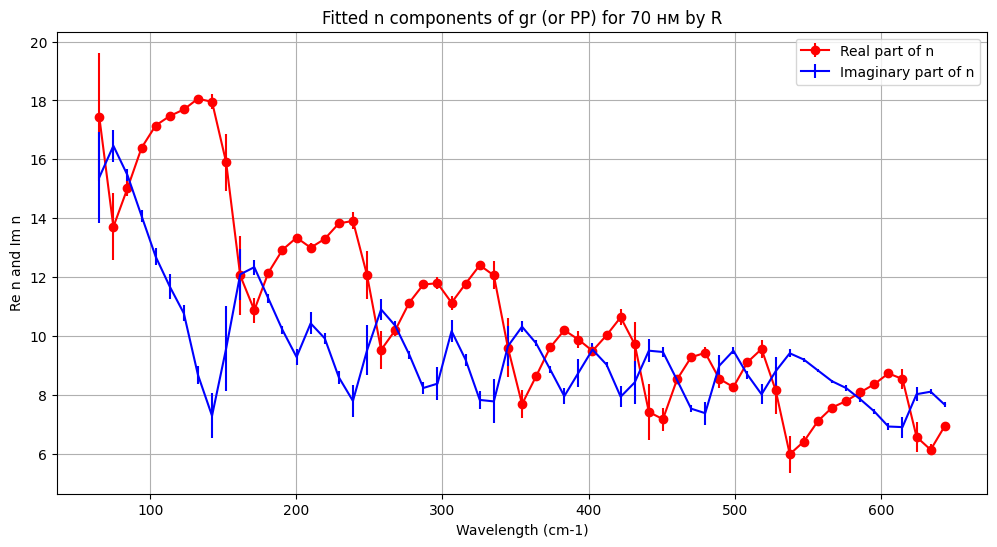

DEBUG - {'70 нм': {'wl_begins': array([ 65.10248104,  74.74729305,  84.39210505,  94.03691706,
       103.68172907, 113.32654107, 122.97135308, 132.61616509,
       142.26097709, 151.9057891 , 161.5506011 , 171.19541311,
       180.84022512, 190.48503712, 200.12984913, 209.77466114,
       219.41947314, 229.06428515, 238.70909715, 248.35390916,
       257.99872117, 267.64353317, 277.28834518, 286.93315719,
       296.57796919, 306.2227812 , 315.8675932 , 325.51240521,
       335.15721722, 344.80202922, 354.44684123, 364.09165324,
       373.73646524, 383.38127725, 393.02608925, 402.67090126,
       412.31571327, 421.96052527, 431.60533728, 441.25014928,
       450.89496129, 460.5397733 , 470.1845853 , 479.82939731,
       489.47420932, 499.11902132, 508.76383333, 518.40864533,
       528.05345734, 537.69826935, 547.34308135, 556.98789336,
       566.63270537, 576.27751737, 585.92232938, 595.56714138,
       605.21195339, 614.8567654 , 624.5015774 , 634.14638941,
       643.79120142]), 

In [40]:
from scipy.interpolate import interp1d
_name = input()
_fit_mode = input()
if _fit_mode == 'R':
      interp_dict = reflect_dict 
if _fit_mode == 'T':
      interp_dict = transmit_dict
thknss = interp_dict[_name][2]

_n_fit_dict, _eps_fit_dict=spectral_fitting(interp_dict, _name,_fit_mode, 50, 10, [(-inf, 0),(inf, inf)],42, 700,
                       output_path=None, 
                       folder_name="Printed graphene reflection_1",
                       draw_plots=False)
logger.debug(_n_fit_dict, _eps_fit_dict)




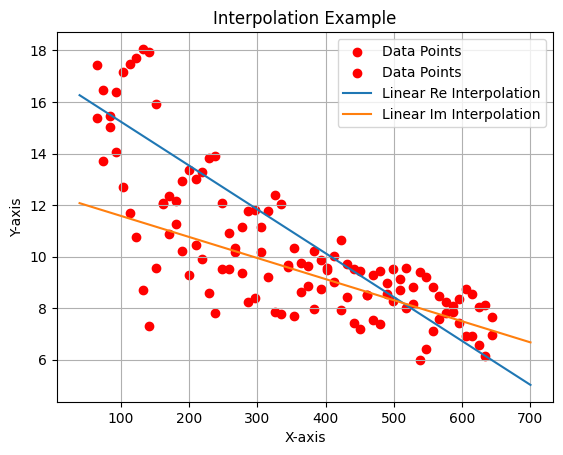

{'70 нм': (array([ 40.,  41.,  42.,  43.,  44.,  45.,  46.,  47.,  48.,  49.,  50.,
        51.,  52.,  53.,  54.,  55.,  56.,  57.,  58.,  59.,  60.,  61.,
        62.,  63.,  64.,  65.,  66.,  67.,  68.,  69.,  70.,  71.,  72.,
        73.,  74.,  75.,  76.,  77.,  78.,  79.,  80.,  81.,  82.,  83.,
        84.,  85.,  86.,  87.,  88.,  89.,  90.,  91.,  92.,  93.,  94.,
        95.,  96.,  97.,  98.,  99., 100., 101., 102., 103., 104., 105.,
       106., 107., 108., 109., 110., 111., 112., 113., 114., 115., 116.,
       117., 118., 119., 120., 121., 122., 123., 124., 125., 126., 127.,
       128., 129., 130., 131., 132., 133., 134., 135., 136., 137., 138.,
       139., 140., 141., 142., 143., 144., 145., 146., 147., 148., 149.,
       150., 151., 152., 153., 154., 155., 156., 157., 158., 159., 160.,
       161., 162., 163., 164., 165., 166., 167., 168., 169., 170., 171.,
       172., 173., 174., 175., 176., 177., 178., 179., 180., 181., 182.,
       183., 184., 185., 186., 187., 188

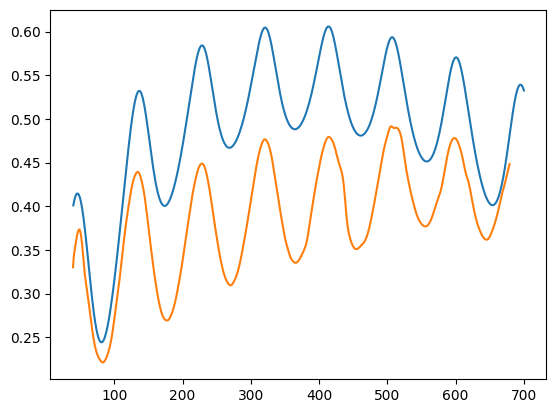

In [58]:
wl_begins, fit_ngr_re, fit_ngr_im  = (_n_fit_dict[_name]['wl_begins'] , 
      _n_fit_dict[_name]['fit_ngr_re'], _n_fit_dict[_name]['fit_ngr_im'])
linear_interp_re = interp1d(wl_begins, fit_ngr_re)
linear_interp_im = interp1d(wl_begins, fit_ngr_im)
a_re, b_re = np.polyfit(wl_begins, fit_ngr_re, 1)
a_im, b_im = np.polyfit(wl_begins, fit_ngr_im, 1)
x_new = np.linspace(40, 700, 661)

# Interpolated values + noise
np.random.seed(0)
noise_level = 0 
noise = np.random.normal(0, noise_level, len(x_new))
re_linear = a_re * x_new + b_re + noise
im_linear = a_im * x_new + b_im + noise


# Plotting the results
plt.scatter(wl_begins, fit_ngr_re, color='red', label='Data Points')
plt.scatter(wl_begins, fit_ngr_im, color='red', label='Data Points')
plt.plot(x_new, re_linear, label='Linear Re Interpolation')
plt.plot(x_new, im_linear, label='Linear Im Interpolation')
plt.legend()
plt.title('Interpolation Example')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.grid()
plt.show()



def compute_fit(wl:float, ngr_re, ngr_im, th_0, gr_thk, key):
      wl = 0.01/wl
      # Convert reciprocal wavelength to vacuum wavelength
      n_list = [1, ngr_re + 1j * ngr_im, N_PP, 1]
      d_list = [np.inf, gr_thk, PP_THK, np.inf]

      # Compute for s- and p-polarizations and average the results
      rf_s = coh_tmm(pol='s', n_list=n_list, d_list=d_list, th_0=th_0, lam_vac=wl)[key]
      rf_p = coh_tmm(pol='p', n_list=n_list, d_list=d_list, th_0=th_0, lam_vac=wl)[key]
      result = 0.5 * (rf_s + rf_p)
      return result

def compute_fit_only_s(wl:float, ngr_re, ngr_im, th_0, gr_thk, key):
      wl = 0.01/wl
      # Convert reciprocal wavelength to vacuum wavelength
      n_list = [1, ngr_re + 1j * ngr_im, N_PP, 1]
      d_list = [np.inf, gr_thk, PP_THK, np.inf]

      # Compute for s- and p-polarizations and average the results
      rf_s = coh_tmm(pol='s', n_list=n_list, d_list=d_list, th_0=th_0, lam_vac=wl)[key]

      result = rf_s
      return result

def compute_fit_only_p(wl:float, ngr_re, ngr_im, th_0, gr_thk, key):
      wl = 0.01/wl
      # Convert reciprocal wavelength to vacuum wavelength
      n_list = [1, ngr_re + 1j * ngr_im, N_PP, 1]
      d_list = [np.inf, gr_thk, PP_THK, np.inf]

      # Compute for s- and p-polarizations and average the results
      rf_p = coh_tmm(pol='p', n_list=n_list, d_list=d_list, th_0=th_0, lam_vac=wl)[key]

      result = rf_p
      return result

if _fit_mode == 'R':
      th_0 = pi/4
if _fit_mode == 'T':
      th_0 = 0

_Spectr = np.array([compute_fit_only_s(wl, ngr_re, ngr_im, th_0, thknss, _fit_mode) for wl, ngr_re, ngr_im in
                    zip(x_new, re_linear, im_linear)])
plt.figure()
plt.plot(x_new, _Spectr)
plt.plot(interp_dict[_name][0], interp_dict[_name][1])
linear_dict = {_name: (x_new, _Spectr, 7e-8)}
print(linear_dict)

In [ ]:
s_wrapper = lambda wls, ngr_re, ngr_im: np.array([compute_fit_only_s(wl, ngr_re, ngr_im, 
                                                  th_0, thknss, _fit_mode) for wl in wls])
p_wrapper = lambda wls, ngr_re, ngr_im: np.array([compute_fit_only_p(wl, ngr_re, ngr_im, 
                                                  th_0, thknss, _fit_mode) for wl in wls])
n_linear_fit_dict, _ = spectral_fitting(linear_dict, _name, _fit_mode, 50, 10, [(-inf, 0),(inf, inf)],42, 700,
                       draw_plots=False,
                       f = s_wrapper)



DEBUG - [0.94435007 0.94438727 0.94441236 0.94473318 0.94541337 0.94230988
 0.93970953 0.93960413 0.93922515 0.94045188 0.94154128 0.94141606
 0.94170902 0.94258053 0.94137853 0.93411202 0.9340489  0.93364762
 0.93478054 0.93788055 0.93776634 0.93791113 0.93879862 0.93961776
 0.92813444 0.92779819 0.92745035 0.92792376 0.9326558  0.93344664
 0.93332116 0.93409201 0.93568906 0.92319205 0.9207239  0.92056169
 0.92035007 0.9251537  0.92837325 0.92794494 0.92849969 0.93019867
 0.9246589  0.91283058 0.91295394 0.91238945 0.91565118 0.92226871
 0.92194758 0.92220281 0.92376373 0.92439009 0.90484282 0.90480426
 0.90441404 0.90540163 0.91449967 0.91597449 0.91588869 0.91729026
 0.91962866]
DEBUG - [0.89179706 0.89186732 0.89191471 0.89252077 0.89380645 0.88794791
 0.883054   0.88285593 0.88214389 0.88444974 0.88649999 0.8862642
 0.88681587 0.88845805 0.88619354 0.87256526 0.87244734 0.87169788
 0.87381466 0.87961993 0.87940571 0.8796773  0.88134284 0.88288154
 0.86143353 0.86080949 0.86016415 

[ 66.5  76.5  86.5  96.5 106.5 116.5 126.5 136.5 146.5 156.5 166.5 176.5
 186.5 196.5 206.5 216.5 226.5 236.5 246.5 256.5 266.5 276.5 286.5 296.5
 306.5 316.5 326.5 336.5 346.5 356.5 366.5 376.5 386.5 396.5 406.5 416.5
 426.5 436.5 446.5 456.5 466.5 476.5 486.5 496.5 506.5 516.5 526.5 536.5
 546.5 556.5 566.5 576.5 586.5 596.5 606.5 616.5 626.5 636.5 646.5 656.5
 666.5] [15.29635489 15.13143507 15.07697985 14.98172816 14.8491435  15.05166258
 15.08187972 14.9722566  14.83931578 13.94238469 13.32257095 13.31218586
 13.22970374 13.06212355 13.14135822 13.63390417 13.5063479  13.40342888
 12.77201349 11.60792089 11.56560085 11.51622205 11.3516701  11.18167974
 12.14527923 12.02505287 11.92376131 11.55710511 10.1484566   9.85150084
  9.85098725  9.71697196  9.46846421 10.53168538 10.53321629 10.41644336
 10.22630987  8.99397406  8.20112214  8.23778761  8.14754221  7.92567531
  8.36604833  9.02627118  8.88650959  8.77695058  7.96376999  6.68941678
  6.67933276  6.63415342  6.46682643  6.363

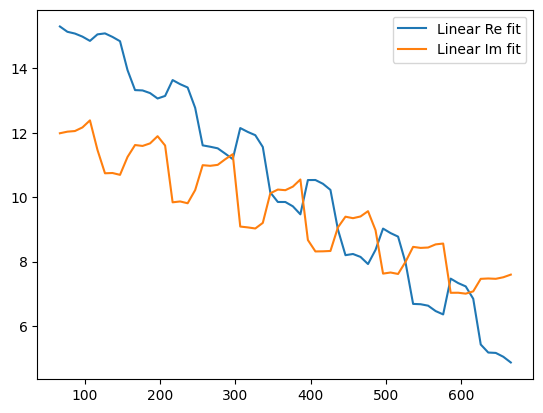

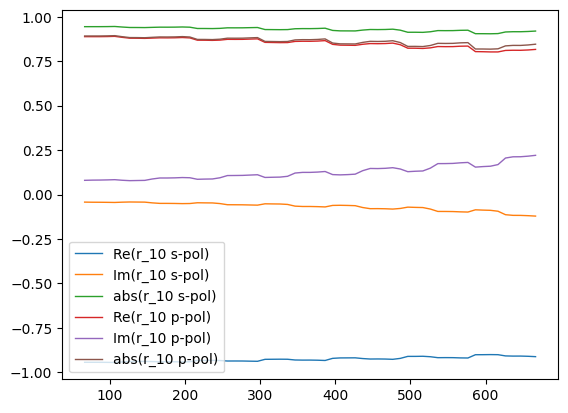

In [60]:
x_linear, n_linear_fit_re, n_linear_fit_im = (n_linear_fit_dict[_name]['wl_begins'], 
                                             n_linear_fit_dict[_name]['fit_ngr_re'],
                                             n_linear_fit_dict[_name]['fit_ngr_im'])
print(x_linear, n_linear_fit_re, n_linear_fit_im)
plt.figure()
plt.plot(x_linear,  n_linear_fit_re, label='Linear Re fit')
plt.plot(x_linear, n_linear_fit_im, label='Linear Im fit')
plt.legend()

n_linear_fit = n_linear_fit_re + 1j * n_linear_fit_im
r10_s_linear = [interface_r('s', 1, n, *list_snell([1, n], pi/4)) for n in n_linear_fit]
logger.debug(np.abs(r10_s_linear))
r10_s_linear_re, r10_s_linear_im = (np.real(r10_s_linear), np.imag(r10_s_linear))
plt.figure()
plt.plot(x_linear, r10_s_linear_re, label = 'Re(r_10 s-pol)', linewidth=1)
plt.plot(x_linear, r10_s_linear_im, label = 'Im(r_10 s-pol)', linewidth=1)
plt.plot(x_linear, np.abs(r10_s_linear), label = 'abs(r_10 s-pol)', linewidth=1)
plt.legend()


r10_p_linear = [interface_r('p', 1, n, *list_snell([1, n], pi/4)) for n in n_linear_fit]
logger.debug(np.abs(r10_p_linear))
r10_p_linear_re, r10_p_linear_im = (np.real(r10_p_linear), np.imag(r10_p_linear))
plt.plot(x_linear, r10_p_linear_re, label = 'Re(r_10 p-pol)', linewidth=1)
plt.plot(x_linear, r10_p_linear_im, label = 'Im(r_10 p-pol)', linewidth=1)
plt.plot(x_linear, np.abs(r10_p_linear), label = 'abs(r_10 p-pol)', linewidth=1)
# Для s-pol колебания сглаживаются, для p - нет


plt.legend()
plt.show()


In [ ]:
help(complex)

## Fit by R+T

In [45]:
def spectral_fitting_by_R_plus_T(optical_dict,
                    name, 
                    fit_mode, 
                    interval, 
                    step, 
                    bounds,
                    start_wl=41,
                    stop_wl=700,
                    output_path=r"C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Fitting results",
                    folder_name = "fitting_epsilon",
                    segmentation_method='fixed',  # or 'inflection'
                    draw_plots=True,   
                    output_curve_fit=None, 
                    savefig=False,  
                    mkm=False, 
                    f=None):
    """
    Fit optical data for different graphene thicknesses. Can be used to fit
    either reflectance or transmittance data, based on the `fit_mode` parameter.
    
    Parameters:
        optical_dict (dict): Dictionary where each key corresponds to a thickness.
                             Each entry is a tuple/list containing:
                                [0] - wavelength array (Pandas Series)
                                [1] - optical data array (reflectance or transmittance)
                                [2] - graphene thickness (float)
        fit_mode (str): 'R' for reflectance fitting or 'T' for transmittance fitting.
        interval (float): Window size for data segmentation.
        step (float): Step size between windows.
        start_wl (float): Start wavelength of the first window.
        segmentation_method (str): 'fixed' or 'inflection'
        draw_plots (bool): If True, plot each segment’s fit and the final fit.
        output_curve_fit: Optional parameter to output the curve fit results.
    
    Returns:
        dict: A dictionary with keys for each thickness containing:
              - eps_x_axis: x-axis values (transformed wavelengths)
              - fit_eps_gr_re: fitted real part of dielectric permittivity
              - fit_eps_gr_im: fitted imaginary part of dielectric permittivity
    """
    assert start_wl>41
    assert fit_mode == 'R+T'
    assert name in optical_dict
    fit_n_dict = {}
    fit_eps_dict = {}

    if savefig:
        # Step 1: Create folder
        os.chdir(output_path)
        fitting_path=os.path.join(output_path, folder_name)
        os.makedirs(fitting_path, exist_ok=True)
        os.chdir(fitting_path)
   
    
    if savefig:
        # Create folder 

        thk_name = f"{name}"
        thk_path=os.path.join(fitting_path, thk_name)
        os.makedirs(thk_path, exist_ok=True)
        os.chdir(thk_path)

    gr_thk = optical_dict[name][2]
    assert 0 <= gr_thk < 1e-5, f"Thickness out of expected range for {name}"
    logger.info(f"gr_thk= {gr_thk:.2e} m")

    # Create the appropriate fitting function based on mode ('R' or 'T')
    
    if gr_thk==0:
        fit_func = create_PP_function(PP_THK, fit_mode)
    
    if gr_thk>0:
        fit_func = create_fit_function(gr_thk, fit_mode) if f is None else f 
    

    
    # Get wavelength and optical data arrays
    wl_arr = optical_dict[name][0]
    opt_arr = optical_dict[name][1]
    logger.debug(f"(wavelength, optical data): {list(zip(wl_arr, opt_arr))}")
    
    perr_arr_re = []
    perr_arr_im = []
    wl_begins = []    # middle points of each segment
    fit_ngr_re = []   # fit parameter: real part
    fit_ngr_im = []   # fit parameter: imaginary part

    # Create segments based on chosen method
    if segmentation_method == 'fixed':
        if start_wl <= 40:
            raise ValueError("start_wl must be greater than 40")
        if stop_wl > 700:
            raise ValueError("start_wl must be greater than 40")
        start_point = int(start_wl) - 40
        stop_point=int(stop_wl)-40
        wl_segments = make_2d_windows_vectorized(wl_arr[start_point:stop_point], interval, step)
        optical_segments = make_2d_windows_vectorized(opt_arr[start_point:stop_point], interval, step)
    elif segmentation_method == 'inflection':
        logger.error("Inflection segmentation method is not yet implemented.")
        wl_segments = wl_arr  # fallback: use entire array
        optical_segments = opt_arr
    else:
        raise ValueError("Invalid segmentation method.")

    # Fit each segment
    for x_data, y_data in zip(wl_segments, optical_segments):
        try:
            kwargs = {'maxfev': 100000}
            p0 = None if not fit_ngr_re else (fit_ngr_re[-1], fit_ngr_im[-1])
            popt, pcov = curve_fit(fit_func, x_data, y_data, p0=p0, bounds=bounds,
                                    **kwargs)
        except RuntimeError as e:
            logger.error(f"Fitting failed for segment at wavelength center {0.5*(x_data[0]+x_data[-1])}")
            raise e

        


        """

        # Check asymptotics and erase bad points
        if fit_mode == 'R' and np.all(fit_func(np.array(wl_arr[:10]), popt[0], popt[1])  > 0.5):
            continue

        if fit_mode == 'T' and np.all(fit_func(np.array(wl_arr[:10]), popt[0], popt[1])  < 0.5):
            continue
            
        """

        perr = np.sqrt(np.diag(pcov))
        wl_bgn = 0.5 * (x_data[0] + x_data[-1])
        logger.debug(f"Segment: wavelength range {x_data[0]:.1f} to {x_data[-1]:.1f}")
        logger.info(f"popt= {popt}, perr= {perr}, wl_begin = {wl_bgn}")
        perr_arr_re.append(perr[0])
        perr_arr_im.append(perr[1])
        wl_begins.append(wl_bgn)
        fit_ngr_re.append(popt[0])
        fit_ngr_im.append(popt[1])

        # Plot each segment's fit if requested
        if draw_plots:
            if not np.all([x_data, y_data]):
                logger.error("Empty data for plotting")
            else:
                plt.figure(figsize=(10, 6))
                plt.plot(wl_arr, fit_func(wl_arr, popt[0], popt[1]), 'r-', label='Fitted curve')
                plt.plot(wl_arr, opt_arr, 'bo', label='Data points')
                plt.axvline(wl_bgn - interval/2)
                plt.axvline(wl_bgn + interval/2)
                plt.xlabel('Wavelength (cm-1)')
                ylabel = str(fit_mode)
                plt.ylabel(ylabel)
                plt.title(f'Fit for {name} segment starting at {wl_bgn:.0f} cm-1')
                plt.legend()
                plt.grid(True)

                # Save plots 
                if savefig:
                    plt.savefig(f"{name}{wl_bgn}.png", dpi=300)
                plt.show()

    # Transform lists to numpy arrays for further processing
    wl_begins = np.array(wl_begins)
    fit_ngr_re = np.array(fit_ngr_re)
    fit_ngr_im = np.array(fit_ngr_im)
    logger.debug(f"wl_begins = {wl_begins}")

    # Convert wavelengths and computed parameters into dielectric permittivity components
    eps_x_axis = 1e4 / wl_begins
    fit_eps_gr_re = fit_ngr_re**2 - fit_ngr_im**2
    fit_eps_gr_im = 2 * fit_ngr_re * fit_ngr_im
    logger.debug(f"eps_x_axis = {eps_x_axis}")

    # Save the n and epsilon results for this thickness
    fit_eps_dict[name] = {"eps_x_axis": eps_x_axis, 
                            "fit_eps_gr_re": fit_eps_gr_re, 
                            "fit_eps_gr_im": fit_eps_gr_im}
    fit_n_dict[name] = {"wl_begins": wl_begins, 
                        "fit_ngr_re": fit_ngr_re, 
                        "fit_ngr_im": fit_ngr_im}



    # Plot dielectric permittivity components vs mkm
    plt.figure(figsize=(12, 6))
    plt.scatter(eps_x_axis, fit_eps_gr_re, color='red', label='Real part of epsilon', marker='o')
    plt.scatter(eps_x_axis, fit_eps_gr_im, color='blue', label='Imaginary part of epsilon')
    plt.xlabel('Wavelength (mkm)')
    plt.ylabel('Dielectric permittivity')
    plt.title(f'Fitted dielectric permittivity components of gr (or PP) vs mkm for {name} by {fit_mode}')
    plt.legend()
    plt.grid(True)

    # Plot dielectric permittivity components vs cm-1
    plt.figure(figsize=(12, 6))
    plt.scatter(wl_begins, fit_eps_gr_re, color='red', label='Real part of epsilon', marker='o')
    plt.scatter(wl_begins, fit_eps_gr_im, color='blue', label='Imaginary part of epsilon')
    plt.xlabel('Wavelength (cm-1)')
    plt.ylabel('Dielectric permittivity')
    plt.title(f'Fitted dielectric permittivity components of gr (or PP) vs cm-1 for {name} by {fit_mode}')
    plt.legend()
    plt.grid(True)

    # Plot n conponents
    plt.figure(figsize=(12, 6))
    plt.errorbar(wl_begins, fit_ngr_re, yerr=perr_arr_re, color='red', label='Real part of n', marker='o')
    plt.errorbar(wl_begins, fit_ngr_im, yerr=perr_arr_im, color='blue', label='Imaginary part of n')
    plt.xlabel('Wavelength (cm-1)')
    plt.ylabel('Re n and Im n')
    plt.title(f'Fitted n components of gr (or PP) for {name} by {fit_mode}')
    plt.legend()
    plt.grid(True)

    # Save epsilon plot
    if savefig:
        plt.savefig(f"{fit_mode}{name}.png", dpi=300)  
        os.chdir(fitting_path)
    plt.show() 
    if savefig:
        os.chdir(output_path)
    return fit_n_dict, fit_eps_dict



INFO - gr_thk= 7.00e-08 m
DEBUG - (wavelength, optical data): [(39.5437292255, 0.9137668312), (40.5082104261, 0.9124313891), (41.4726916268, 0.89702335), (42.4371728274, 0.8772282004), (43.401654028, 0.8612912893), (44.3661352286, 0.8531665802), (45.3306164293, 0.854947865), (46.2950976299, 0.8671327829), (47.2595788305, 0.8858960569000001), (48.2240600311, 0.9034159183000001), (49.1885412317, 0.9106563032), (50.1530224324, 0.9040779472), (51.117503633, 0.8879234492999999), (52.0819848336, 0.8698363007000001), (53.0464660342, 0.8551295399), (54.0109472349, 0.8449294567000001), (54.9754284355, 0.8377528191000001), (55.9399096361, 0.8314120174), (56.9043908367, 0.8239240945), (57.8688720373, 0.8141491711), (58.833353238, 0.8024134636), (59.7978344386, 0.7902639807), (60.7623156392, 0.7792076766), (61.7267968398, 0.7695764303), (62.6912780405, 0.7604510784), (63.6557592411, 0.7507858873), (64.6202404417, 0.7399871349), (65.5847216423, 0.7281765342), (66.5492028429, 0.7161195278), (67.5136

7e-08 7e-08


DEBUG - Segment: wavelength range 41.5 to 146.6
INFO - popt= [18.53511412  5.5738117 ], perr= [0.48652816 0.08779089], wl_begin = 94.0369170607


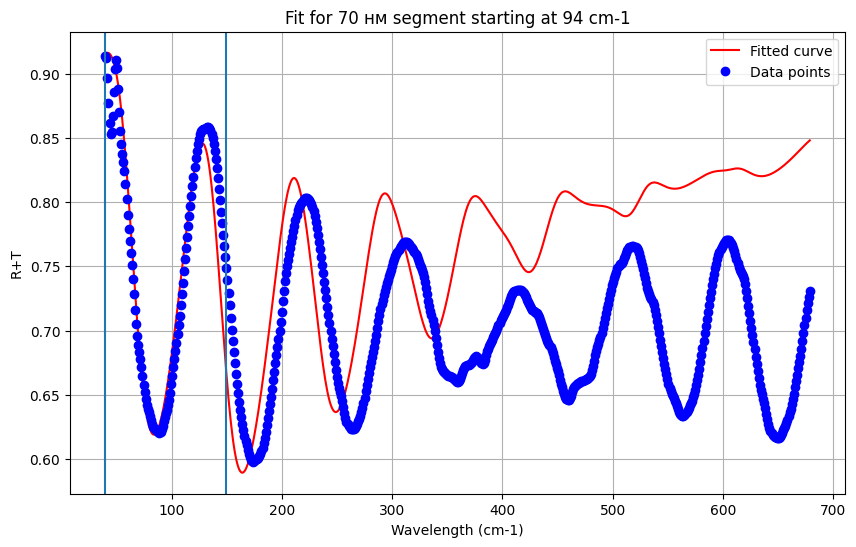

DEBUG - Segment: wavelength range 60.8 to 165.9
INFO - popt= [20.53175051  5.37426666], perr= [0.50480408 0.12972753], wl_begin = 113.32654107315


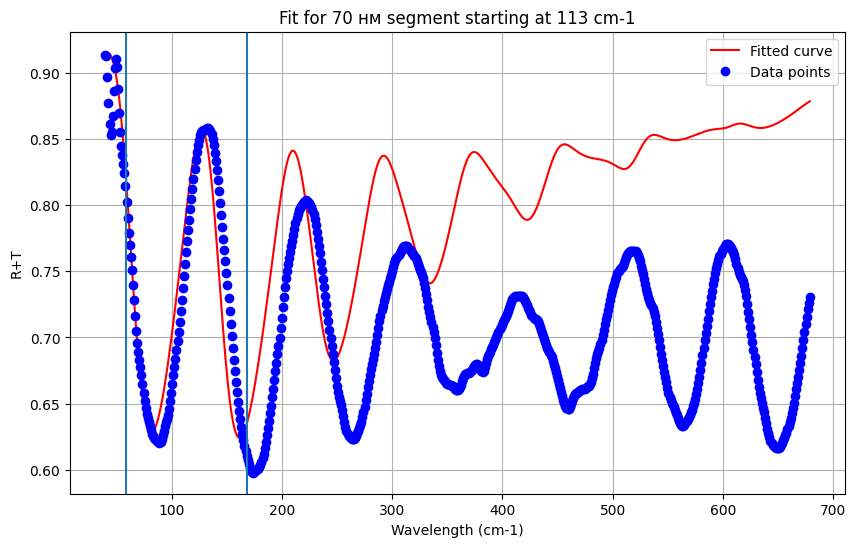

DEBUG - Segment: wavelength range 80.1 to 185.2
INFO - popt= [11.74815393  5.390955  ], perr= [0.39355294 0.15110673], wl_begin = 132.61616508560002


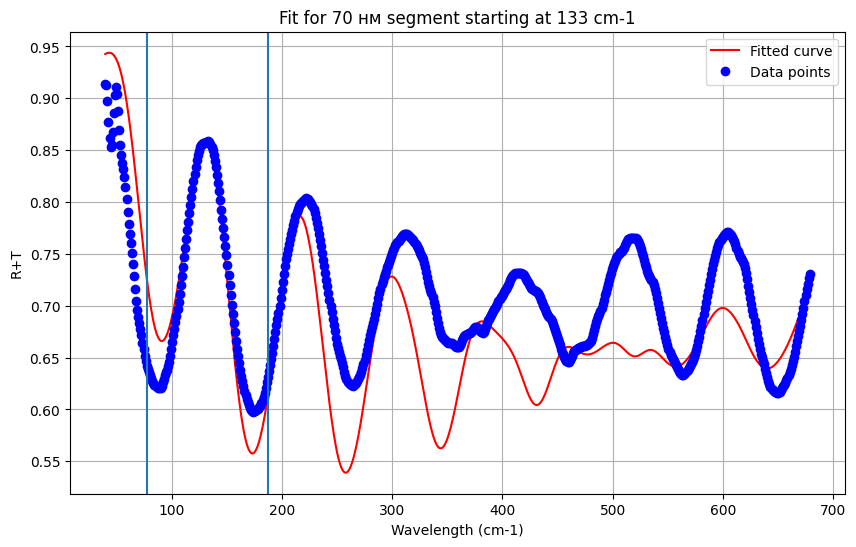

DEBUG - Segment: wavelength range 99.3 to 204.5
INFO - popt= [10.47416204  5.31653361], perr= [0.16440074 0.0689506 ], wl_begin = 151.90578909804998


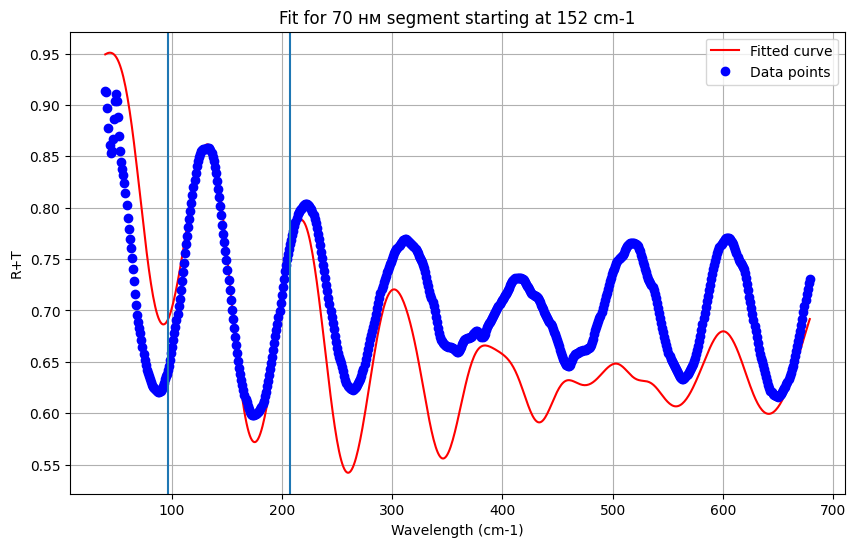

DEBUG - Segment: wavelength range 118.6 to 223.8
INFO - popt= [10.54083454  5.1152682 ], perr= [0.10893877 0.03908318], wl_begin = 171.1954131105


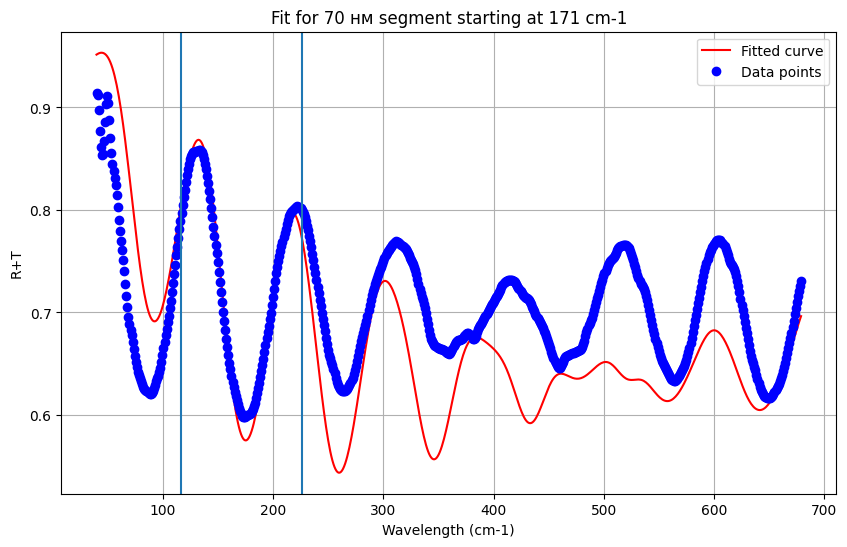

DEBUG - Segment: wavelength range 137.9 to 243.0
INFO - popt= [9.89786221 4.99012027], perr= [0.17949637 0.07898205], wl_begin = 190.48503712295002


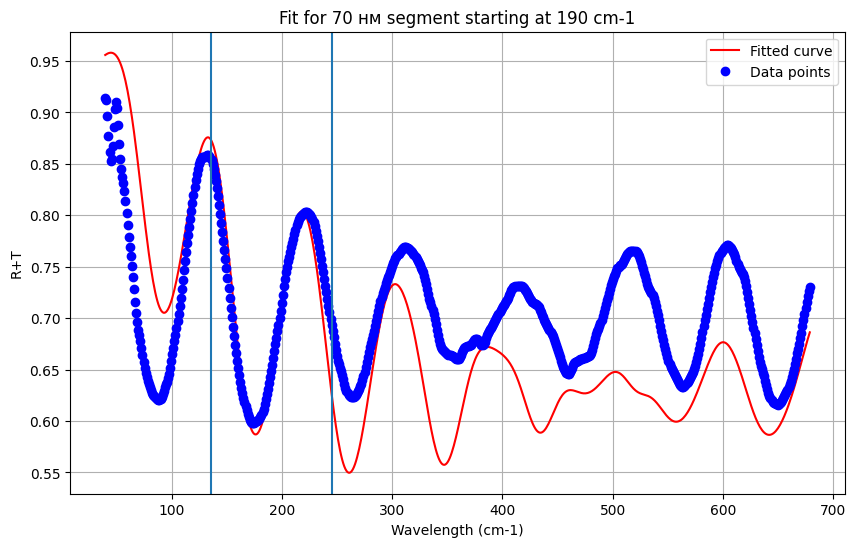

DEBUG - Segment: wavelength range 157.2 to 262.3
INFO - popt= [8.39123797 5.09567579], perr= [0.16667208 0.11199617], wl_begin = 209.77466113539998


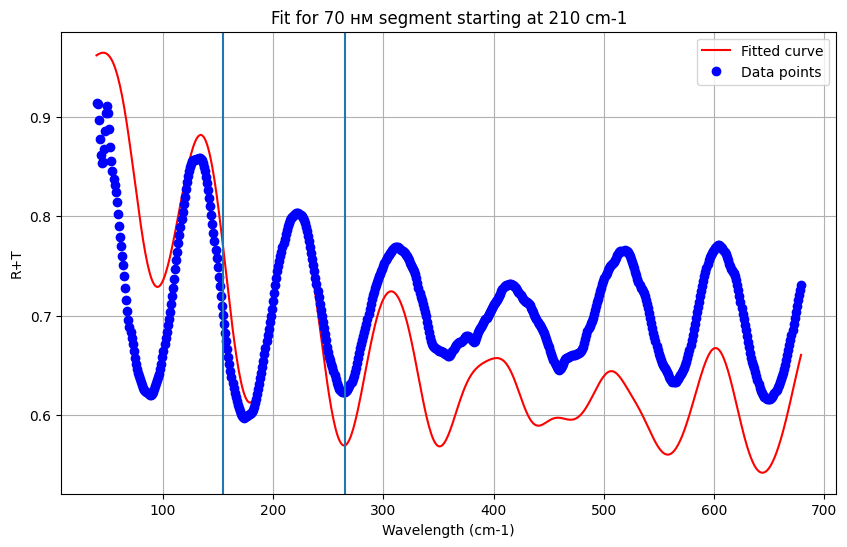

DEBUG - Segment: wavelength range 176.5 to 281.6
INFO - popt= [7.23619282 5.17373319], perr= [0.12145936 0.09200658], wl_begin = 229.06428514785


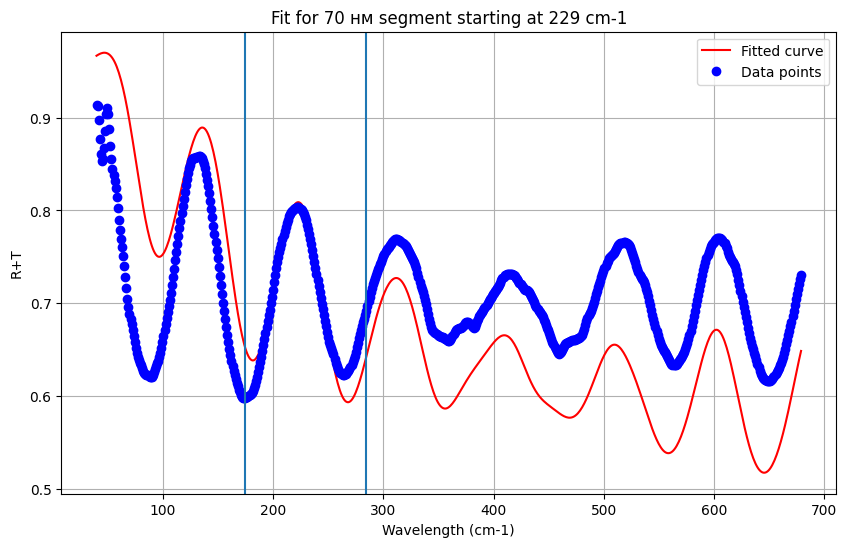

DEBUG - Segment: wavelength range 195.8 to 300.9
INFO - popt= [7.52993269 4.71043439], perr= [0.12806273 0.06949788], wl_begin = 248.35390916030002


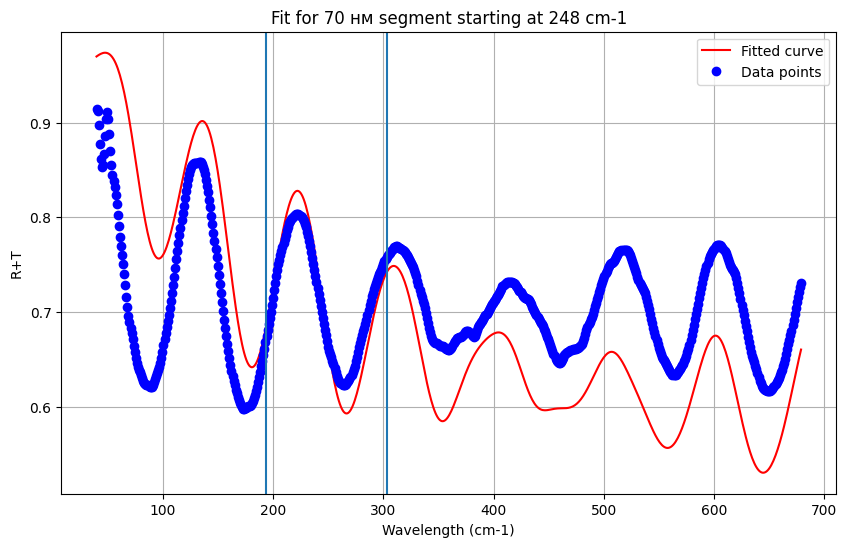

DEBUG - Segment: wavelength range 215.1 to 320.2
INFO - popt= [7.67351513 4.48694149], perr= [0.12924168 0.06303079], wl_begin = 267.64353317275


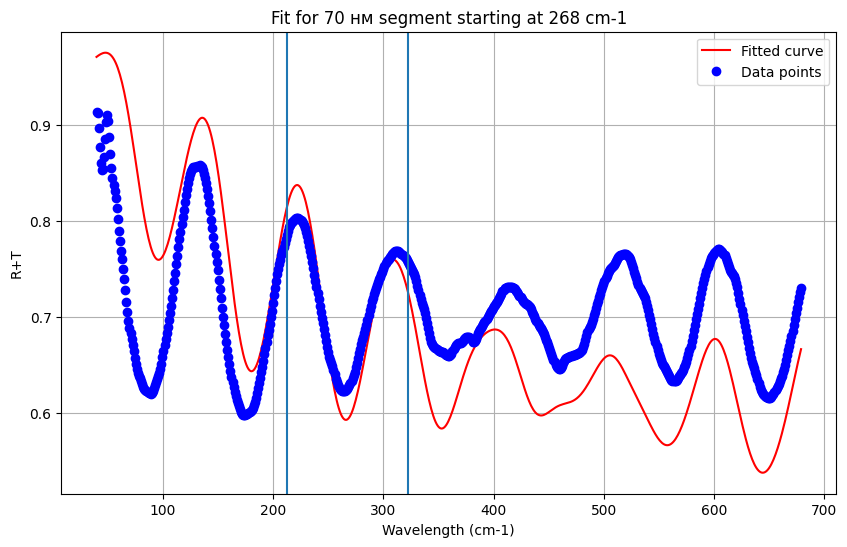

DEBUG - Segment: wavelength range 234.4 to 339.5
INFO - popt= [7.17672023 4.30222394], perr= [0.112756 0.07296 ], wl_begin = 286.9331571852


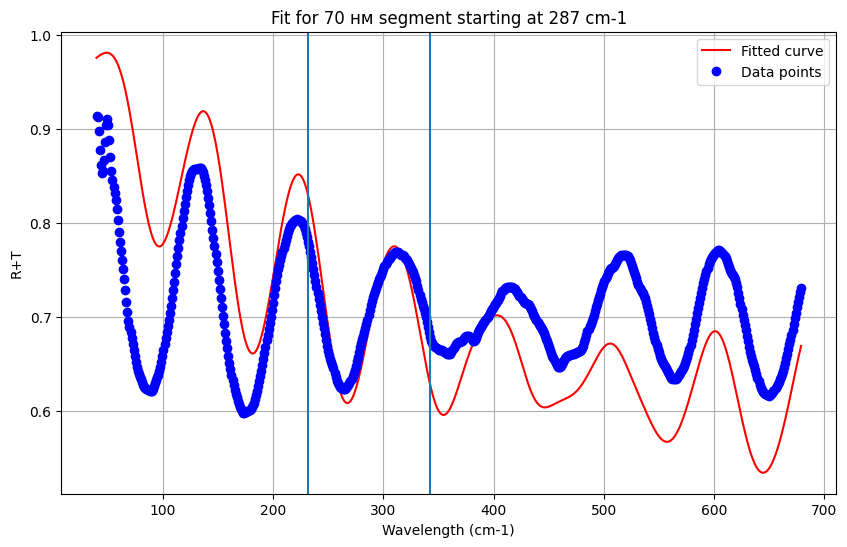

DEBUG - Segment: wavelength range 253.7 to 358.8
INFO - popt= [6.21675319 4.39431839], perr= [0.08359618 0.06879354], wl_begin = 306.22278119764997


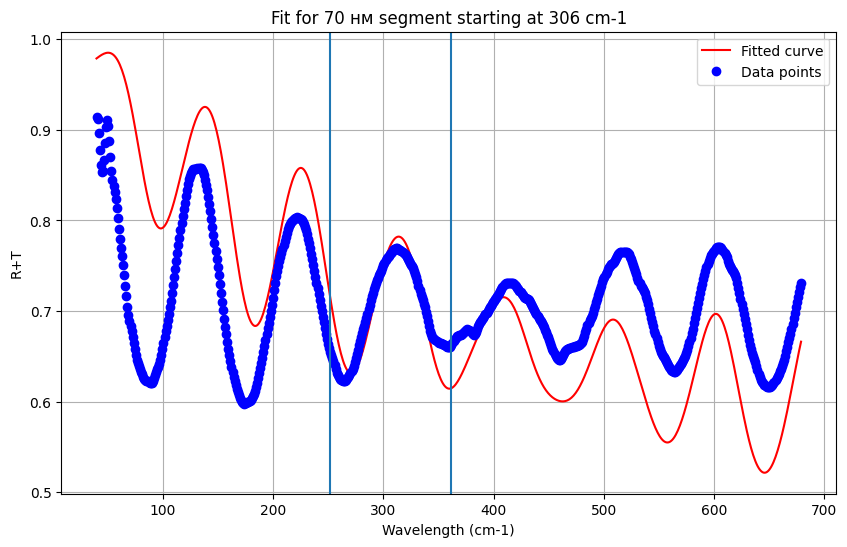

DEBUG - Segment: wavelength range 272.9 to 378.1
INFO - popt= [5.89028441 4.3006652 ], perr= [0.09985522 0.0701142 ], wl_begin = 325.5124052101


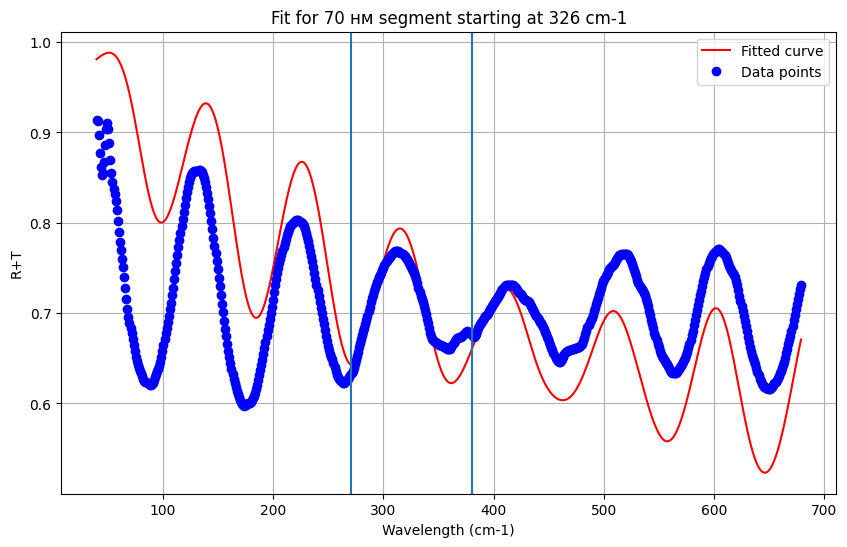

DEBUG - Segment: wavelength range 292.2 to 397.4
INFO - popt= [5.9028127  4.32060801], perr= [0.09451872 0.05713261], wl_begin = 344.80202922255


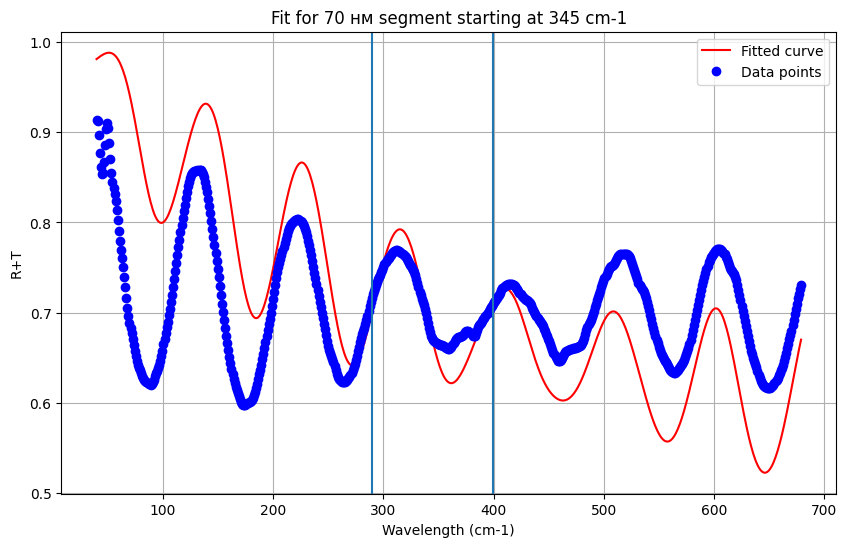

DEBUG - Segment: wavelength range 311.5 to 416.7
INFO - popt= [5.91882065 4.27698567], perr= [0.09337015 0.06294581], wl_begin = 364.09165323499997


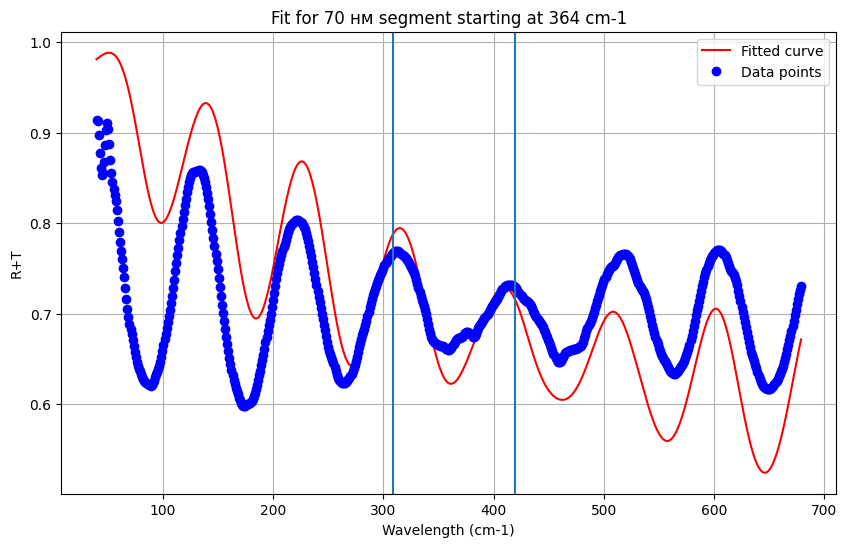

DEBUG - Segment: wavelength range 330.8 to 435.9
INFO - popt= [5.59931925 4.22497137], perr= [0.07265421 0.06254998], wl_begin = 383.38127724745


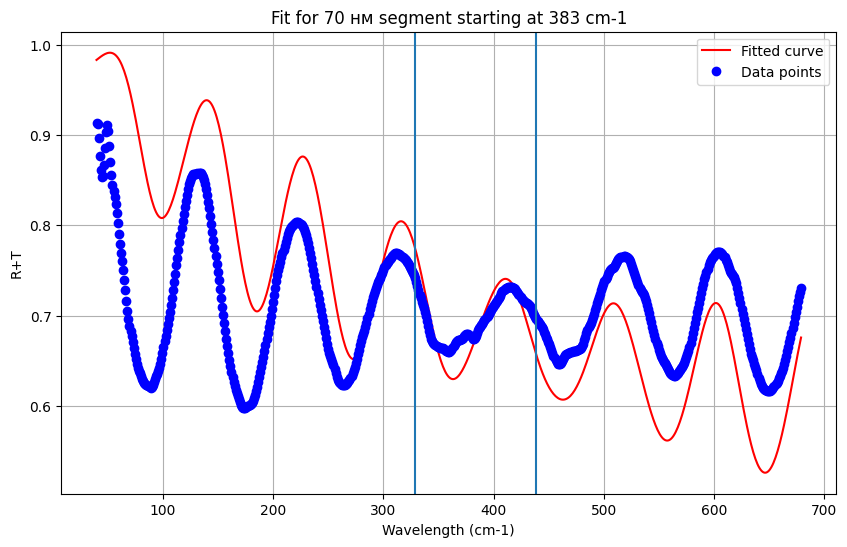

DEBUG - Segment: wavelength range 350.1 to 455.2
INFO - popt= [5.02038962 4.37061445], perr= [0.08004587 0.07288623], wl_begin = 402.6709012599


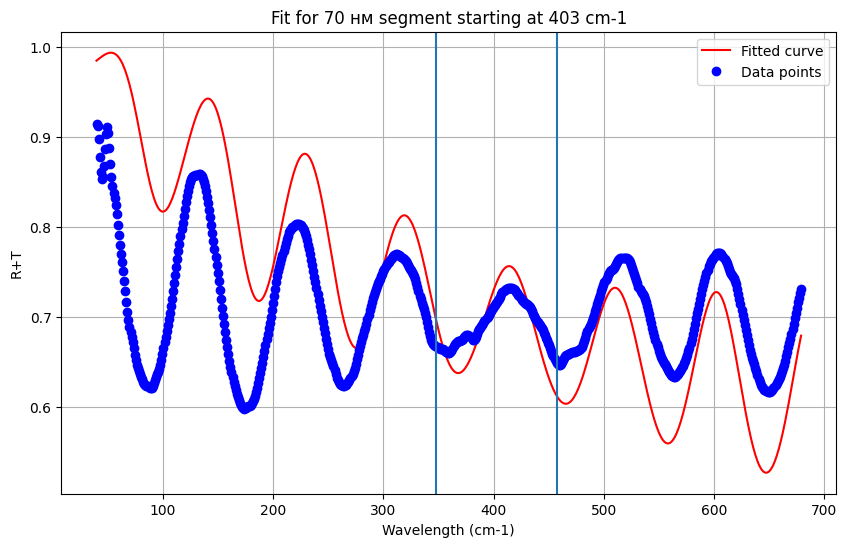

DEBUG - Segment: wavelength range 369.4 to 474.5
INFO - popt= [5.29565899 4.05261641], perr= [0.11117519 0.06986857], wl_begin = 421.96052527234997


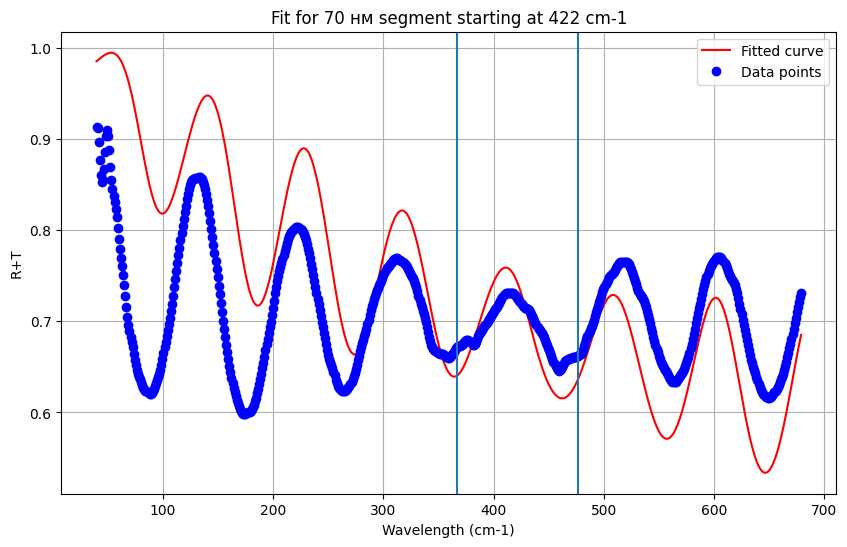

DEBUG - Segment: wavelength range 388.7 to 493.8
INFO - popt= [5.35583677 3.9570208 ], perr= [0.11434652 0.06790834], wl_begin = 441.2501492848


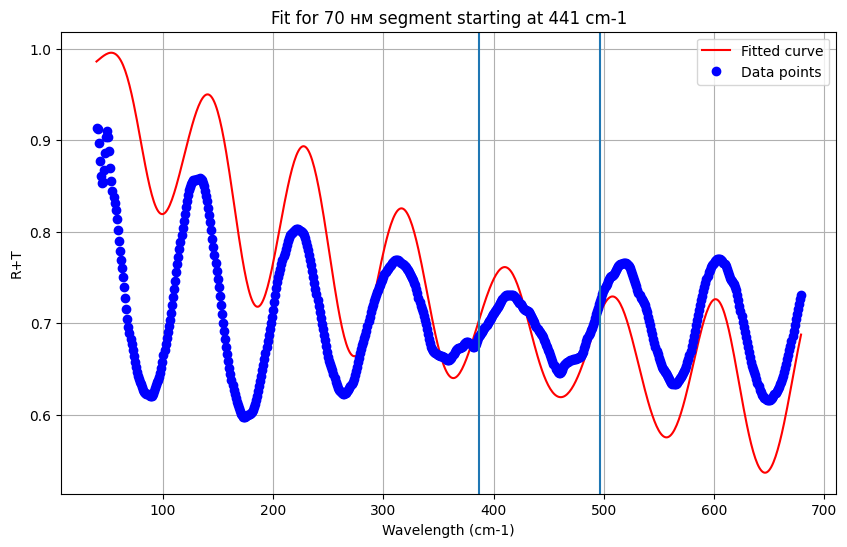

DEBUG - Segment: wavelength range 408.0 to 513.1
INFO - popt= [5.37167912 3.66337983], perr= [0.08660416 0.05852918], wl_begin = 460.53977329725


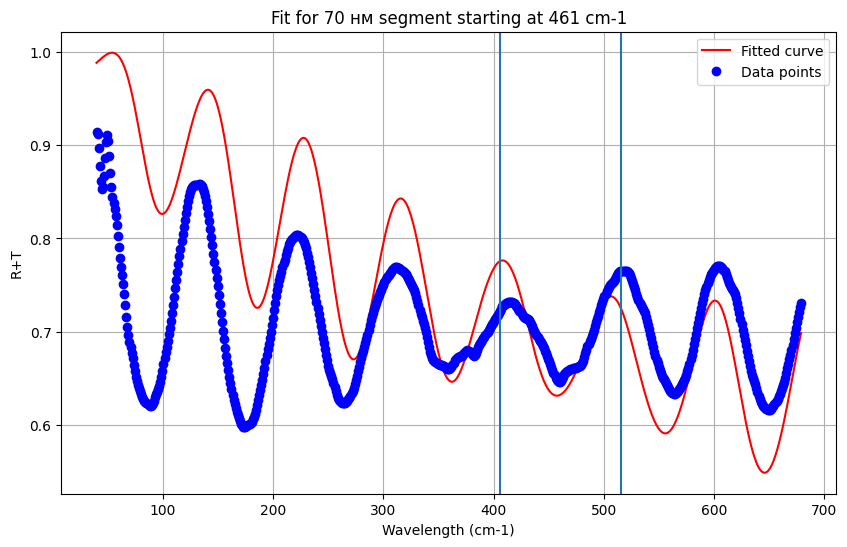

DEBUG - Segment: wavelength range 427.3 to 532.4
INFO - popt= [4.59687004 3.8008422 ], perr= [0.07345704 0.06466892], wl_begin = 479.82939730975


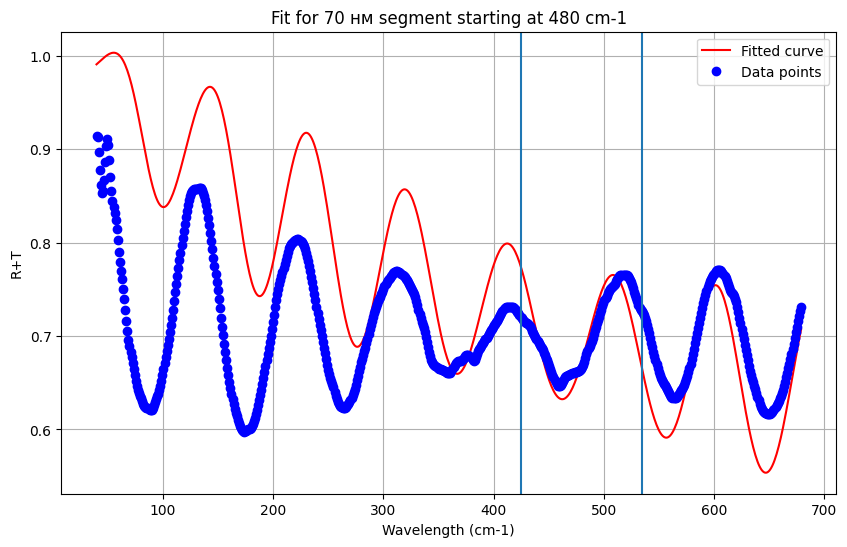

DEBUG - Segment: wavelength range 446.6 to 551.7
INFO - popt= [3.97135556 3.97948928], perr= [0.11298514 0.10706753], wl_begin = 499.11902132214993


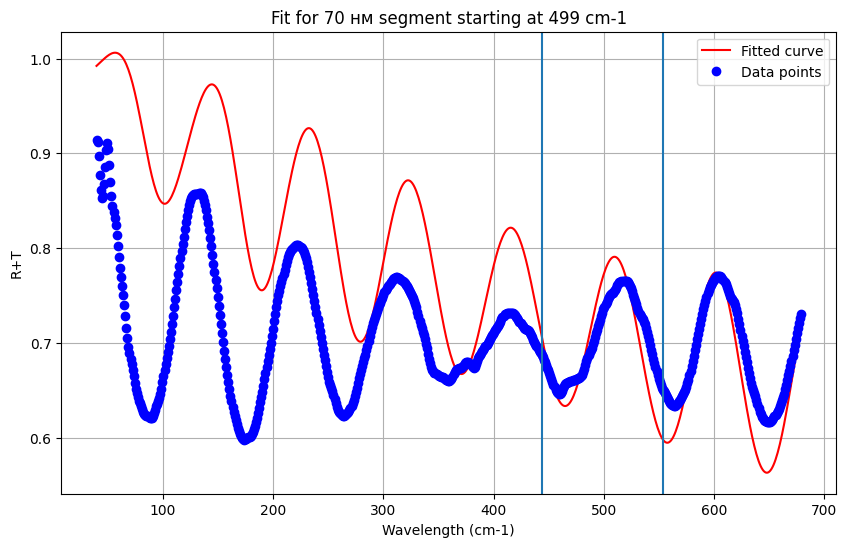

DEBUG - Segment: wavelength range 465.8 to 571.0
INFO - popt= [4.11086795 3.73607814], perr= [0.13452555 0.10023151], wl_begin = 518.40864533465


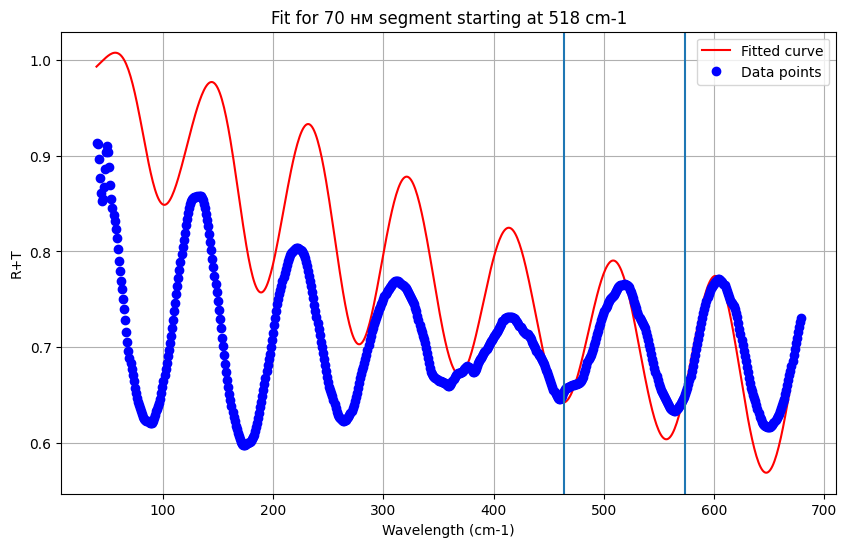

DEBUG - Segment: wavelength range 485.1 to 590.3
INFO - popt= [4.19716756 3.69015116], perr= [0.14761445 0.11817683], wl_begin = 537.69826934705


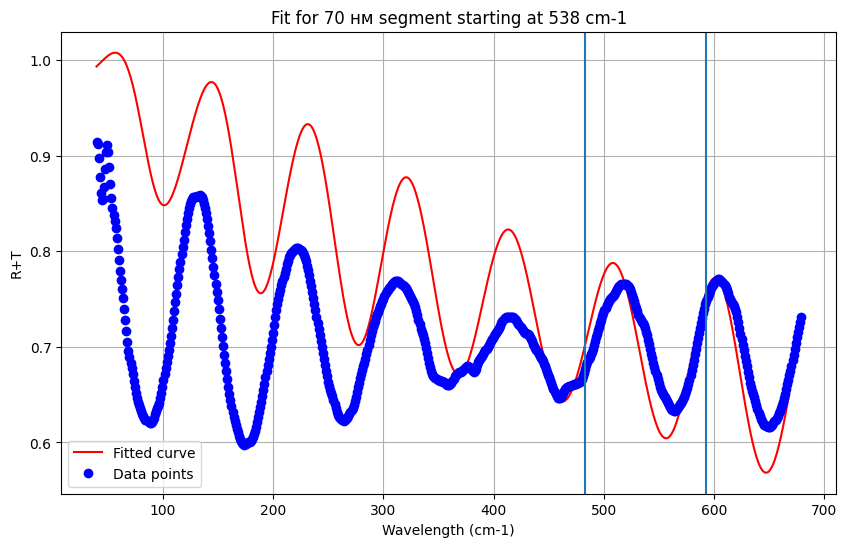

DEBUG - Segment: wavelength range 504.4 to 609.6
INFO - popt= [4.33691357 3.37278918], perr= [0.12073317 0.09364602], wl_begin = 556.98789335955


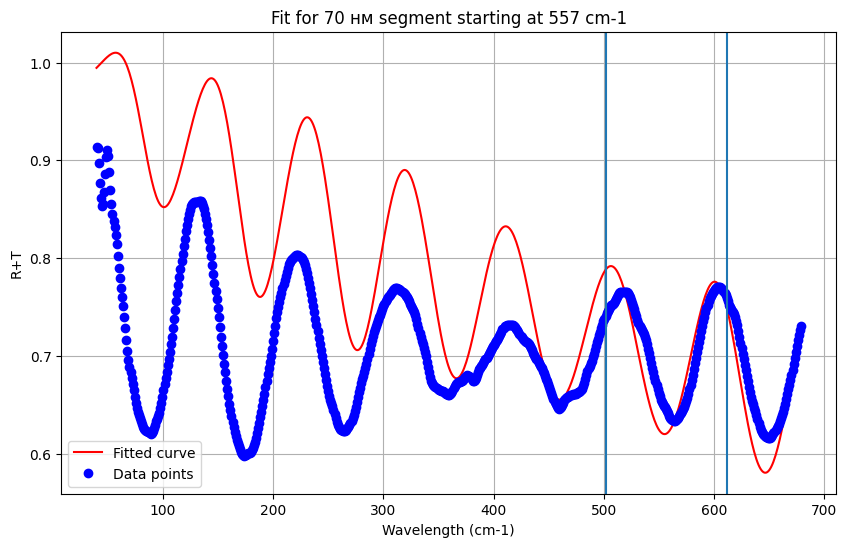

DEBUG - Segment: wavelength range 523.7 to 628.8
INFO - popt= [3.61016832 3.80098064], perr= [0.10779706 0.11583655], wl_begin = 576.27751737195


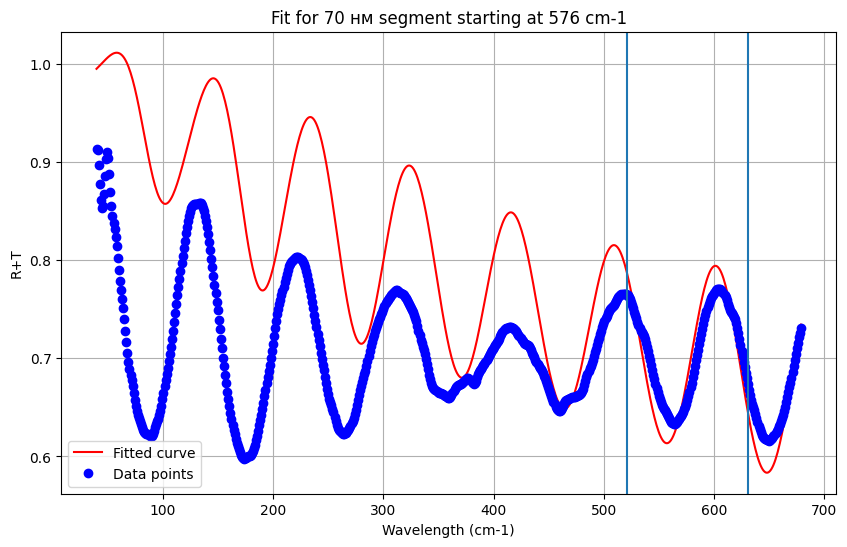

DEBUG - Segment: wavelength range 543.0 to 648.1
INFO - popt= [3.62763691 3.68509616], perr= [0.1445049  0.13681893], wl_begin = 595.56714138445


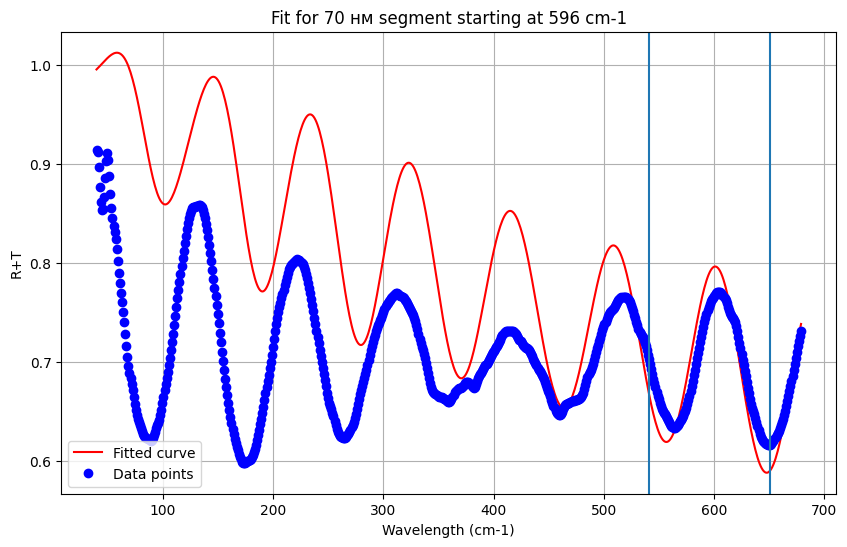

DEBUG - Segment: wavelength range 562.3 to 667.4
INFO - popt= [3.56085617 3.79083434], perr= [0.13404297 0.13471844], wl_begin = 614.8567653969


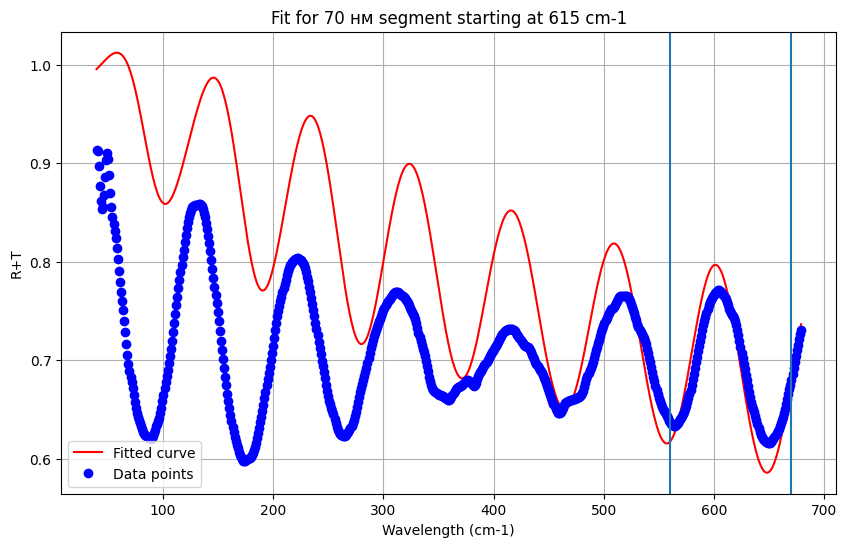

DEBUG - wl_begins = [ 94.03691706 113.32654107 132.61616509 151.9057891  171.19541311
 190.48503712 209.77466114 229.06428515 248.35390916 267.64353317
 286.93315719 306.2227812  325.51240521 344.80202922 364.09165323
 383.38127725 402.67090126 421.96052527 441.25014928 460.5397733
 479.82939731 499.11902132 518.40864533 537.69826935 556.98789336
 576.27751737 595.56714138 614.8567654 ]
DEBUG - eps_x_axis = [106.34121484  88.24058253  75.4055887   65.83027585  58.41277998
  52.49756176  47.67019976  43.65586714  40.26512018  37.36312954
  34.85132251  32.65596361  30.7207954   29.0021495   27.46561178
  26.08369421  24.83417592  23.69889931  22.66288185  21.7136512
  20.8407406   20.03530135  19.28980176  18.59779094  17.9537116
  17.35275054  16.79071813  16.2639505 ]


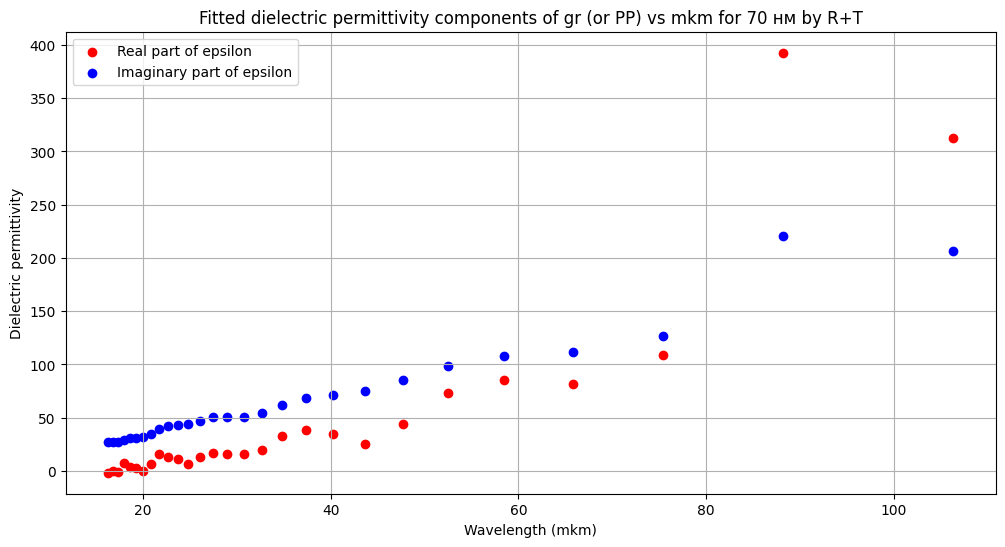

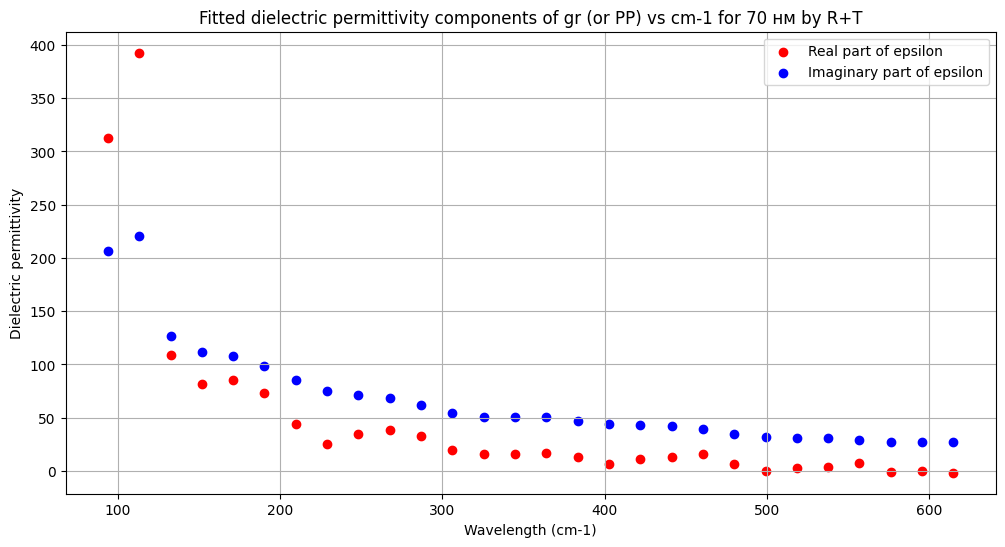

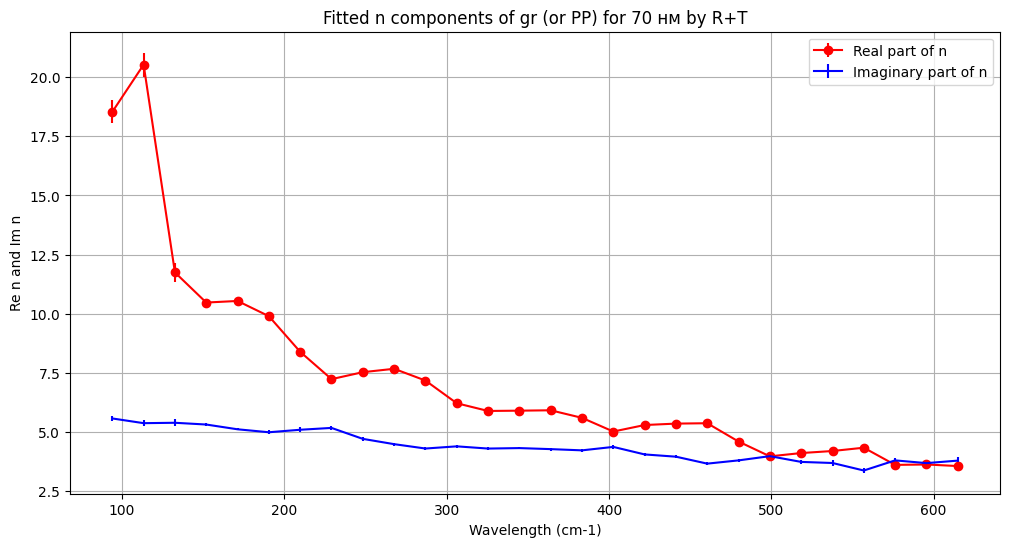

({'70 нм': {'wl_begins': array([ 94.03691706, 113.32654107, 132.61616509, 151.9057891 ,
       171.19541311, 190.48503712, 209.77466114, 229.06428515,
       248.35390916, 267.64353317, 286.93315719, 306.2227812 ,
       325.51240521, 344.80202922, 364.09165323, 383.38127725,
       402.67090126, 421.96052527, 441.25014928, 460.5397733 ,
       479.82939731, 499.11902132, 518.40864533, 537.69826935,
       556.98789336, 576.27751737, 595.56714138, 614.8567654 ]), 'fit_ngr_re': array([18.53511412, 20.53175051, 11.74815393, 10.47416204, 10.54083454,
        9.89786221,  8.39123797,  7.23619282,  7.52993269,  7.67351513,
        7.17672023,  6.21675319,  5.89028441,  5.9028127 ,  5.91882065,
        5.59931925,  5.02038962,  5.29565899,  5.35583677,  5.37167912,
        4.59687004,  3.97135556,  4.11086795,  4.19716756,  4.33691357,
        3.61016832,  3.62763691,  3.56085617]), 'fit_ngr_im': array([5.5738117 , 5.37426666, 5.390955  , 5.31653361, 5.1152682 ,
       4.99012027, 5.09567579

In [54]:
assert np.all(abs(transmit_dict['70 нм'][0] - reflect_dict['70 нм'][0])<1e-2)
RT_70_spectrum = transmit_dict['70 нм'][1] + reflect_dict['70 нм'][1]
RT_70_wls = transmit_dict['70 нм'][0]
#print(RT_70_spectrum)
print(transmit_dict['70 нм'][2], reflect_dict['70 нм'][2])
RT_70_dict = {'70 нм': (RT_70_wls, RT_70_spectrum, transmit_dict['70 нм'][2])}
print(spectral_fitting_by_R_plus_T(RT_70_dict, '70 нм', 'R+T', 110, 20, [(-inf, -inf),(inf, inf)], 42, 
                       output_path=None,
                       folder_name="Printed graphene transmission", draw_plots=True,  
))

# Fouier analysis

In [ ]:
# List all keys from reflect_dict
names = list(reflect_dict.keys())
n = len(names)

# Create a figure with n subplots (one per dataset) for the original & reconstructed functions.
fig1, axes1 = plt.subplots(n, 1, figsize=(8, 4*n), squeeze=False)

# Create another figure with n subplots for the magnitude spectrum.
fig2, axes2 = plt.subplots(n, 1, figsize=(8, 4*n), squeeze=False)

for i, name in enumerate(names):
    # Slice the data as needed
    _x_refer = reflect_dict[name][0][50:]
    _refer = reflect_dict[name][1][50:]
    
    # Compute the Fourier transform using FFT
    Y = np.fft.fft(_refer)
    
    # Compute corresponding frequencies
    freq = np.fft.fftfreq(len(_refer), d=(_x_refer[1] - _x_refer[0]))
    print(f"Length of frequency array for {name}: {len(freq)}")
    
    # Inverse FFT to reconstruct the original function
    y_reconstructed = np.fft.ifft(Y)
    
    # Plot original and reconstructed function in the i-th subplot of fig1
    ax1 = axes1[i, 0]
    ax1.plot(_x_refer, _refer, 'b.-', label='Original function')
    ax1.plot(_x_refer, y_reconstructed.real, 'r--', label='Reconstructed function')
    ax1.set_xlabel('_x_refer')
    ax1.set_ylabel('f(_x_refer)')
    ax1.legend()
    ax1.set_title(f'FFT and Inverse FFT for {name}')
    
    # Plot the magnitude spectrum in the i-th subplot of fig2
    ax2 = axes2[i, 0]
    ax2.scatter(freq, np.abs(Y))
    ax2.set_xlim(-0.05, 0.05)
    ax2.set_ylim(0, 15)
    ax2.set_xlabel('Frequency')
    ax2.set_ylabel('Magnitude')
    ax2.set_title(f'Magnitude Spectrum of FFT for {name}')

# Adjust layout and display both figures
fig1.tight_layout()
fig2.tight_layout()
plt.show()


In [ ]:
# List all keys from transmit_dict
names = list(transmit_dict.keys())
n = len(names)

# Create a figure with n subplots (one per dataset) for the original & reconstructed functions.
fig1, axes1 = plt.subplots(n, 1, figsize=(8, 4*n), squeeze=False)

# Create another figure with n subplots for the magnitude spectrum.
fig2, axes2 = plt.subplots(n, 1, figsize=(8, 4*n), squeeze=False)

for i, name in enumerate(names):
    # Slice the data as needed
    _x_refer = transmit_dict[name][0][50:]
    _refer = transmit_dict[name][1][50:]
    
    # Compute the Fourier transform using FFT
    Y = np.fft.fft(_refer)
    
    # Compute corresponding frequencies
    freq = np.fft.fftfreq(len(_refer), d=(_x_refer[1] - _x_refer[0]))
    print(f"Length of frequency array for {name}: {len(freq)}")
    
    # Inverse FFT to reconstruct the original function
    y_reconstructed = np.fft.ifft(Y)
    
    # Plot original and reconstructed function in the i-th subplot of fig1
    ax1 = axes1[i, 0]
    ax1.plot(_x_refer, _refer, 'b.-', label='Original function')
    ax1.plot(_x_refer, y_reconstructed.real, 'r--', label='Reconstructed function')
    ax1.set_xlabel('_x_refer')
    ax1.set_ylabel('f(_x_refer)')
    ax1.legend()
    ax1.set_title(f'FFT and Inverse FFT for {name}')
    
    # Plot the magnitude spectrum in the i-th subplot of fig2
    ax2 = axes2[i, 0]
    ax2.scatter(freq, np.abs(Y))
    ax2.set_xlim(-0.05, 0.05)
    ax2.set_ylim(0, 15)
    ax2.set_xlabel('Frequency')
    ax2.set_ylabel('Magnitude')
    ax2.set_title(f'Magnitude Spectrum of FFT for {name}')

# Adjust layout and display both figures
fig1.tight_layout()
fig2.tight_layout()
plt.show()


In [ ]:
_refer = reflect_dict['105nm'][1][50:]
_x_refer = reflect_dict['105nm'][0][50:]
# Compute the Fourier transform using FFT
Y = np.fft.fft(_refer)

# Compute corresponding frequencies
freq = np.fft.fftfreq(len(_refer), d=(_x_refer[1] - _x_refer[0]))

# Inverse FFT to reconstruct the original function (should match _refer)
y_reconstructed = np.fft.ifft(Y)


if False:
    # Plot original and reconstructed function
    plt.figure(figsize=(8, 4))
    plt.plot(_x_refer, _refer, 'b.-', label='Original function')
    plt.plot(_x_refer, y_reconstructed.real, 'r--', label='Reconstructed function')
    plt.xlabel('_x_refer')
    plt.ylabel('f(_x_refer)')
    plt.legend()
    plt.title('FFT and Inverse FFT (Periodic Extension)')
    plt.show()

# Figure 2: Plot the magnitude spectrum of the Fourier transform
plt.figure(figsize=(8, 4))
plt.plot(freq, np.abs(Y))
plt.xlim(-0.05, 0.05)
plt.ylim(0, 15)
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.title('Magnitude Spectrum of Fourier Transform')
plt.show()

# Kramers-Kronig.

$\epsilon_1(\omega) = 1 + \frac{2}{\pi} \, \mathcal{P} \int_0^\infty \frac{\omega' \, \epsilon_2(\omega')}{\omega'^2 - \omega^2}\, d\omega'$

$\epsilon_2(\omega) = -\frac{2\omega}{\pi}\, \mathcal{P}\int_{0}^{\infty} \frac{\epsilon_1(\omega') - \epsilon_\infty}{\omega'^2-\omega^2} \,d\omega'$

## KK transform function ans its testing

In [ ]:


def omega_from_wl(wl):
    """
    Parameters
      wl: cm-1

    Returns:
      omega: np.array [rad*s-1] 
    """
    wl = np.asarray(wl)
    c = 3e10 # in cm
    omega = 2*pi*c*wl
    logger.debug(f"omega={omega}")
    return omega

def kramers_kronig_transform(omega, eps_imag, eps_inf, threshold):
    """
    Compute the real part of dielectric permittivity from the imaginary part
    using the Kramers–Kronig relation:
    
        epsilon_real(omega) = 1 + (2/π) P ∫_0^∞ [omega' * epsilon_imag(omega')] / (omega'^2 - omega^2) d(omega')
    
    Parameters:
        omega   : 1D numpy array of frequencies (should be positive and uniformly spaced)
        eps_imag: 1D numpy array of imaginary dielectric permittivity values corresponding to omega
        
    Returns:
        eps_real: 1D numpy array of real dielectric permittivity values.
    """
    # Ensure inputs are numpy arrays
    assert isinstance(omega, np.ndarray)
    assert isinstance(eps_imag, np.ndarray)
    
    # Create a 2D grid for the integration
    O1, O2 = np.meshgrid(omega, omega, indexing='ij')
    
    # Calculate denominator and avoid the singularity where omega' = omega.
    denominator = O2**2 - O1**2
    # Use a small threshold to avoid division by numbers close to zero
    integrand = np.where(np.abs(denominator) < threshold, 0.0, (O2 * eps_imag[np.newaxis, :]) / denominator)
    
    # Integrate over omega' using the trapezoidal rule (along axis=1)
    integral = np.trapz(integrand, omega, axis=1)
    
    # Compute epsilon_real from the Kramers-Kronig relation
    eps_real = 1.0 + (2/np.pi) * integral
    return eps_real

# Example usage:
if __name__ == "__main__":
    # Define a frequency array (avoid starting at zero to prevent singular behavior)
    omega = np.linspace(0.1, 10, 1000)
    
    # Example: Use a Lorentz oscillator model for epsilon_imag
    # Model: epsilon_imag(omega) = A * gamma * omega / [ (omega0^2 - omega^2)^2 + (gamma*omega)^2 ]
    A = 1.0
    omega0 = 5.0
    gamma = 0.5
    eps_imag = A * gamma * omega / ((omega0**2 - omega**2)**2 + (gamma * omega)**2)
    
    # Recover the real part using the Kramers-Kronig transform
    eps_real = kramers_kronig_transform(omega, eps_imag, threshold=1e-6)
    
    # Plot the imaginary and recovered real parts
    plt.figure(figsize=(10, 6))
    plt.plot(omega, eps_imag, label="Imaginary Part, ε₂(ω)")
    plt.plot(omega, eps_real, label="Real Part, ε₁(ω)")
    plt.xlabel("Frequency (arb. units)")
    plt.ylabel("Dielectric Permittivity")
    plt.title("Kramers–Kronig Transform: Real and Imaginary Parts")
    plt.legend()
    plt.show()


## Recovering real part

In [ ]:
for i, str_thk in enumerate(T_fit_dict):

    thk = float(str_thk)
    thk_dict = T_fit_dict[str_thk]
    # Recover our real part from T_data 17 nm
    omega = omega_from_wl(thk_dict['wl_begins'])
wl_begins': wl_begins, 'fit_eps_gr_re': fit_eps_gr_re, 'fit_eps_gr_im': fit_eps_gr_im'
    fit_im = thk_dict['fit_eps']
    fit_re = thk_dict['']
    # Recover the real part using the Kramers-Kronig transform
    eps_real = kramers_kronig_transform(omega, fit_im, threshold=1e-6)

    # Plot the imaginary and recovered real parts
    plt.figure(figsize=(10, 6))
    plt.plot(omega, fit_im, label="Fitted ε₂(ω)")
    plt.plot(omega, eps_real, label="Recovered ε₁(ω)")
    plt.plot(omega, fit_re, label="Fitted ε₁(ω)")
    plt.xlabel("Frequency (arb. units)")
    plt.ylabel("Dielectric Permittivity")
    plt.title(f"thk = {thk:.2e}m")
    plt.legend()
    plt.show()

# Fit by $\frac{R}{T}$

In [ ]:
def create_frac_dict(reflect_dict, transmit_dict):
    frac_dict = {}
    for item b 


# Test gold Drude pseudo-data
$\epsilon =1-w_p^2/(w^2+w_t^2) + i*w_t*w_p^2/(w*(w^2+w_t^2))$

##
```
 
w = 1.34e13 s-1
wp = 1.37e16 s-1
wt = 4.05e13 s-1
```

## Generate data

In [ ]:
# Generate data

def drude_epsilon(wl_rc_arr, wp, wt):

    """
    wl_rc_arr - array of wls[cm-1]
    wp - plasma frequency [s-1]
    wt - [s-1]
    returns float epsilon
    """
    
    c = 3e10 # cm
    w_arr = 2*pi*c*wl_rc_arr
    epsilon = 1 - wp**2/(w_arr**2 + wt**2) + 1j*wt*wp**2/(w_arr*(w_arr**2 + wt**2))
    return epsilon


def generate_drude_spectrum(wl_rc_arr, wp, wt, thk, mode, filename, path, 
                            noise_ampl=0.001, draw_plot=False):

    """
    wl_rc_arr - array of wls[cm-1]

    returns 1d-array noisy spectrum

    """

    epsilon = drude_epsilon(wl_rc_arr, wp, wt)
    n = sqrt(epsilon)
    
    if draw_plot:
        plt.figure(figsize=(10,6))
        plt.plot(wl_rc_arr, epsilon.real, label='Re(ε)')
        plt.plot(wl_rc_arr, epsilon.imag, label='Im(ε)')
        plt.xlabel('Wavenumber (cm⁻¹)')
        plt.ylabel('ε')
        plt.legend()
        plt.grid(True)
        plt.show()


    def spectrum_elem(wl, n, d, mode): 
        if(mode=='R'):
            th_0 = pi/4
        if(mode=='T'):
            th_0 = 0
        
        #lists for coh_tmm with PP from experiment 
        n_list = [1, n, 1.498+1j*14e-4, 1]  
        d_list = np.array([np.inf, d, 40.5e-6, np.inf])  
        result = 0.5*(coh_tmm(pol='s', n_list=n_list, d_list=d_list, th_0 = th_0, lam_vac=wl)[mode] 
             +coh_tmm(pol='p', n_list=n_list, d_list=d_list, th_0 = th_0, lam_vac=wl)[mode])
        
        if False:
            logger.debug(f"result={result}")
        
        return result

    logger.debug(f"(wl[cm-1], n) {list(zip(wl_rc_arr, n))}")
    pure_spectrum = np.array([spectrum_elem(0.01/wl_rc, ni, thk, mode) for ni, wl_rc in zip(wl_rc_arr, n)])
    noise = noise_ampl*np.random.normal(0, 1, len(wl_rc_arr))
    spectrum = np.array(pure_spectrum + noise)
    logger.debug(f"spectrum = {spectrum}")
    # Save spectrum data to CSV file
 
    output_data = pd.DataFrame([wl_rc_arr, spectrum]).T
    output_data.to_csv(os.path.join(path, filename), header=False, index=False, sep='\t')










In [ ]:
# Reflect gold files processing

for thk in np.array([0, 0.5, 1, 2, 3, 4, 5])*35e-9:
    generate_drude_spectrum(wl_rc_arr=np.linspace(5, 700, 696),
                            wp = 1.37e16,
                            wt = 4.05e13,
                            thk = thk, 
                            mode = 'R', 
                            filename = f"{thk:.2e}"+'_gold_40mkm_PP_reflect.csv', 
                            path = r"C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Gold_simulated_R",
                            noise_ampl=0,
                            draw_plot=False)
r_gold_dict=load_r_data(path=r"C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Gold_simulated_R",
            extension='.csv', 
            draw_plot=True, 
            labels = ['pure', '105 nm', '140 nm', '175 nm', '18 nm', '35 nm', '70'], 
            reverse=False)




In [ ]:
# Transmit 
for thk in np.array([0, 0.5, 1, 2, 3, 4, 5])*35e-9:
    generate_drude_spectrum(wl_rc_arr=np.linspace(5, 700, 601),
                            wp = 1.37e16,
                            wt = 4.05e13,
                            thk = thk, 
                            mode = 'T', 
                            filename = f"{thk:.2e}"+'_gold_40mkm_PP_transmit.csv', 
                            path = r"C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Gold_simulated_T",
                            noise_ampl=0,
                            draw_plot=False
                           )
t_gold_dict=load_t_data(path=r"C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Gold_simulated_T",
            draw_plot=True,
            extension='.csv',
            thk_arr_rf= np.array([0.5, 1, 2, 3, 4, 5, 0])*35e-9,
            labels = ['pure', '105 nm', '140 nm', '175 nm', '18 nm', '35 nm', '70'], 
            reverse = False)


# Plot drude_epsilon




##  Approximation procedure

In [ ]:
# Fit gold pseudo data
def gold_fitting(thk, mode, interval, step, wp, wt, print = True, draw_spect=True, draw_eps=True):
    wl_rc_arr = np.linspace(5, 700, 696)
    spectr = generate_drude_spectrum(wl_rc_arr, wp, wt, thk, mode)
    fit_function = create_fit_function(thk, mode)


    wl_segments = make_2d_windows_vectorized(wl_rc_arr, interval, step)
    spectr_segments = make_2d_windows_vectorized(spectr, interval, step)       
    
    for x_data, y_data in zip(wl_segments, spectr_segments):
        try:
            popt, _pcov = curve_fit(fit_reflect, x_data, y_data)
        except RuntimeError as e:
            logger.error(f"Fitting failed for segment at {wl_bgn}")
            continue
        
        _popt, _pcov = curve_fit(fit_reflect, x_data, y_data)
        _perr = np.sqrt(np.diag(_pcov))
        wl_bgn = 0.5*(x_data[0]+x_data[-1])
        print('popt=', _popt,  'perr=', _perr,  'gr_thk=', gr_thk,  'wl_begin = ', wl_bgn)
        wl_begins += [wl_bgn]
        fit_ngr_re += [_popt[0]]
        fit_ngr_im += [_popt[1]]
        
        # Plot each fit segment
        plt.figure(figsize=(10, 6))
        plt.plot(x_data, fit_reflect(x_data, _popt[0], _popt[1]), 'r-', label='Fitted curve')
        plt.plot(x_data, y_data, 'bo', label='Data points')
        plt.xlabel('Wavelength (cm-1)')
        plt.ylabel('Reflectance')
        plt.title(f'Fit for {name} segment starting at {wl_bgn:.0f} cm-1')
        plt.legend()
        plt.grid(True)
        plt.show()
            

    if draw_eps:
        epsilon = drude_epsilon(wl_rc_arr, wp, wt)
        plt.figure()
        plt.plot(0.01/wl_rc_arr, epsilon.real, label='Real part of epsilon')
        plt.plot(0.01/wl_rc_arr, epsilon.imag, label='Imaginary part of epsilon')
        plt.xlabel('Wavelength [cm]')
        plt.ylabel('Epsilon')
        plt.legend()
        plt.title('Drude Epsilon vs Wavelength')
        plt.show()






    


In [ ]:
gold_fitting(30e-9, 'R', 
             interval = 20,
             step = 20,
             wp = 1.37e16,
             wt = 4.05e13)

#  Part 2


In [ ]:
# Named tuple for optical data



# Define the named tuple
OpticalData = namedtuple('OpticalData', ['path', 'filename', 'thk', 'wl_rc_arr', 'R_spectrum', 'T_spectrum'])

# Example usage
data_entry = OpticalData(
    path="/data/experiments",
    filename="sample1.csv",
    thk=40e-6,
    wl_rc_arr=[50, 51, 52, 53, 54],  # Example wavelength range
    R_spectrum=[0.1, 0.2, 0.3, 0.4, 0.5],  # Example reflection data
    T_spectrum=[0.9, 0.8, 0.7, 0.6, 0.5]  # Example transmission data
)

# Accessing values
print(data_entry.filename)   # Output: sample1.csv
print(data_entry.thk)        # Output: 4e-05
print(data_entry.R_spectrum) # Output: [0.1, 0.2, 0.3, 0.4, 0.5]

# Convert to dictionary
data_dict = data_entry._asdict()
print(data_dict)




# sin a/x

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define the model function
def model(x, a, b):
    return np.sin(a+1)*x +b)

# Generate synthetic data:
# x values spanning an interval (avoid x=0 to prevent division by zero)
x_data = np.linspace(1, 10, 100)
# For demonstration, assume true (constant) parameters over the entire domain.
true_a = 2  + 0.2*np.sin(x_data)
true_b = 0.5 + 0.05*np.sin(x_data)
# Generate noisy observations from the model.
y_data = np.sin(true_a / x_data + true_b) + 0.1 * np.random.randn(len(x_data))

# Parameters for the sliding window fit
window_size = 10  # number of data points per window
step = 1          # how much to slide the window

# Lists to store the estimated parameters and the central x-value of each window
fit_a = []
fit_b = []
center_x = []

# Slide the window along the data
for i in range(0, len(x_data) - window_size + 1, step):
    x_window = x_data[i:i + window_size]
    y_window = y_data[i:i + window_size]
    
    # Initial guess for a and b
    p0 = [1.0, 0.0]
    try:
        popt, pcov = curve_fit(model, x_window, y_window, p0=p0)
        fit_a.append(popt[0])
        fit_b.append(popt[1])
    except Exception as e:
        print(f"Fit failed for window starting at index {i}: {e}")
        fit_a.append(np.nan)
        fit_b.append(np.nan)
    
    # Use the mean x-value of the current window as its center
    center_x.append(np.mean(x_window))

# Plot the fitted parameters as functions of the sliding window center
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(center_x, fit_a, 'o-', label='Fitted a')
plt.axhline(np.max(true_a), color='r', linestyle='--', label='max True a')
plt.axhline(np.min(true_a), color='r', linestyle='--', label='min True a')
plt.xlabel('Center of window (x)')
plt.ylabel('Parameter a')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(center_x, fit_b, 'o-', label='Fitted b')
plt.axhline(np.max(true_b), color='r', linestyle='--', label='max True b')
plt.xlabel('Center of window (x)')
plt.ylabel('Parameter b')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.colors as colors

# Define your model function with two parameters
def model(x, eps_re, eps_im):
    # Replace with your actual model if needed.
    return eps_re * np.exp(-eps_im * x)

# Generate some dummy data (replace with your actual data)
xdata = np.linspace(0, 10, 100)
true_params = [2.0, 0.5]
ydata = model(xdata, *true_params)
noise = np.random.normal(0, 0.1, size=ydata.shape)
ydata_noisy = ydata + noise
sigma = np.full_like(ydata, 0.1)  # constant uncertainty

# Create a grid of parameter values for eps_re and eps_im
eps_re_vals = np.linspace(0, 5, 50)
eps_im_vals = np.linspace(0, 5, 50)
EPS_RE, EPS_IM = np.meshgrid(eps_re_vals, eps_im_vals)
chisq = np.zeros_like(EPS_RE)

# Compute chi-squared for each pair (eps_re, eps_im)
for i in range(EPS_RE.shape[0]):
    for j in range(EPS_RE.shape[1]):
        y_model = model(xdata, EPS_RE[i, j], EPS_IM[i, j])
        chisq[i, j] = np.sum(((ydata_noisy - y_model) / sigma) ** 2)

# Use logarithmic scaling for color mapping to enhance local minima visibility.
# Ensure the minimum is positive (if zero exists, take the smallest nonzero value)
min_positive = np.nanmin(chisq[np.nonzero(chisq)]) if np.any(chisq != 0) else 1e-6

plt.figure(figsize=(8, 6))
contour = plt.contourf(EPS_RE, EPS_IM, chisq, levels=50, cmap='viridis',
                       norm=colors.LogNorm(vmin=min_positive, vmax=np.nanmax(chisq)))
plt.colorbar(contour, label=r'$\chi^2$')
plt.xlabel('eps_re')
plt.ylabel('eps_im')
plt.title('Contour Plot of $\chi^2(eps\_re, eps\_im)$ with Logarithmic Color Scaling')
plt.show()


In [ ]:
help(plt.contourf)

# 4 parameters

In [9]:
def create_fit_function_linear_model(gr_thk, mode):
    """
    Create a fitting function for reflectance ('R') or transmittance ('T')
    with a polypropylene film using a linear model for the refractive index.
    
    The refractive index of the grating layer is modeled as a linear function
    of the physical wavelength (wl), computed from the reciprocal wavelength 
    array wl_rcp_arr via wl = 0.01 / wl_rcp_arr:
    
         ngr_re = a_re * wl + b_re
         ngr_im = a_im * wl + b_im
    
    Parameters:
        gr_thk (float): Thickness of the grating layer.
        mode (str): 'R' for reflectance or 'T' for transmittance.
    
    Returns:
        function: A function that computes the fitted reflectance/transmittance.
                 The returned function expects inputs:
                     (wl_rcp_arr, a_re, b_re, a_im, b_im)
    """
    
    def compute_fit_linear(wl_rcp_arr, a_re, b_re, a_im, b_im, th_0, key):
        # Convert reciprocal wavelength to physical wavelength
        wl_arr = 0.01 / wl_rcp_arr
        results = []
        # Loop over each wavelength to compute the effective refractive index from the linear model
        for wl in wl_arr:
            # Calculate linear model values at this wavelength
            ngr_re = a_re * wl + b_re
            ngr_im = a_im * wl + b_im

            # Define the refractive index list and layer thickness list.
            # Assumes: 1 (air), the grating layer, polypropylene film, and substrate (assumed to be 1)
            n_list = [1, ngr_re + 1j * ngr_im, N_PP, 1]
            d_list = [np.inf, gr_thk, PP_THK, np.inf]

            # Choose calculation routine; here we use coh_tmm as in the original code.
            func = coh_tmm

            # Compute for s- and p-polarizations and average the responses.
            rf_s = func(pol='s', n_list=n_list, d_list=d_list, th_0=th_0, lam_vac=wl)[key]
            rf_p = func(pol='p', n_list=n_list, d_list=d_list, th_0=th_0, lam_vac=wl)[key]
            results.append(0.5 * (rf_s + rf_p))
        return np.array(results)
    
    if mode == 'R':
        # For reflectance, use an incident angle of 45° (np.pi/4)
        return lambda wl_rcp_arr, a_re, b_re, a_im, b_im: compute_fit_linear(
            wl_rcp_arr, a_re, b_re, a_im, b_im, th_0=np.pi/4, key='R'
        )
    elif mode == 'T':
        # For transmittance, use normal incidence (0°)
        return lambda wl_rcp_arr, a_re, b_re, a_im, b_im: compute_fit_linear(
            wl_rcp_arr, a_re, b_re, a_im, b_im, th_0=0, key='T'
        )
    else:
        raise ValueError("Invalid mode. Choose 'R' for reflectance or 'T' for transmittance.")

f = create_fit_function_linear_model(70e-9, 'R')
print(f(WL_RC_ARR[:10], -4.06259658e+05,  2.49730735e+01,  2.83834538e+05,  1.25762359e-20))
    
print('a')    
print(coh_tmm(pol='s', n_list=[1, (11.642135305788711+7.674571527062228j), (1.498+0.0014j), 1], 
                       d_list=[inf, 7e-08, 4.1e-05, inf], 
                       th_0=pi/4, 
                       lam_vac=1.4471780028943561e-05
                       )['R'] )



[1.43867982 1.45566424 1.4727914  1.49005794 1.5074697  1.52503907
 1.54278241 1.56071776 1.57886308 1.59723518]
a
0.7157232756260001


In [54]:
def spectral_fitting_linear_model(optical_dict,
                    name, 
                    fit_mode, 
                    interval, 
                    step, 
                    bounds,
                    start_wl=41,
                    stop_wl=700,
                    output_path=r"C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Fitting results",
                    folder_name = "fitting_epsilon",
                    segmentation_method='fixed',  # or 'inflection'
                    draw_plots=True,   
                    output_curve_fit=None, 
                    savefig=False,  
                    mkm=False, 
                    f=None):
    """
    Fit optical data for different graphene thicknesses. Can be used to fit
    either reflectance or transmittance data, based on the `fit_mode` parameter.
    
    Parameters:
        optical_dict (dict): Dictionary where each key corresponds to a thickness.
                             Each entry is a tuple/list containing:
                                [0] - wavelength array (Pandas Series)
                                [1] - optical data array (reflectance or transmittance)
                                [2] - graphene thickness (float)
        fit_mode (str): 'R' for reflectance fitting or 'T' for transmittance fitting.
        interval (float): Window size for data segmentation.
        step (float): Step size between windows.
        start_wl (float): Start wavelength of the first window.
        segmentation_method (str): 'fixed' or 'inflection'
        draw_plots (bool): If True, plot each segment’s fit and the final fit.
        output_curve_fit: Optional parameter to output the curve fit results.
    
    Returns:
        dict: A dictionary with keys for each thickness containing:
              - eps_x_axis: x-axis values (transformed wavelengths)
              - fit_eps_gr_re: fitted real part of dielectric permittivity
              - fit_eps_gr_im: fitted imaginary part of dielectric permittivity
    """
    assert start_wl>41
    assert fit_mode == 'R' or fit_mode == 'T'
    assert name in optical_dict
    fit_n_dict = {}
    fit_eps_dict = {}

    if savefig:
        # Step 1: Create folder
        os.chdir(output_path)
        fitting_path=os.path.join(output_path, folder_name)
        os.makedirs(fitting_path, exist_ok=True)
        os.chdir(fitting_path)
   
    
    if savefig:
        # Create folder 

        thk_name = f"{name}"
        thk_path=os.path.join(fitting_path, thk_name)
        os.makedirs(thk_path, exist_ok=True)
        os.chdir(thk_path)

    gr_thk = optical_dict[name][2]
    assert 0 <= gr_thk < 1e-5, f"Thickness out of expected range for {name}"
    logger.info(f"gr_thk= {gr_thk:.2e} m")

    # Create the appropriate fitting function based on mode ('R' or 'T')
    
    if gr_thk==0:
        fit_func = create_PP_function(PP_THK, fit_mode)
    
    if gr_thk>0:
        fit_func = create_fit_function_linear_model(gr_thk, fit_mode) if f is None else f 
    

    
    # Get wavelength and optical data arrays
    wl_arr = optical_dict[name][0]
    opt_arr = optical_dict[name][1]
    logger.debug(f"(wavelength, optical data): {list(zip(wl_arr, opt_arr))}")
    
    a_re_err, b_re_err = [], []
    a_im_err, b_im_err = [], []
    wl_begins = []    # middle points of each segment
    a_re, b_re = [], []   # fit parameter: real part
    a_im, b_im = [], []   # fit parameter: imaginary part

    # Create segments based on chosen method
    if segmentation_method == 'fixed':
        if start_wl <= 40:
            raise ValueError("start_wl must be greater than 40")
        if stop_wl > 700:
            raise ValueError("start_wl must be greater than 40")
        start_point = int(start_wl) - 40
        stop_point=int(stop_wl)-40
        wl_segments = make_2d_windows_vectorized(wl_arr[start_point:stop_point], interval, step)
        optical_segments = make_2d_windows_vectorized(opt_arr[start_point:stop_point], interval, step)
    elif segmentation_method == 'inflection':
        logger.error("Inflection segmentation method is not yet implemented.")
        wl_segments = wl_arr  # fallback: use entire array
        optical_segments = opt_arr
    else:
        raise ValueError("Invalid segmentation method.")

    # Fit each segment
    for x_data, y_data in zip(wl_segments, optical_segments):
        try:
            kwargs = {'maxfev': 100000}
            p0 = None if not a_re else (a_re[-1], b_re[-1], a_im[-1], b_im[-1])
            popt, pcov = curve_fit(fit_func, x_data, y_data, p0=p0, bounds=bounds,
                                    **kwargs)
        except RuntimeError as e:
            logger.error(f"Fitting failed for segment at wavelength center {0.5*(x_data[0]+x_data[-1])}")
            raise e
        
        # Check asymptotics and erase bad points
        if fit_mode == 'R' and np.all(fit_func(np.array(wl_arr[:10]), *popt)  > 0.7):
            continue

        if fit_mode == 'T' and np.all(fit_func(np.array(wl_arr[:10]), *popt)  < 0.3):
            continue

        perr = np.sqrt(np.diag(pcov))
        wl_bgn = 0.5 * (x_data[0] + x_data[-1])
        logger.debug(f"Segment: wavelength range {x_data[0]:.1f} to {x_data[-1]:.1f}")
        logger.info(f"popt= {popt}, perr= {perr}, wl_begin = {wl_bgn}")
        a_re_err.append(perr[0])
        b_re_err.append(perr[1])
        a_im_err.append(perr[2])
        b_im_err.append(perr[3])
        wl_begins.append(wl_bgn)
        a_re.append(popt[0])
        b_re.append(popt[1])
        a_im.append(popt[2])
        b_im.append(popt[3])

        # Plot each segment's fit if requested
        if draw_plots:
            if not np.all([x_data, y_data]):
                logger.error("Empty data for plotting")
            else:
                plt.figure(figsize=(10, 6))
                plt.plot(wl_arr, fit_func(wl_arr, *popt), 'r-', label='Fitted curve')
                plt.plot(wl_arr, opt_arr, 'bo', label='Data points')
                plt.axvline(wl_bgn - interval/2)
                plt.axvline(wl_bgn + interval/2)
                plt.xlabel('Wavelength (cm-1)')
                ylabel = 'Reflectance' if fit_mode == 'R' else 'Transmittance'
                plt.ylabel(ylabel)
                plt.title(f'Fit for {name} segment starting at {wl_bgn:.0f} cm-1')
                plt.legend()
                plt.grid(True)

                # Save plots 
                if savefig:
                    plt.savefig(f"{name}{wl_bgn}.png", dpi=300)
                plt.show()

    # Transform lists to numpy arrays for further processing
    wl_begins = np.array(wl_begins)
    wl_begins_in_meters = 0.01 / wl_begins
    a_re, b_re = np.array(a_re), np.array(b_re)
    a_im, b_im = np.array(a_im), np.array(b_im)
    a_re_err, b_re_err = np.array(a_re_err), np.array(b_re_err) 
    a_im_err, b_im_err = np.array(a_im_err), np.array(b_im_err)

    fit_ngr_re = a_re * wl_begins_in_meters + b_re
    fit_ngr_im = a_im * wl_begins_in_meters + b_im
    logger.debug(f"wl_begins = {wl_begins}")

    # Convert wavelengths and computed parameters into dielectric permittivity components
    eps_x_axis = 1e4 / wl_begins
    fit_eps_gr_re = fit_ngr_re**2 - fit_ngr_im**2
    fit_eps_gr_im = 2 * fit_ngr_re * fit_ngr_im
    logger.debug(f"eps_x_axis = {eps_x_axis}")

    # Save the n and epsilon results for this thickness
    fit_eps_dict[name] = {"eps_x_axis": eps_x_axis, 
                            "fit_eps_gr_re": fit_eps_gr_re, 
                            "fit_eps_gr_im": fit_eps_gr_im}
    fit_n_dict[name] = {"wl_begins": wl_begins, 
                        "fit_ngr_re": fit_ngr_re, 
                        "fit_ngr_im": fit_ngr_im}



    # Plot dielectric permittivity components vs mkm
    plt.figure(figsize=(12, 6))
    plt.scatter(eps_x_axis, fit_eps_gr_re, color='red', label='Real part of epsilon', marker='o')
    plt.scatter(eps_x_axis, fit_eps_gr_im, color='blue', label='Imaginary part of epsilon')
    plt.xlabel('Wavelength (mkm)')
    plt.ylabel('Dielectric permittivity')
    plt.title(f'Fitted dielectric permittivity components of gr (or PP) vs mkm for {name} by {fit_mode}')
    plt.legend()
    plt.grid(True)

    # Plot dielectric permittivity components vs cm-1
    plt.figure(figsize=(12, 6))
    plt.scatter(wl_begins, fit_eps_gr_re, color='red', label='Real part of epsilon', marker='o')
    plt.scatter(wl_begins, fit_eps_gr_im, color='blue', label='Imaginary part of epsilon')
    plt.xlabel('Wavelength (cm-1)')
    plt.ylabel('Dielectric permittivity')
    plt.title(f'Fitted dielectric permittivity components of gr (or PP) vs cm-1 for {name} by {fit_mode}')
    plt.legend()
    plt.grid(True)

    # Plot n conponents
    plt.figure(figsize=(12, 6))
    plt.errorbar(wl_begins, fit_ngr_re, yerr=abs(a_re_err)*wl_begins_in_meters + abs(b_re_err), color='red', label='Real part of n', marker='o')
    plt.errorbar(wl_begins, fit_ngr_im, yerr=abs(a_im_err)*wl_begins_in_meters + abs(b_im_err), color='blue', label='Imaginary part of n')
    plt.xlabel('Wavelength (cm-1)')
    plt.ylabel('Re n and Im n')
    plt.title(f'Fitted n components of gr (or PP) for {name} by {fit_mode}')
    plt.legend()
    plt.grid(True)

    # Save epsilon plot
    if savefig:
        plt.savefig(f"{fit_mode}{name}.png", dpi=300)  
        os.chdir(fitting_path)
    plt.show() 
    if savefig:
        os.chdir(output_path)
    return fit_n_dict, fit_eps_dict



In [68]:
print(spectral_fitting_linear_model(transmit_dict, '70 нм', 'T', 100, 20, [(0, 0, 0, 0),(inf, inf, inf, inf)], 42, 
                       output_path=None,
                       folder_name="Printed graphene transmission", draw_plots=True,  
))

NameError: name 'spectral_fitting_linear_model' is not defined

In [79]:
print(spectral_fitting(reflect_dict, '70 нм', 'R', 100, 20, [(0, 0, 0, 0),(inf, inf, inf, inf)], 42, 
                       output_path=None,
                       folder_name="Printed graphene transmission", draw_plots=True))

AssertionError: 

In [77]:
print(reflect_dict)

({'0 нм': (array([ 39.54372923,  40.50821043,  41.47269163,  42.43717283,
        43.40165403,  44.36613523,  45.33061643,  46.29509763,
        47.25957883,  48.22406003,  49.18854123,  50.15302243,
        51.11750363,  52.08198483,  53.04646603,  54.01094723,
        54.97542844,  55.93990964,  56.90439084,  57.86887204,
        58.83335324,  59.79783444,  60.76231564,  61.72679684,
        62.69127804,  63.65575924,  64.62024044,  65.58472164,
        66.54920284,  67.51368404,  68.47816524,  69.44264644,
        70.40712765,  71.37160885,  72.33609005,  73.30057125,
        74.26505245,  75.22953365,  76.19401485,  77.15849605,
        78.12297725,  79.08745845,  80.05193965,  81.01642085,
        81.98090205,  82.94538325,  83.90986445,  84.87434565,
        85.83882686,  86.80330806,  87.76778926,  88.73227046,
        89.69675166,  90.66123286,  91.62571406,  92.59019526,
        93.55467646,  94.51915766,  95.48363886,  96.44812006,
        97.41260126,  98.37708246,  99.34156

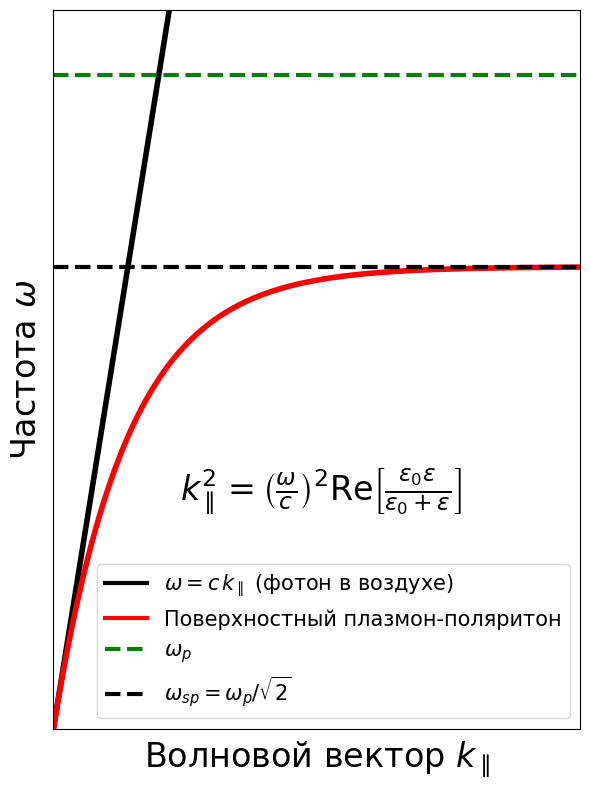

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Параметры
c = 1.0
omega_p = 1.0
omega_sp = omega_p / np.sqrt(2)

# Диапазон волнового вектора
k = np.linspace(0, 5, 500)

# Дисперсии
omega_photon = c * k
omega_spp = omega_sp * (1 - np.exp(-c * k / omega_sp))

# Построение
plt.figure(figsize=(6, 8))

# Фотон в воздухе (черная линия)
plt.plot(k, omega_photon, color='black', linewidth=4)

# Поверхностный плазмон‑поляритон (красная линия)
plt.plot(k, omega_spp, color='red', linewidth=4)

# Горизонтальные линии ω_p и ω_sp
plt.hlines(omega_p, 0, 5, linestyles='--', colors='green', linewidth=3)
plt.hlines(omega_sp, 0, 5, linestyles='--', colors='black', linewidth=3)

# Формула на графике
plt.text(1.2, 0.35,
         r'$k_{\parallel}^2 = \left(\frac{\omega}{c}\right)^2 \mathrm{Re}\left[\frac{\varepsilon_0\varepsilon}{\varepsilon_0 + \varepsilon}\right]$',
         fontsize=24, color='black')

# Подписи осей и заголовок
plt.xlabel('Волновой вектор $k_{\\parallel}$', fontsize=24)
plt.ylabel('Частота $\\omega$', fontsize=24)


# Легенда
legend_elements = [
    Line2D([0], [0], color='black', lw=3, label=r'$\omega = c\,k_{\parallel}$ (фотон в воздухе)'),
    Line2D([0], [0], color='red', lw=3, label='Поверхностный плазмон‑поляритон'),
    Line2D([0], [0], linestyle='--', color='green', lw=3, label=r'$\omega_p$'),
    Line2D([0], [0], linestyle='--', color='black', lw=3, label=r'$\omega_{sp} = \omega_p/\sqrt{2}$')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=15)

# Диапазоны
plt.xlim(0, 5)
plt.ylim(0, omega_p * 1.1)

plt.xticks([])  # убрать все деления и подписи по оси X
plt.yticks([])  # убрать все деления и подписи по оси Y

# Убираем сетку, чтобы сохранить оригинальный стиль
plt.grid(False)
plt.tight_layout()
plt.show()


In [7]:
plt.style.use('default')

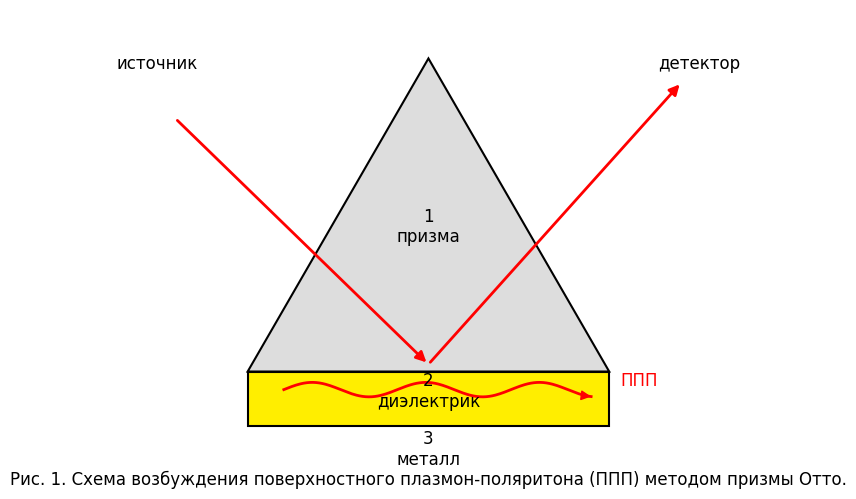

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon, FancyArrowPatch, Rectangle

# Создание фигуры и осей
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_aspect('equal')
ax.axis('off')

# Призма
triangle = Polygon([[0, 0], [1, 0], [0.5, 0.866]],
                   closed=True, facecolor='#DDDDDD', edgecolor='black', linewidth=1.5)
ax.add_patch(triangle)

# Жёлтая база
base = Rectangle((0, -0.15), 1, 0.15, facecolor='#FFEE00', edgecolor='black', linewidth=1.5)
ax.add_patch(base)

# Лучи
inc = FancyArrowPatch((-0.2, 0.7), (0.5, 0.02),
                      mutation_scale=15, color='red', linewidth=2, arrowstyle='-|>')
ax.add_patch(inc)
ref = FancyArrowPatch((0.5, 0.02), (1.2, 0.8),
                      mutation_scale=15, color='red', linewidth=2, arrowstyle='-|>')
ax.add_patch(ref)

# Волнистая ППП
x_wave = np.linspace(0.1, 0.95, 200)
y_wave = -0.05 + 0.02 * np.sin(20 * (x_wave - 0.1))
ax.plot(x_wave, y_wave, color='red', linewidth=2)
ax.add_patch(FancyArrowPatch((x_wave[-2], y_wave[-2]), (x_wave[-1], y_wave[-1]),
                             mutation_scale=15, color='red', arrowstyle='-|>'))

# Подписи элементов на рисунке
ax.text(-0.25, 0.85, 'источник', fontsize=12, ha='center', va='center')
ax.text(1.25, 0.85, 'детектор', fontsize=12, ha='center', va='center')

# Области 1, 2, 3
ax.text(0.5, 0.4, '1\nпризма', fontsize=12, ha='center', va='center')
ax.text(0.5, -0.055, '2\nдиэлектрик', fontsize=12, ha='center', va='center')
ax.text(0.5, -0.215, '3\nметалл', fontsize=12, ha='center', va='center')

# Метка поверхностного плазмон-поляритона
ax.text(1.03, -0.025, 'ППП', fontsize=12, ha='left', va='center', color='red')


# Рис. подпись снизу
fig.text(0.5, 0.02, 'Рис. 1. Схема возбуждения поверхностного плазмон-поляритона (ППП) методом призмы Отто.', 
         ha='center', fontsize=12)


# Установка границ
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(-0.3, 1.0)

plt.tight_layout()
plt.show()


In [ ]:
from pptx import Presentation
from pptx.util import Inches, Pt

         # start from your corporate template
bullet_slide = prs.slide_layouts[1]          # e.g. “Title + Content”

slide = prs.slides.add_slide(bullet_slide)
slide.shapes.title.text = "Experiment A – Transmittance"

# add Matplotlib picture exported above
content = slide.shapes.placeholders[1]       # main body placeholder
left, top, height = content.left, content.top, content.height
slide.shapes.add_picture("fig.emf", left, top, height=height)

prs.save("report.pptx")


PackageNotFoundError: Package not found at 'template.potx'

In [86]:
# ====================== imports & constants =============================== #
import os, tempfile
import matplotlib.pyplot as plt
import pandas as pd

from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor

# --- slide‑wide constants -------------------------------------------------- #
TITLE            = "Результаты: спектры отражения"
SUB_LEFT         = "Метод печати"
SUB_RIGHT        = "Метод заливки"
CAPTION          = ("Зависимость коэффициента отражения от частоты для разной "
                    "толщины слоев. Угол падения = π/4.")
SLIDE_NUMBER     = "19"

ACCENT_BLUE      = RGBColor( 33, 150, 243)      # #2196F3
FONT             = "Times New Roman"

# -------------------------------------------------------------------------- #
def plot_panel(df: pd.DataFrame,
               fn: str,
               figsize=(5, 4),
               title="Зависимость R от длины волны"):
    """Create a single Matplotlib figure and write it to *fn*."""
    plt.rcParams["font.family"] = FONT
    plt.rcParams["font.size"]   = 11

    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    for col in df.columns:
        ax.plot(df.index, df[col], label=col, lw=1.5)

    ax.set_xlabel("Длина волны [см⁻¹]")
    ax.set_ylabel("R")
    ax.set_title(title, fontsize=11, pad=6)
    ax.grid(True, ls="--", alpha=.3)
    ax.legend(frameon=False, fontsize=8, loc="upper right")

    fig.tight_layout()
    fig.savefig(fn, bbox_inches="tight", transparent=True)
    plt.close(fig)


def add_textbox(slide, left, top, width, height,
                text, size, bold=False, color=None, align="CENTER"):
    """Convenience wrapper; returns the text frame."""
    tx = slide.shapes.add_textbox(left, top, width, height)
    tf = tx.text_frame
    tf.clear()                 # throw away the default empty paragraph
    p  = tf.paragraphs[0]
    run = p.add_run()
    run.text = text
    run.font.name = FONT
    run.font.size = Pt(size)
    run.font.bold = bold
    if color:
        run.font.color.rgb = color
    p.alignment = getattr(PP_ALIGN, align)
    return tf


def add_panel(slide, img_path, left_in, top_in, max_height_in):
    """
    Insert *img_path* so that its height = max_height_in and the aspect
    ratio is preserved.  Returns the picture shape.
    """
    picture = slide.shapes.add_picture(
        img_path,
        Inches(left_in), Inches(top_in),
        height=Inches(max_height_in)
    )
    return picture


def make_reflection_slide(df_left:  pd.DataFrame,
                          df_right: pd.DataFrame,
                          pptx_out="reflection_results.pptx"):
    "Main entry point."

    # ---------------- 1.  render both panels to temp files ---------------- #
    with tempfile.TemporaryDirectory() as tmpd:
        left_img  = os.path.join(tmpd, "left.png")
        right_img = os.path.join(tmpd, "right.png")
        plot_panel(df_left,  left_img)
        plot_panel(df_right, right_img)

        # ---------------- 2.  build / open presentation ------------------- #
        prs    = Presentation()                 # start from blank theme
        blank  = prs.slide_layouts[6]           # pure blank layout
        slide  = prs.slides.add_slide(blank)

        sw, sh = prs.slide_width, prs.slide_height  # EMU units (914400 EMU = 1 inch)

        # ---------------- 3.  title --------------------------------------- #
        add_textbox(
            slide,
            left   = 0,
            top    = 0,
            width  = sw,
            height = Inches(1.0),
            text   = TITLE,
            size   = 44,
            bold   = True,
            align  = "CENTER"
        )

        # ---------------- 4.  subtitles ----------------------------------- #
        half = sw // 2
        add_textbox(
            slide,
            left   = 0,
            top    = Inches(1.3),
            width  = half,
            height = Inches(.4),
            text   = SUB_LEFT,
            size   = 24,
            color  = ACCENT_BLUE,
            align  = "CENTER"
        )
        add_textbox(
            slide,
            left   = half,
            top    = Inches(1.3),
            width  = half,
            height = Inches(.4),
            text   = SUB_RIGHT,
            size   = 24,
            color  = ACCENT_BLUE,
            align  = "CENTER"
        )

        # ---------------- 5.  insert the two plot pictures ---------------- #
        top_panels = 2.0                      # inches from top
        panel_h    = 4.0                      # inch tall pictures
        margin     = .2                       # gap between panels

        # left picture
        add_panel(slide, left_img,
                  left_in  = 0.5,
                  top_in   = top_panels,
                  max_height_in = panel_h)

        # right picture (compute left based on slide width)
        slide_width_in = sw / 914400
        right_left_in  = slide_width_in / 2.0 + margin
        add_panel(slide, right_img,
                  left_in  = right_left_in,
                  top_in   = top_panels,
                  max_height_in = panel_h)

        # ---------------- 6.  caption under both plots -------------------- #
        add_textbox(
            slide,
            left   = 0,
            top    = Inches(top_panels + panel_h + .3),
            width  = sw,
            height = Inches(.8),
            text   = CAPTION,
            size   = 20,
            align  = "CENTER"
        )

        # ---------------- 7.  slide number (manual) ----------------------- #
        add_textbox(
            slide,
            left   = sw - Inches(.6),
            top    = sh - Inches(.5),
            width  = Inches(.6),
            height = Inches(.3),
            text   = SLIDE_NUMBER,
            size   = 14,
            align  = "CENTER"
        )

        # ---------------- 8.  save --------------------------------------- #
        prs.save(pptx_out)
        print(f"✓ Saved to {pptx_out}")


# ============================ USAGE EXAMPLE =============================== #
if __name__ == "__main__":
    # ---------------------------------------------------------------------- #
    # Fake demo data (delete this block and supply your own DataFrames)     #
    import numpy as np
    wvn = np.linspace(50, 700, 650)
    df_left  = pd.DataFrame({
        f"{t} нм": .4 + .05*np.random.randn(len(wvn)) + .25*np.sin(2*np.pi*wvn/150 + t)
        for t in [0,18,35,70,105,140,175,280,420]
    }, index=wvn)
    df_right = pd.DataFrame({
        f"{t} нм": .35 + .05*np.random.randn(len(wvn)) + .12*np.sin(2*np.pi*wvn/180 + t)
        for t in [15,30]
    }, index=wvn)
    # ---------------------------------------------------------------------- #

    make_reflection_slide(df_left, df_right)


✓ Saved to reflection_results.pptx
